# Notebook for experiments with skeletonization

Imports

In [1]:
import sys
import os

# Go up three levels from the notebook's directory (../src) to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..')) 
# Add the src directory to the path
src_path = os.path.join(project_root, 'src') 
if src_path not in sys.path:
    sys.path.insert(0, src_path)
    
        
print(f"Project Root: {project_root}")
print(f"Src Path added: {src_path}")
print(f"sys.path[0]: {sys.path[0]}") 

Project Root: /Users/mlapin/Development/personal/NaturalAGI
Src Path added: /Users/mlapin/Development/personal/NaturalAGI/src
sys.path[0]: /Users/mlapin/Development/personal/NaturalAGI/src


In [2]:
from typing import List
import numpy as np
import networkx as nx
import os
from cv2 import imread
from ypstruct import structure
import matplotlib.pyplot as plt
import numpy as np


from skeletonization.converter import Converter
from skeletonization.network_simplification import NetworkSimplification
from skeletonization.skeleton_gng_mapper import SkeletonGNGMapper
from skeletonization.settings import Settings, gng_parameters

Additional parameters:

In [3]:
epsilon = 6
binary_threshold = 160

Iterate over images in folder function

In [4]:
def iterate_over_images_in_folder(folder_path: str):
    for file in os.listdir(folder_path):
        if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif")):
            yield file


In [5]:
from pydantic import BaseModel
from dataclasses import dataclass
from typing import Generator, Any, Tuple, Optional
import networkx as nx

class Vector(BaseModel):
    id: str
    x1: float
    y1: float
    x2: float
    y2: float
    length: float

@dataclass
class Point:
    x: float
    y: float
    id: str

    def __hash__(self):
        return hash(self.uuid)

class GraphTraversal:
    def __init__(self, graph: nx.Graph):
        self.graph = graph

    def dfs_traversal(self, start_node: Any) -> Generator[Tuple[Point, Optional[Vector]], None, None]:
        visited_edges = set()

        def find_edge(x1: float, y1: float, x2: float, y2: float) -> Optional[dict]:
            for _, _, edge_data in self.graph.edges(data=True):
                if ((edge_data['x1'] == x1 and edge_data['y1'] == y1 and edge_data['x2'] == x2 and edge_data['y2'] == y2) or
                    (edge_data['x1'] == x2 and edge_data['y1'] == y2 and edge_data['x2'] == x1 and edge_data['y2'] == y1)):
                    return edge_data
            return None

        def _dfs(node_id: str, prev_x: Optional[float] = None, prev_y: Optional[float] = None):
            node_data = self.graph.nodes[node_id]
            point = Point(id=node_data["uuid"], x=node_data['x'], y=node_data['y'])
            
            incoming_vector = None
            if prev_x is not None and prev_y is not None:
                edge_data = find_edge(prev_x, prev_y, point.x, point.y)
                if edge_data:
                    incoming_vector = Vector(
                        id=edge_data['uuid'],
                        x1=prev_x,
                        y1=prev_y,
                        x2=point.x,
                        y2=point.y,
                        length=edge_data['length']
                    )
                else:
                    raise ValueError(f"Edge not found between {prev_x}, {prev_y} and {point.x}, {point.y}")
            
            yield point, incoming_vector

            for neighbor_id in self.graph.neighbors(node_id):
                edge = tuple(sorted([node_id, neighbor_id]))
                if edge not in visited_edges:
                    visited_edges.add(edge)
                    yield from _dfs(neighbor_id, point.x, point.y)

        yield from _dfs(start_node)

In [6]:
from typing import Tuple, Optional


def plot_graph_traversal(
    ax: plt.Axes, G: nx.Graph, traversal: List[Tuple[Point, Optional[Vector]]]
):
    """
    Plot the graph traversal with arrows on the given axes.

    Args:
        ax (plt.Axes): The matplotlib axes to plot on.
        G (nx.Graph): The NetworkX graph.
        traversal (List[Tuple[Point, Optional[Vector]]]): The traversal result.
    """
    # Plot all edges in light gray
    pos = {node: (G.nodes[node]["x"], G.nodes[node]["y"]) for node in G.nodes()}
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="lightgray", arrows=False)

    # Plot nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color="lightblue")

    # Plot traversal with arrows
    for i, (point, vector) in enumerate(traversal):
        # Mark the first point in red for better visualization
        if i == 0:
            ax.scatter(point.x, point.y, color='red', s=100, zorder=10)
            
        if vector:
            print(
                f"Vector {i}: x1: {vector.x1}, y1: {vector.y1}, x2: {vector.x2}, y2: {vector.y2}"
            )
            dx = vector.x2 - vector.x1
            dy = vector.y2 - vector.y1
            abs_dx = abs(dx)
            abs_dy = abs(dy)
            
            vector_type = None
            if abs_dx == abs_dy:
                vector_type = "DiagonalVector"
            elif abs_dx > abs_dy:
                vector_type = "HorizontalVector"
            else:
                vector_type = "VerticalVector"
            ax.arrow(
                vector.x1,
                vector.y1,
                dx,
                dy,  # Swap x and y
                head_width=3,
                head_length=3,
                fc="r",
                ec="r",
                length_includes_head=True,
                alpha=0.5,
            )
            
            label_x, label_y = calculate_label_position(vector)
            ax.text(
                label_x,
                label_y,
                vector_type,
                ha="center",
                va="center",
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
            )

        # Add numbers to show traversal order
        ax.text(point.x, point.y, str(i), fontsize=8, ha="center", va="center")

    ax.set_title("Graph Traversal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.invert_yaxis()  # Invert y-axis to match image coordinates

def calculate_label_position(vector: Vector, offset: float = 1) -> Tuple[float, float]:
    """
    Calculate optimal position for vector type label.
    
    Args:
        vector: Vector object containing coordinates
        offset: Distance of label from vector in pixels
        
    Returns:
        Tuple of (x, y) coordinates for label position
    """
    # Calculate vector properties
    dx = vector.x2 - vector.x1
    dy = vector.y2 - vector.y1
    length = vector.length
    
    # Calculate unit normal vector (perpendicular to the vector)
    if length > 0:
        nx = -dy / length
        ny = dx / length
    else:
        nx, ny = 0, -1
        
    # Calculate midpoint
    mid_x = vector.x1 + dx/2
    mid_y = vector.y1 + dy/2
    
    # Position label along normal vector
    label_x = mid_x + nx * offset
    label_y = mid_y + ny * offset
    
    return label_x, label_y


def plot_network_result(
    image_path,
    network,
    network_params: structure,
    points: np.ndarray,
    image: np.ndarray,
    binary: np.ndarray,
    skeleton: np.ndarray,
    simplified_network: List[List[np.ndarray]],
):
    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(image, cmap="gray")
    ax1.set_title(f"Original Image: {image_path}")
    ax1.axis("off")

    ax2.imshow(binary, cmap="gray")
    ax2.set_title("Binary Image")
    ax2.axis("off")

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap="gray")
    ax3.set_title("Skeletonized Image")
    ax3.axis("off")

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points[:, 0], points[:, 1], s=2)
    for i in range(network_params.N):
        for j in range(i + 1, network_params.N):
            if network.C[i, j] == 1:
                ax4.plot(
                    [network.w[i, 0], network.w[j, 0]],
                    [network.w[i, 1], network.w[j, 1]],
                    c="r",
                )

    ax4.scatter(network.w[:, 0], network.w[:, 1], s=60, c="y", edgecolors="r")

    ax4.set_title("GNG")
    ax4.set_xlabel("x")
    ax4.set_ylabel("y")
    ax4.axis("equal")
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points[:, 0], points[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], "r-", linewidth=2)

    ax5.set_title("Simplified Network")
    ax5.set_xlabel("x")
    ax5.set_ylabel("y")
    ax5.axis("equal")
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

In [7]:
def find_top_leftmost_point(graph: nx.Graph) -> Optional[Any]:
    """
    Finds the top-leftmost point in the graph based on x and y coordinates.
    If no nodes with degree 1 exist, returns the node with highest degree.

    Returns:
        Optional[Any]: The top-leftmost point node or None if the graph is empty.
    """
    if not graph.nodes:
        return None

    degree_one_nodes = [node for node in graph.nodes if graph.degree[node] == 1]
    
    if degree_one_nodes:
        return min(
            degree_one_nodes,
            key=lambda n: graph.nodes[n]["y"] + graph.nodes[n]["x"],
        )
    else:
        # Find node with maximum degree
        return max(graph.nodes, key=lambda n: graph.degree[n])

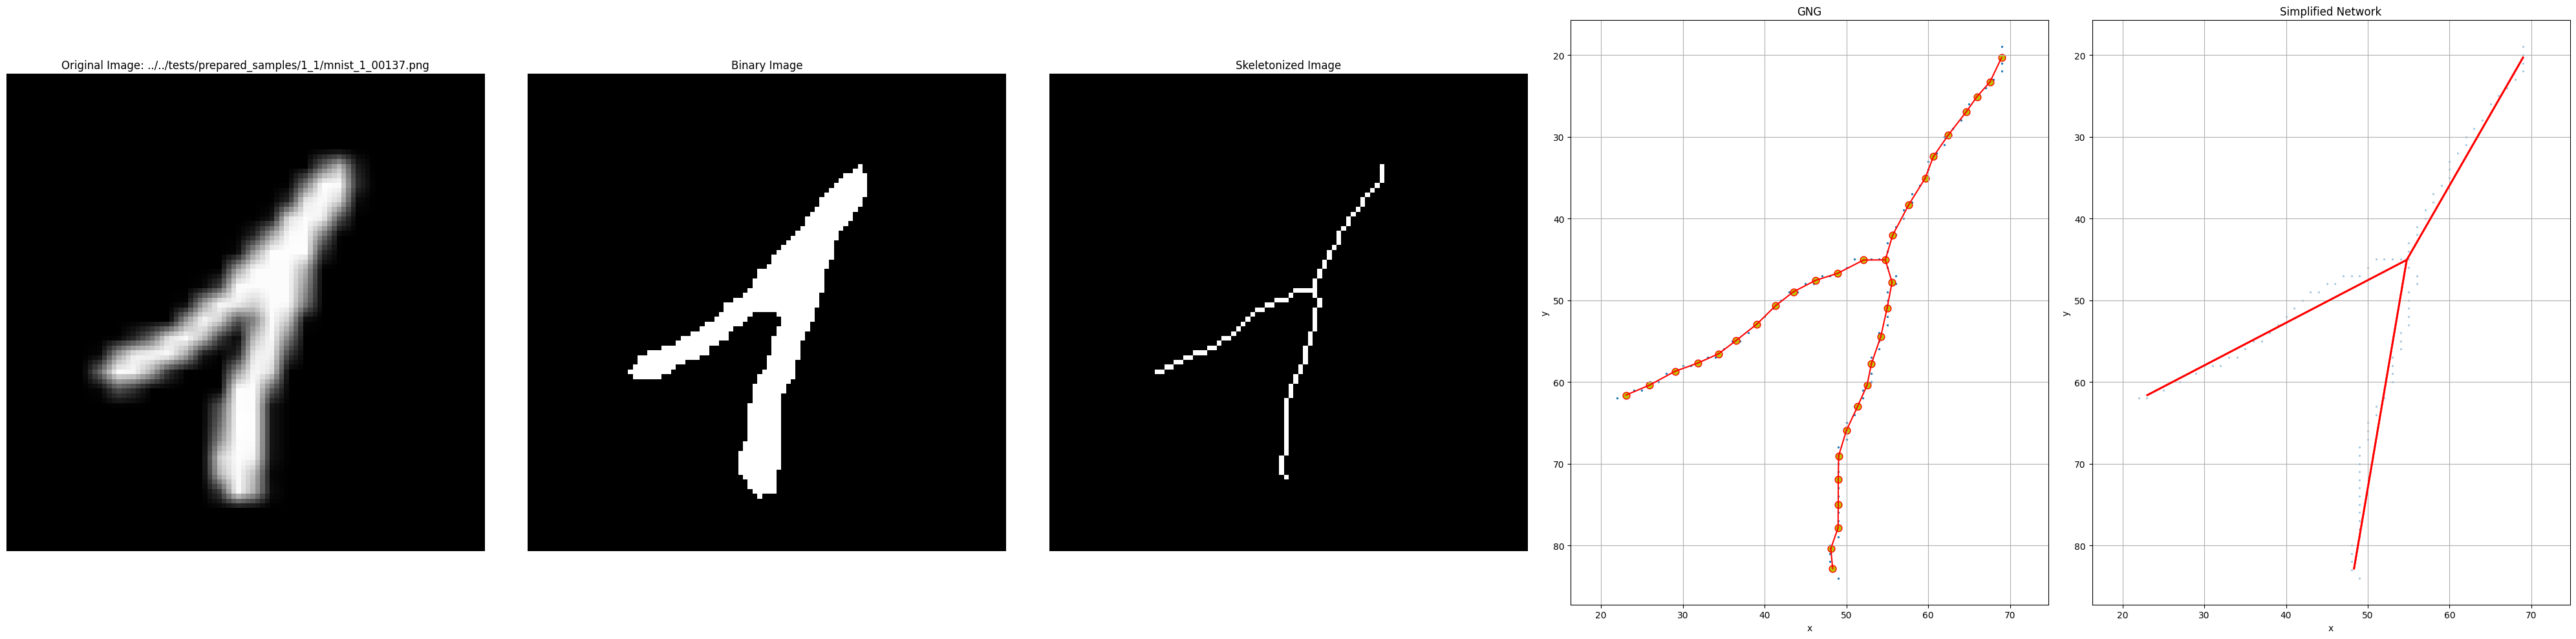

Cycles: 0
Top leftmost point: {'x': 23.041331578559216, 'y': 61.620219397930825, 'uuid': '3d10fdb4-b875-46d6-b765-47578f964fc9'}
Vector 1: x1: 23.041331578559216, y1: 61.620219397930825, x2: 54.76097673669257, y2: 45.072825351342246
Vector 2: x1: 54.76097673669257, y1: 45.072825351342246, x2: 48.3179517484128, y2: 82.84288687340225
Vector 3: x1: 54.76097673669257, y1: 45.072825351342246, x2: 68.97611725810344, y2: 20.317468532007517


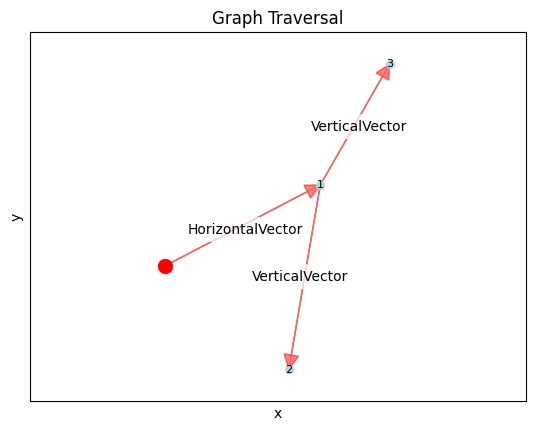

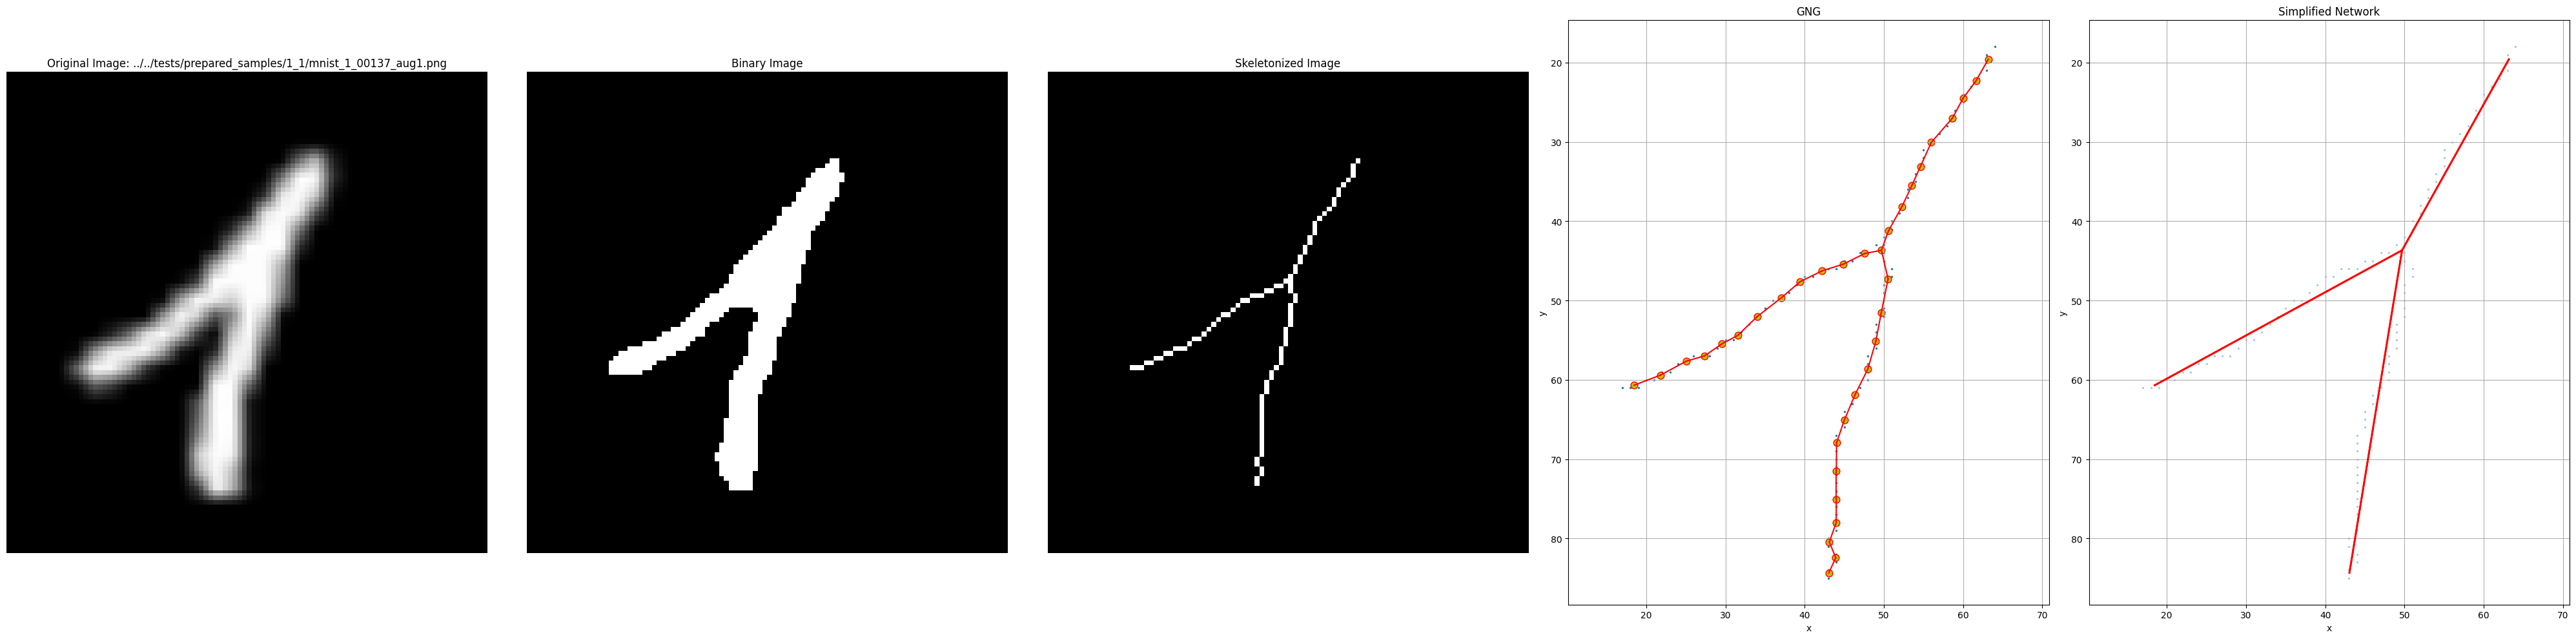

Cycles: 0
Top leftmost point: {'x': 18.475597547357616, 'y': 60.68949272733174, 'uuid': 'bb676a33-2924-4449-9aa7-74f93dd07c82'}
Vector 1: x1: 18.475597547357616, y1: 60.68949272733174, x2: 49.69369804489578, y2: 43.66469750794936
Vector 2: x1: 49.69369804489578, y1: 43.66469750794936, x2: 63.17806735412238, y2: 19.56923706957389
Vector 3: x1: 49.69369804489578, y1: 43.66469750794936, x2: 43.05338913073622, y2: 84.34049813324769


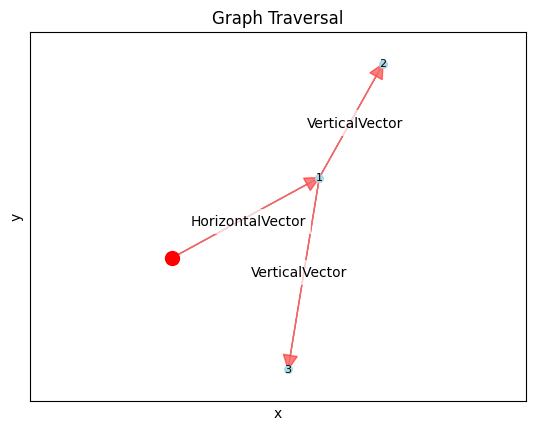

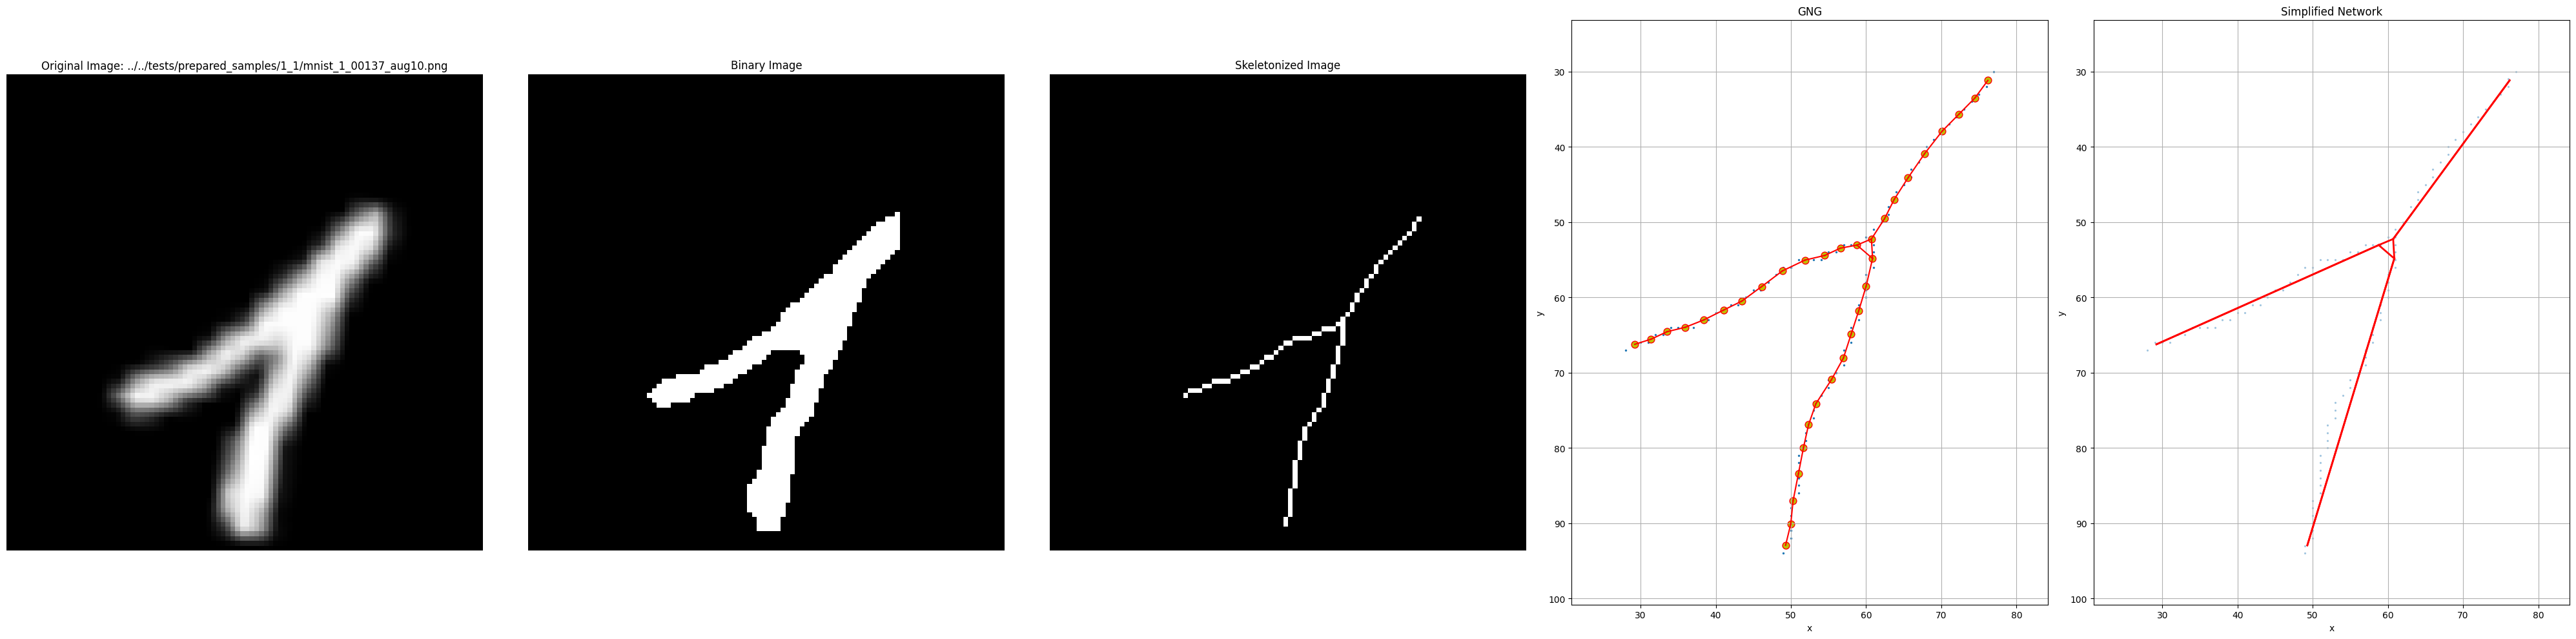

Cycles: 1
Top leftmost point: {'x': 29.22392153336538, 'y': 66.23909971480602, 'uuid': 'a2bf965c-637c-405d-ba92-4653043b3040'}
Vector 1: x1: 29.22392153336538, y1: 66.23909971480602, x2: 58.774834560028694, y2: 53.05280581399706
Vector 2: x1: 58.774834560028694, y1: 53.05280581399706, x2: 60.704178205243856, y2: 52.24277547865419
Vector 3: x1: 60.704178205243856, y1: 52.24277547865419, x2: 76.19180037768625, y2: 31.162916548909553
Vector 4: x1: 60.704178205243856, y1: 52.24277547865419, x2: 60.85613388408031, y2: 54.83813316437
Vector 5: x1: 60.85613388408031, y1: 54.83813316437, x2: 58.774834560028694, y2: 53.05280581399706
Vector 6: x1: 60.85613388408031, y1: 54.83813316437, x2: 49.28776812986259, y2: 92.94841050195937


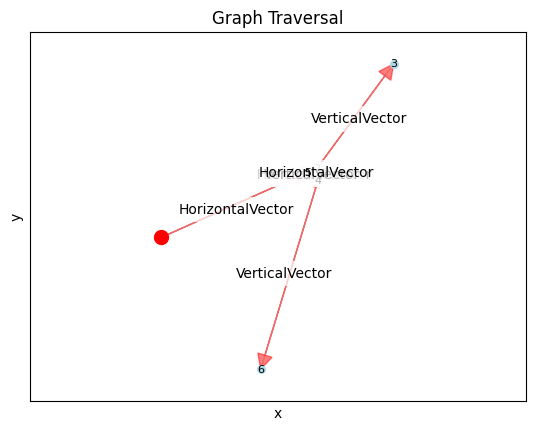

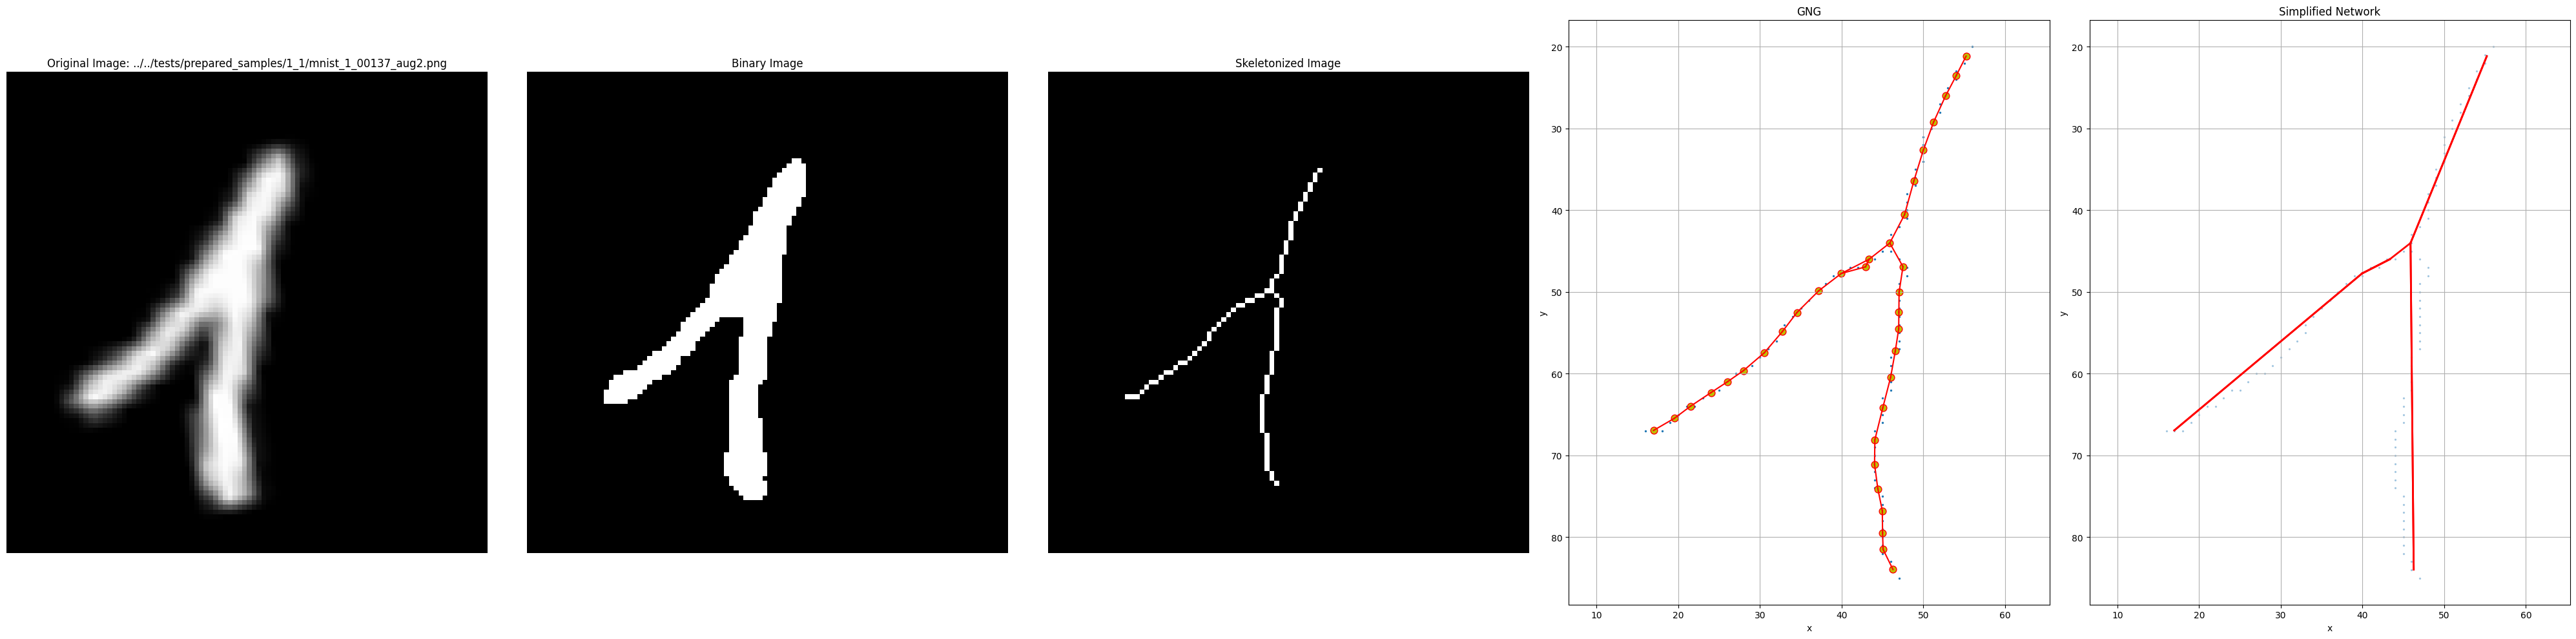

Cycles: 0
Top leftmost point: {'x': 55.22411423139077, 'y': 21.144157395751996, 'uuid': 'd7ec96ae-d06e-4343-a46d-bc22d250eb95'}
Vector 1: x1: 55.22411423139077, y1: 21.144157395751996, x2: 45.882928779864756, y2: 44.01251876333575
Vector 2: x1: 45.882928779864756, y1: 44.01251876333575, x2: 43.34919246804057, y2: 45.994113696140595
Vector 3: x1: 43.34919246804057, y1: 45.994113696140595, x2: 39.94306858512403, y2: 47.73861214060462
Vector 4: x1: 39.94306858512403, y1: 47.73861214060462, x2: 16.958314598809046, y2: 66.9399825929416
Vector 5: x1: 45.882928779864756, y1: 44.01251876333575, x2: 46.274827535261856, y2: 83.96299234346158


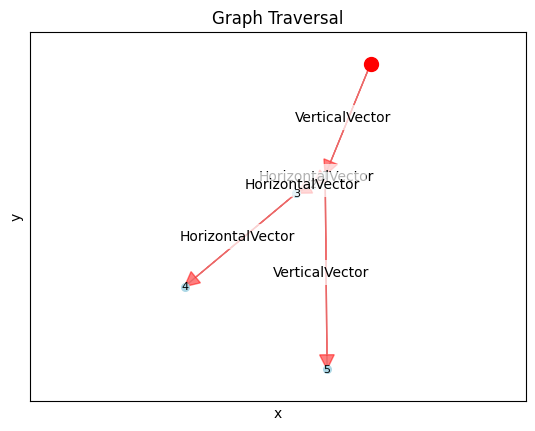

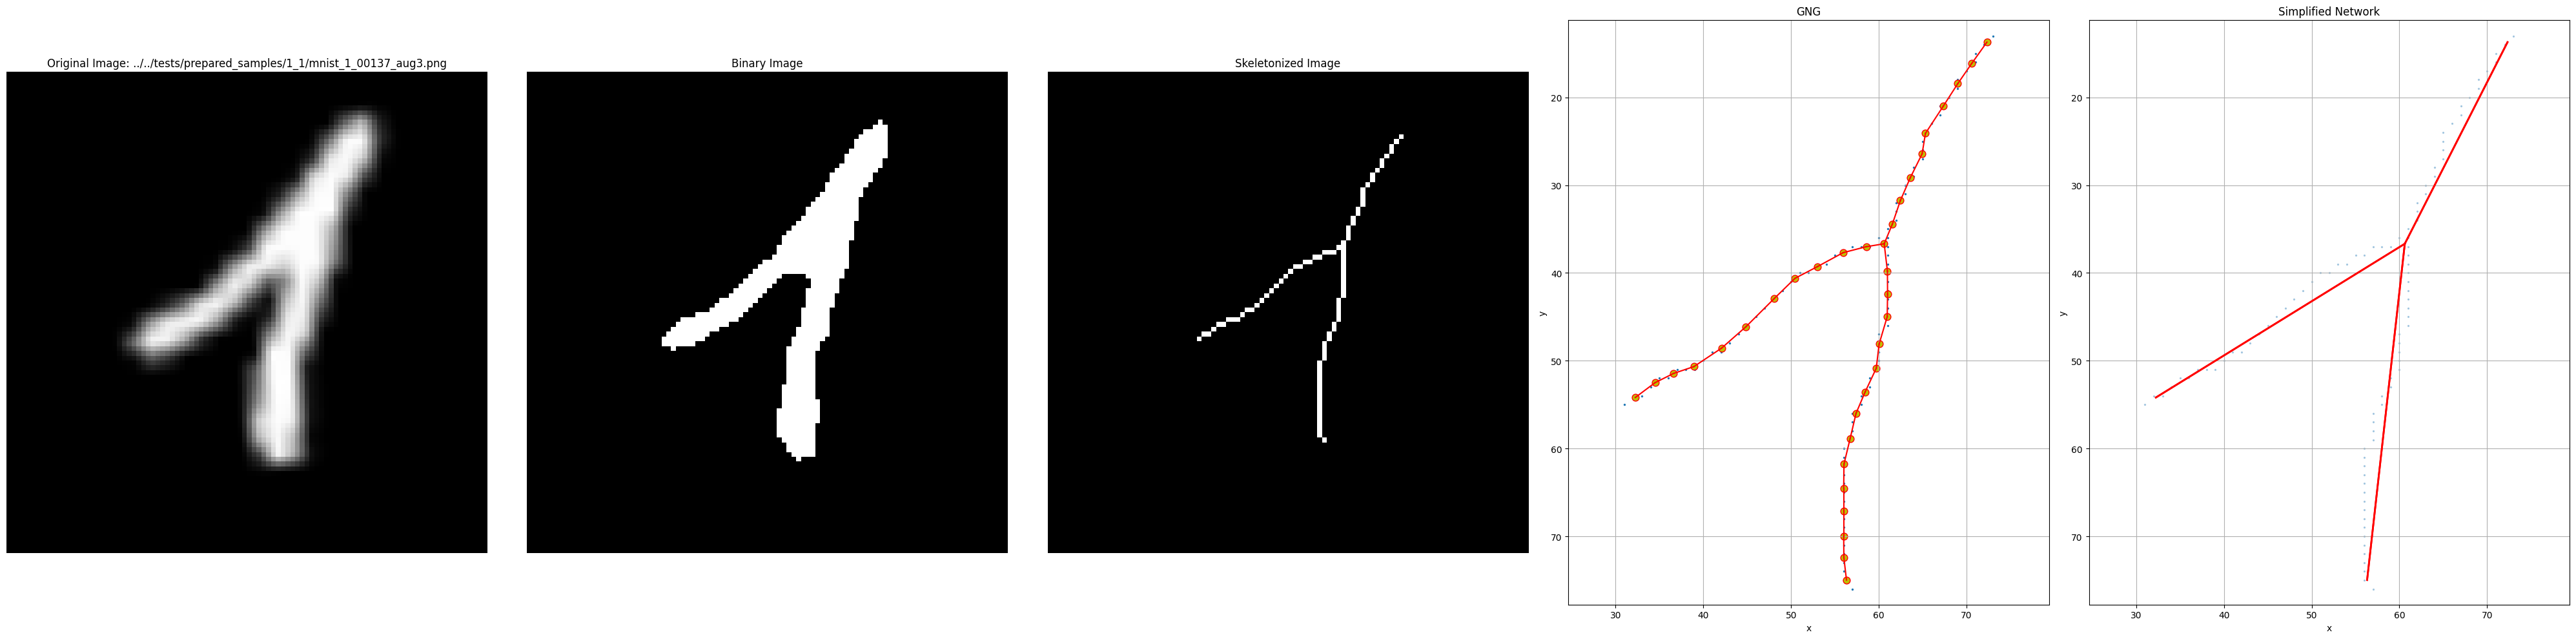

Cycles: 0
Top leftmost point: {'x': 72.32581588527115, 'y': 13.716188435707785, 'uuid': 'cb532b32-eff3-4cb9-ad81-f2c9b78409e2'}
Vector 1: x1: 72.32581588527115, y1: 13.716188435707785, x2: 60.61565516063464, y2: 36.68005714625892
Vector 2: x1: 60.61565516063464, y1: 36.68005714625892, x2: 32.24160960664214, y2: 54.19180037768629
Vector 3: x1: 60.61565516063464, y1: 36.68005714625892, x2: 56.31795174841318, y2: 74.98302330361291


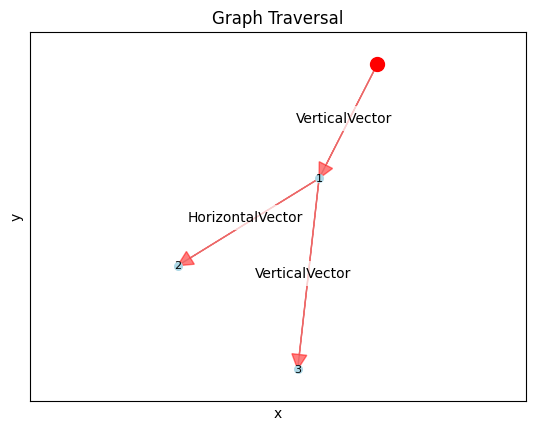

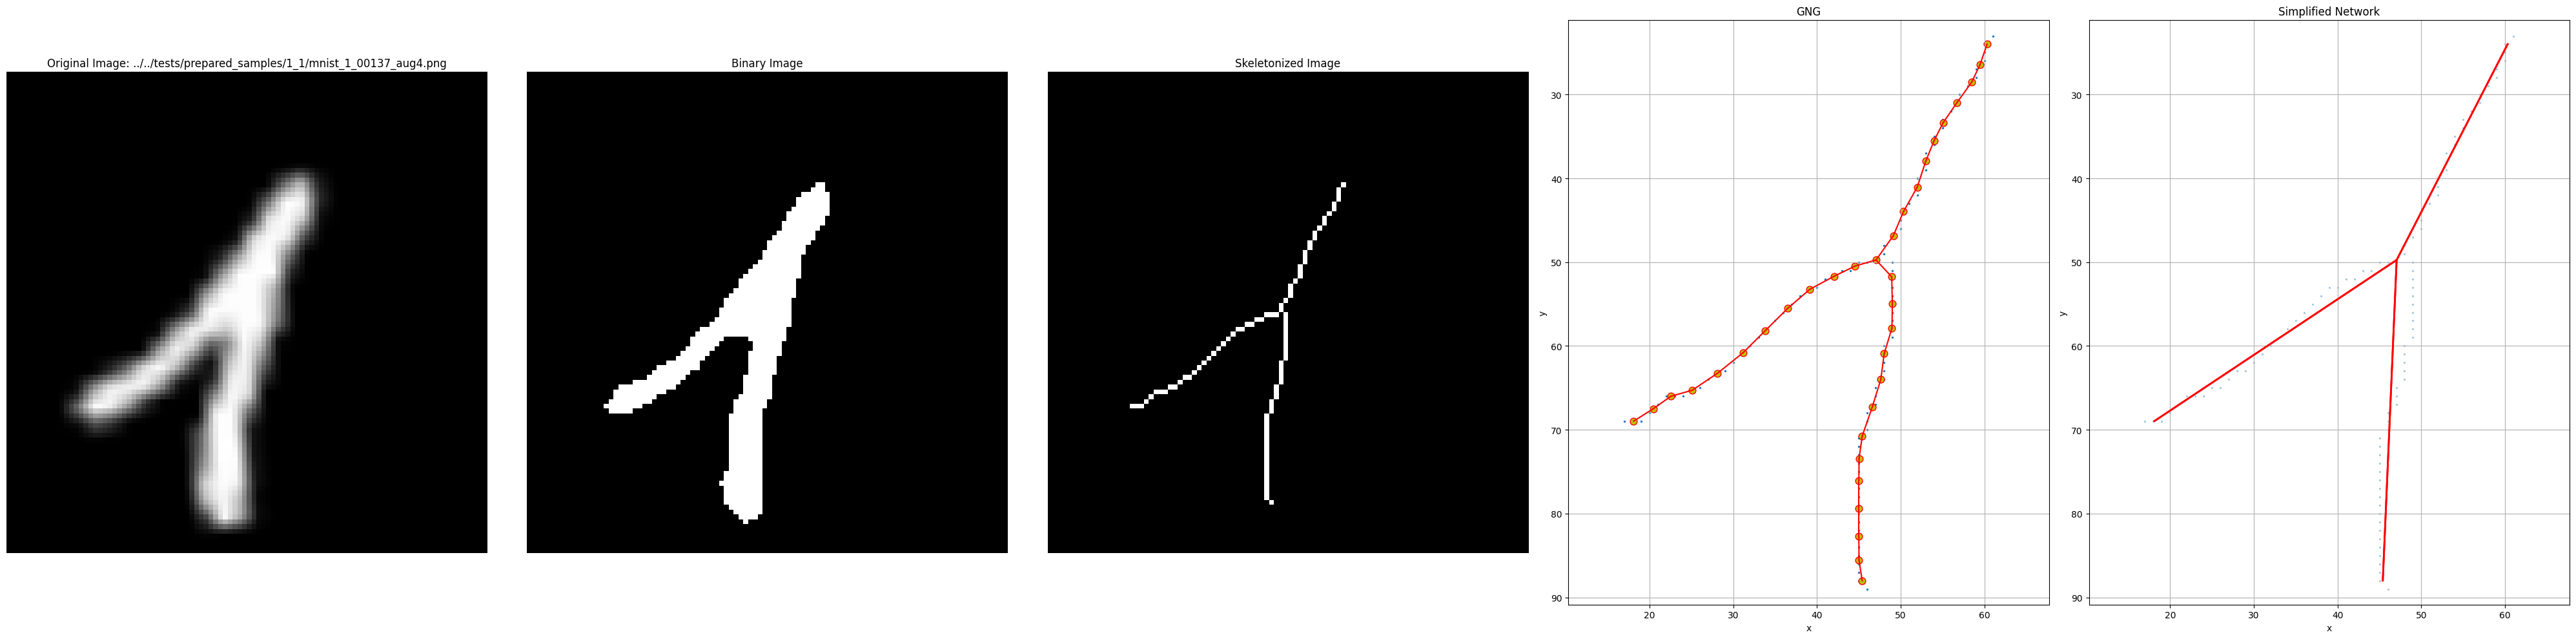

Cycles: 0
Top leftmost point: {'x': 60.308316846945026, 'y': 23.99208653426835, 'uuid': '42cbded5-27c8-46b4-9d46-c0e09c8959c3'}
Vector 1: x1: 60.308316846945026, y1: 23.99208653426835, x2: 47.05237246569629, y2: 49.74196577163247
Vector 2: x1: 47.05237246569629, y1: 49.74196577163247, x2: 45.397439685516446, y2: 88.00118830451147
Vector 3: x1: 47.05237246569629, y1: 49.74196577163247, x2: 18.11541327310237, y2: 68.96927108755511


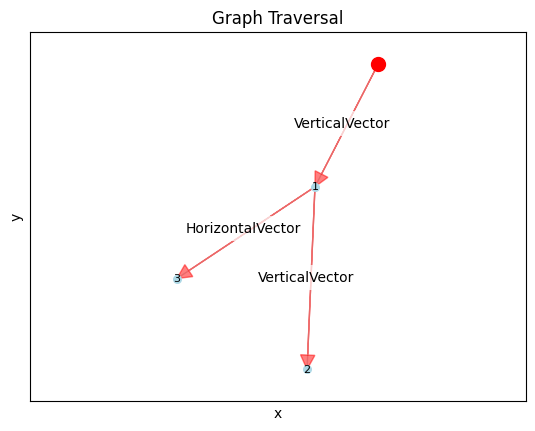

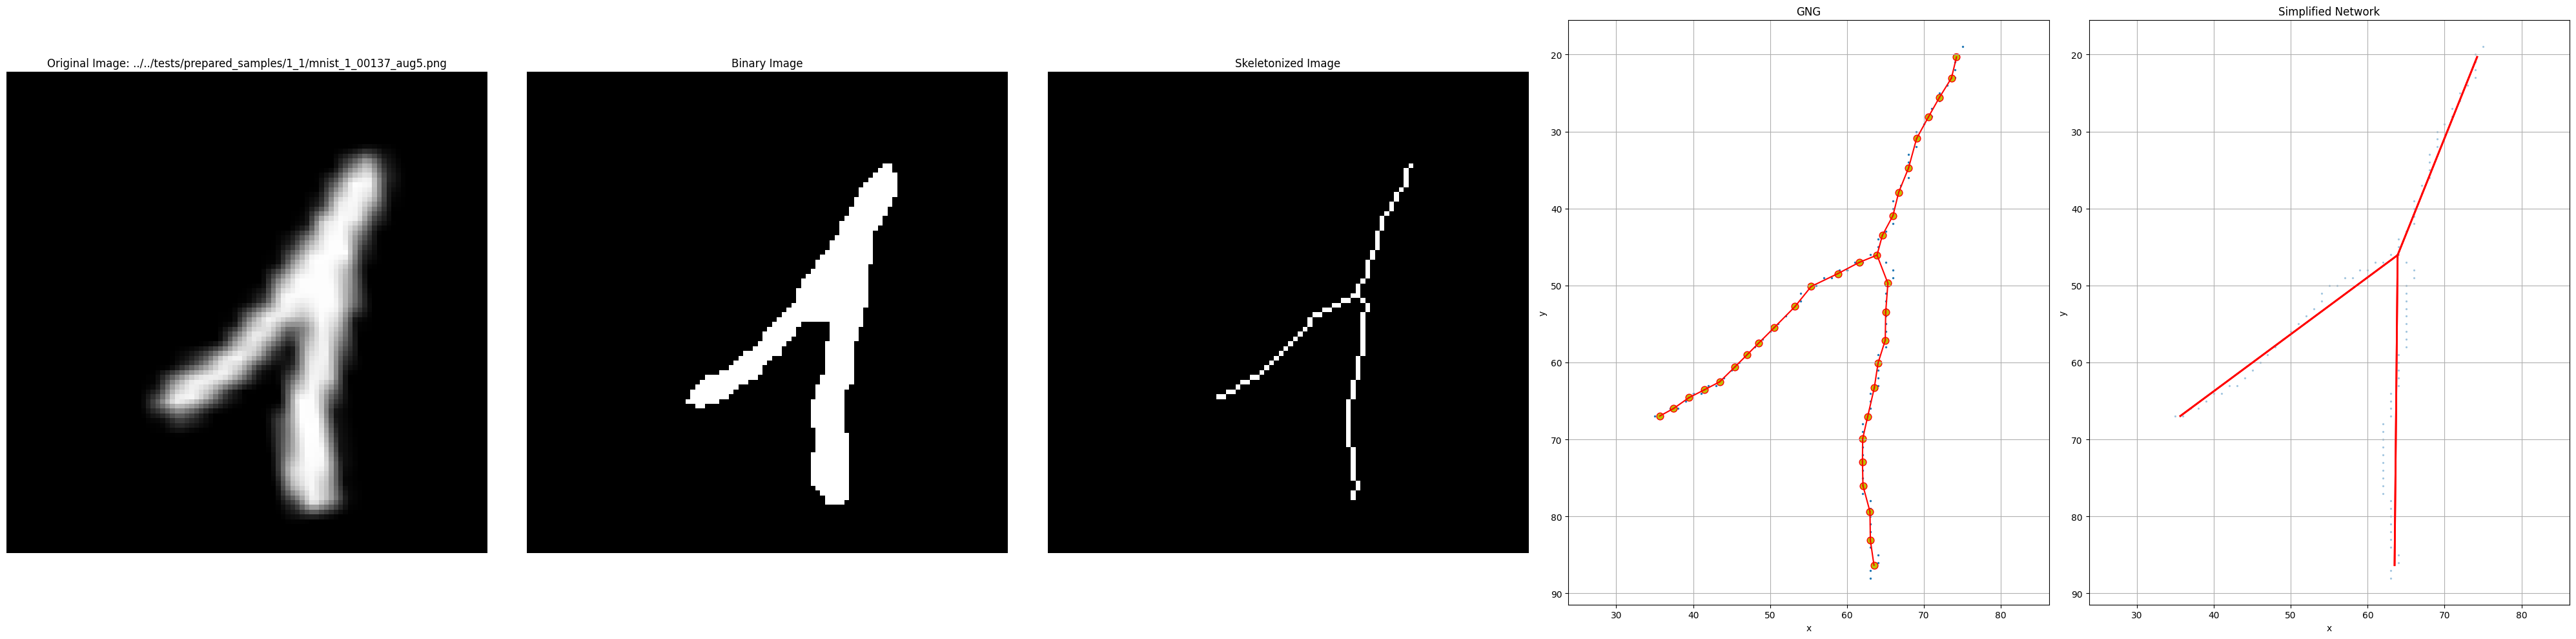

Cycles: 0
Top leftmost point: {'x': 74.22694098446635, 'y': 20.31610163574672, 'uuid': '7ed83f35-df86-4bb3-b183-58c7aa65f58e'}
Vector 1: x1: 74.22694098446635, y1: 20.31610163574672, x2: 63.892229639089386, y2: 46.058615493019964
Vector 2: x1: 63.892229639089386, y1: 46.058615493019964, x2: 35.64324360614063, y2: 66.95728872485674
Vector 3: x1: 63.892229639089386, y1: 46.058615493019964, x2: 63.496806741996544, y2: 86.32965900344792


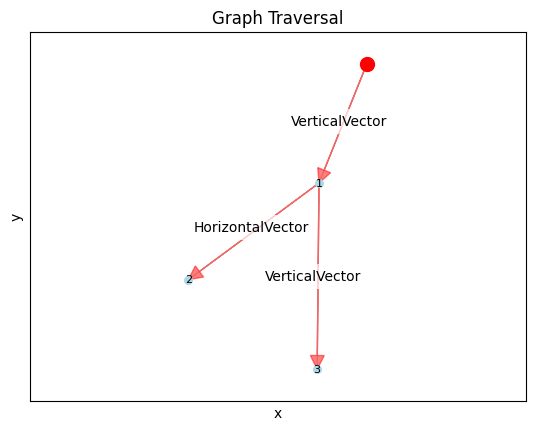

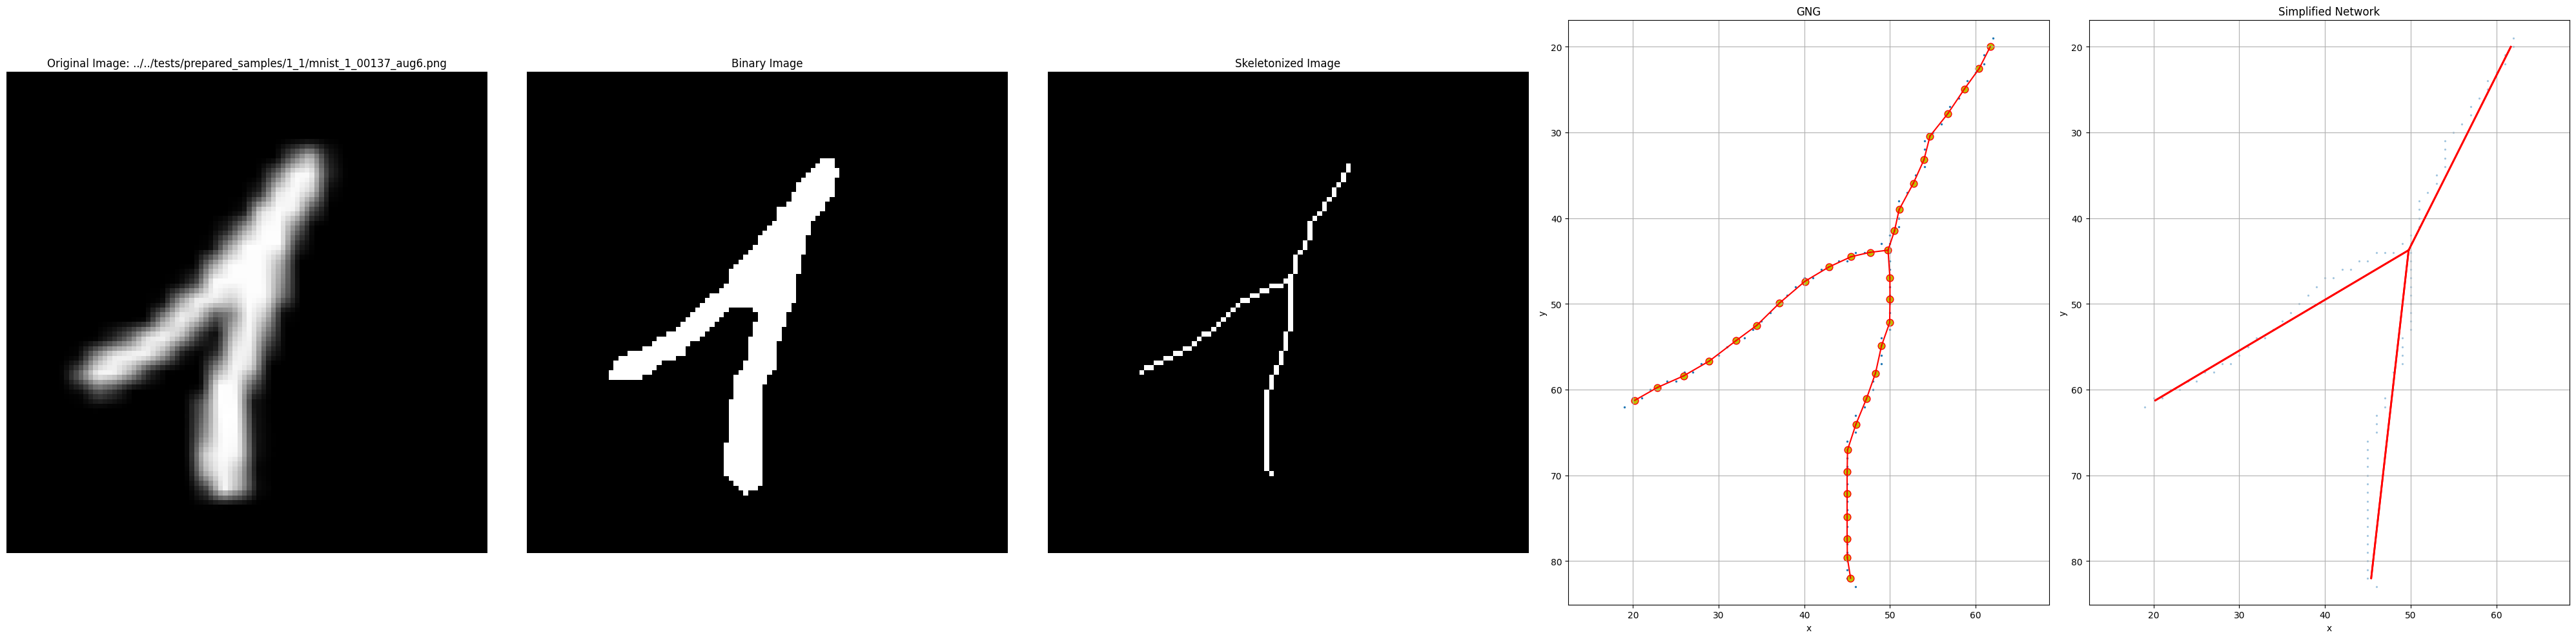

Cycles: 0
Top leftmost point: {'x': 20.2086943670605, 'y': 61.25607711843158, 'uuid': 'b5e9b3b5-776d-44f9-b98d-3dc14bd2279b'}
Vector 1: x1: 20.2086943670605, y1: 61.25607711843158, x2: 49.76984664241503, y2: 43.7439226920227
Vector 2: x1: 49.76984664241503, y1: 43.7439226920227, x2: 45.397439685450884, y2: 81.99482926865407
Vector 3: x1: 49.76984664241503, y1: 43.7439226920227, x2: 61.69213920505576, y2: 20.02905886282623


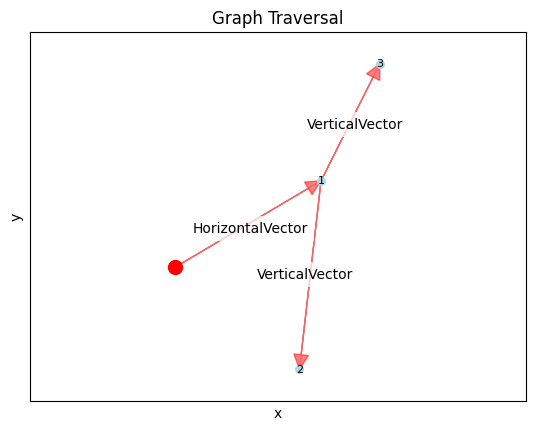

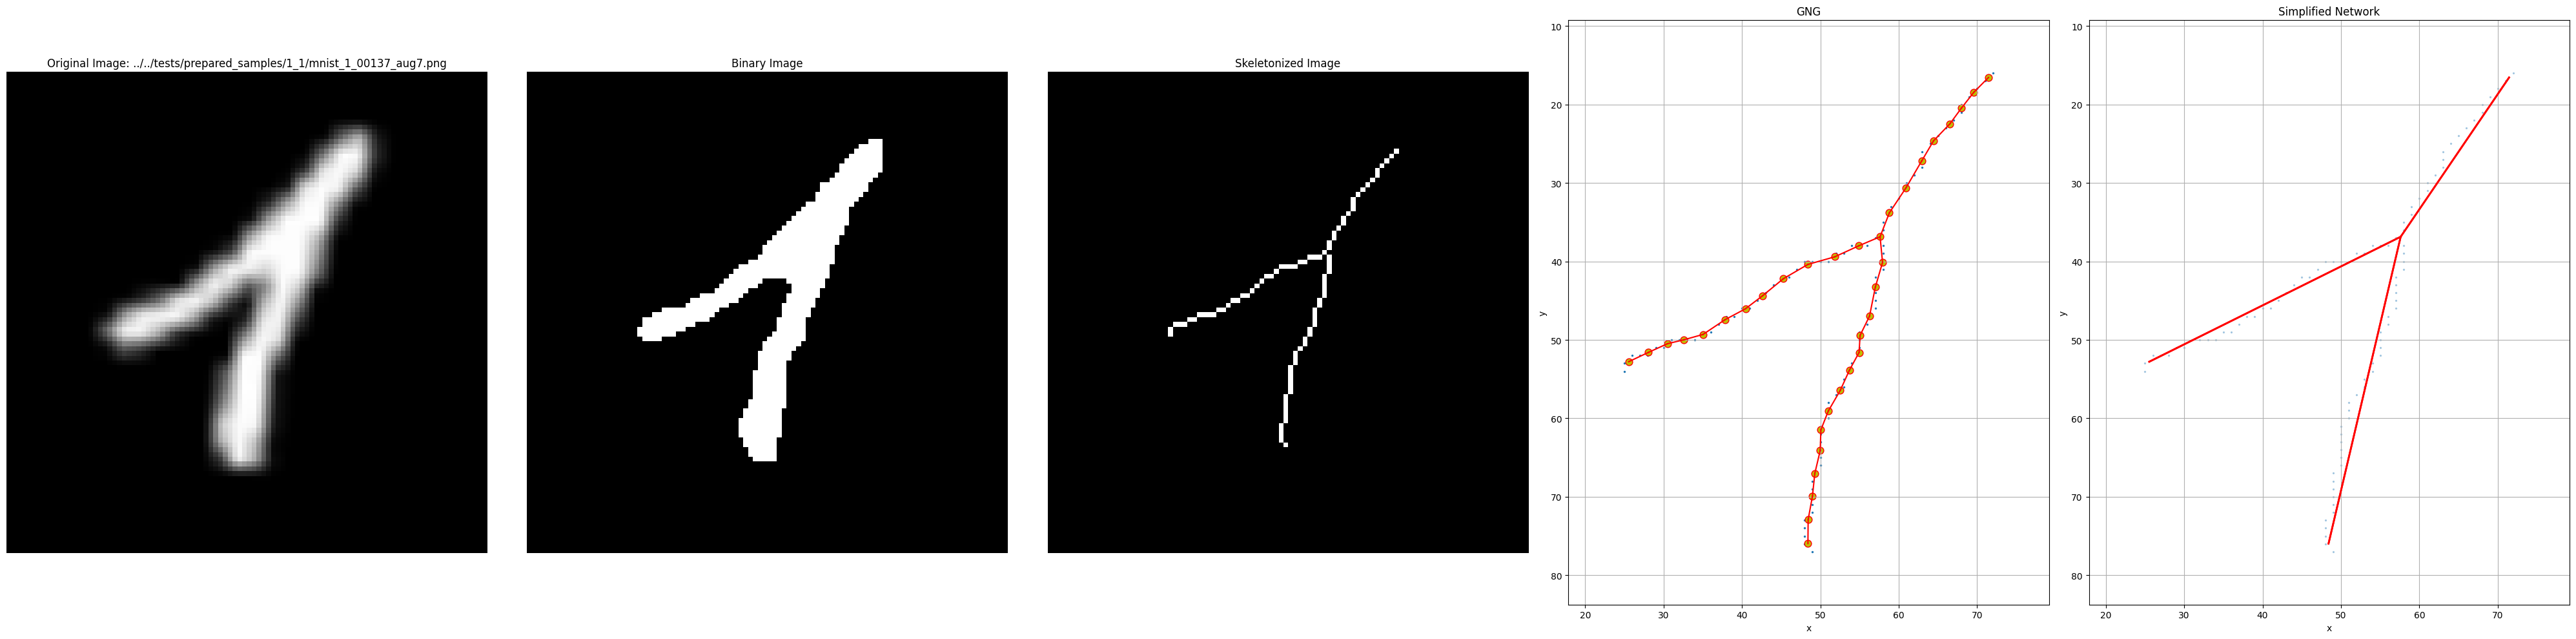

Cycles: 0
Top leftmost point: {'x': 25.54184057141197, 'y': 52.78538774832804, 'uuid': '2a7c916a-4970-4d8c-98db-9a1a108a4472'}
Vector 1: x1: 25.54184057141197, y1: 52.78538774832804, x2: 57.61662158679735, y2: 36.8552895984796
Vector 2: x1: 57.61662158679735, y1: 36.8552895984796, x2: 48.413348853204674, y2: 75.96397836442853
Vector 3: x1: 57.61662158679735, y1: 36.8552895984796, x2: 71.44594304092077, y2: 16.55405733821066


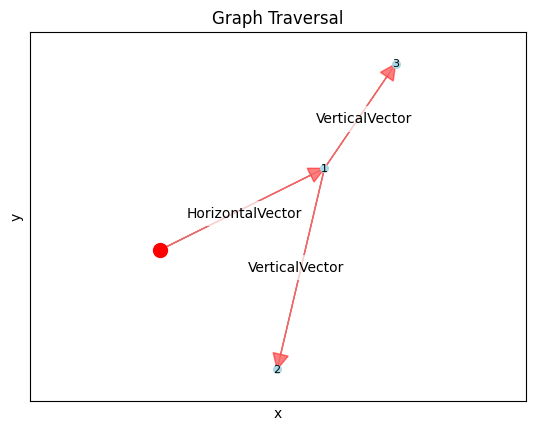

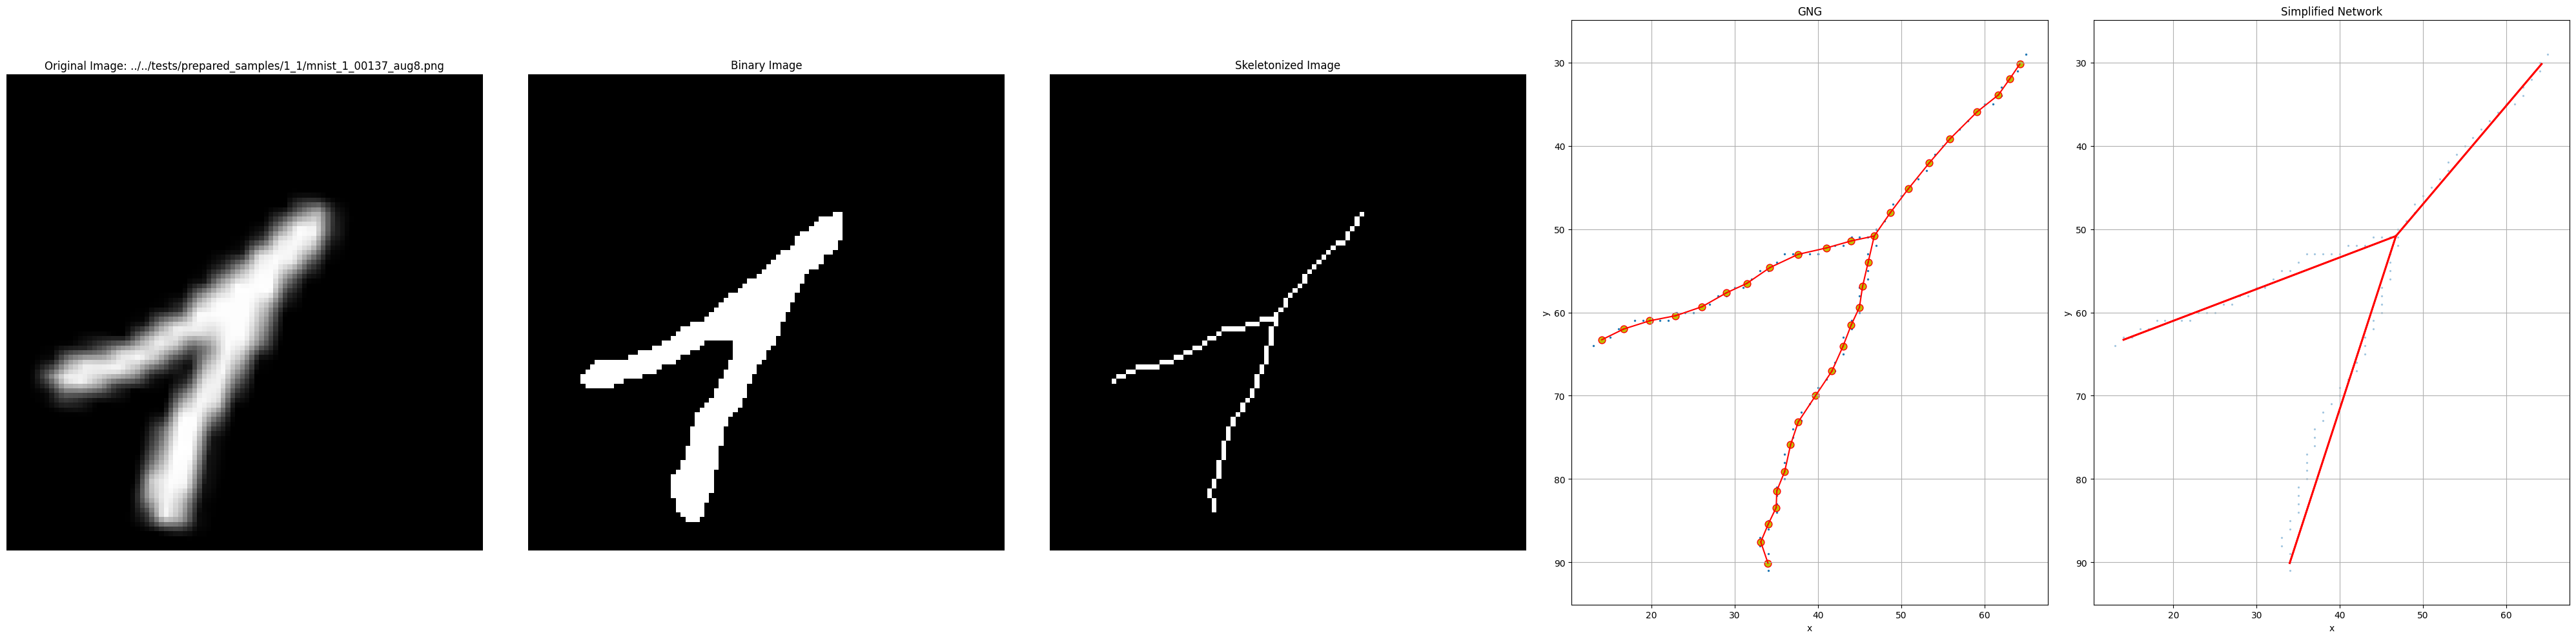

Cycles: 0
Top leftmost point: {'x': 14.01701523599361, 'y': 63.28281647439543, 'uuid': 'a3c34009-fa82-4ad1-b547-dfeb8a51ae50'}
Vector 1: x1: 14.01701523599361, y1: 63.28281647439543, x2: 46.74520919346294, y2: 50.83152597334414
Vector 2: x1: 46.74520919346294, y1: 50.83152597334414, x2: 64.2407527579462, y2: 30.181051265416993
Vector 3: x1: 46.74520919346294, y1: 50.83152597334414, x2: 33.97954831590278, y2: 90.09334292488754


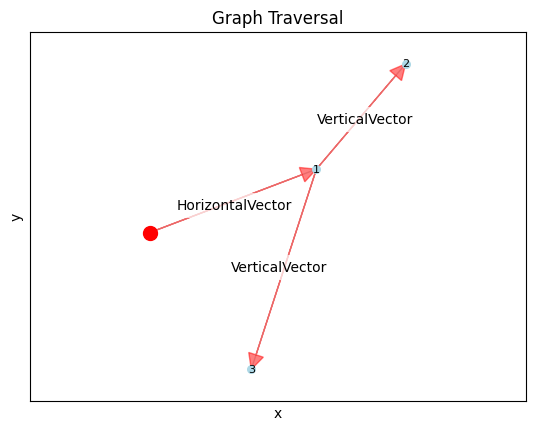

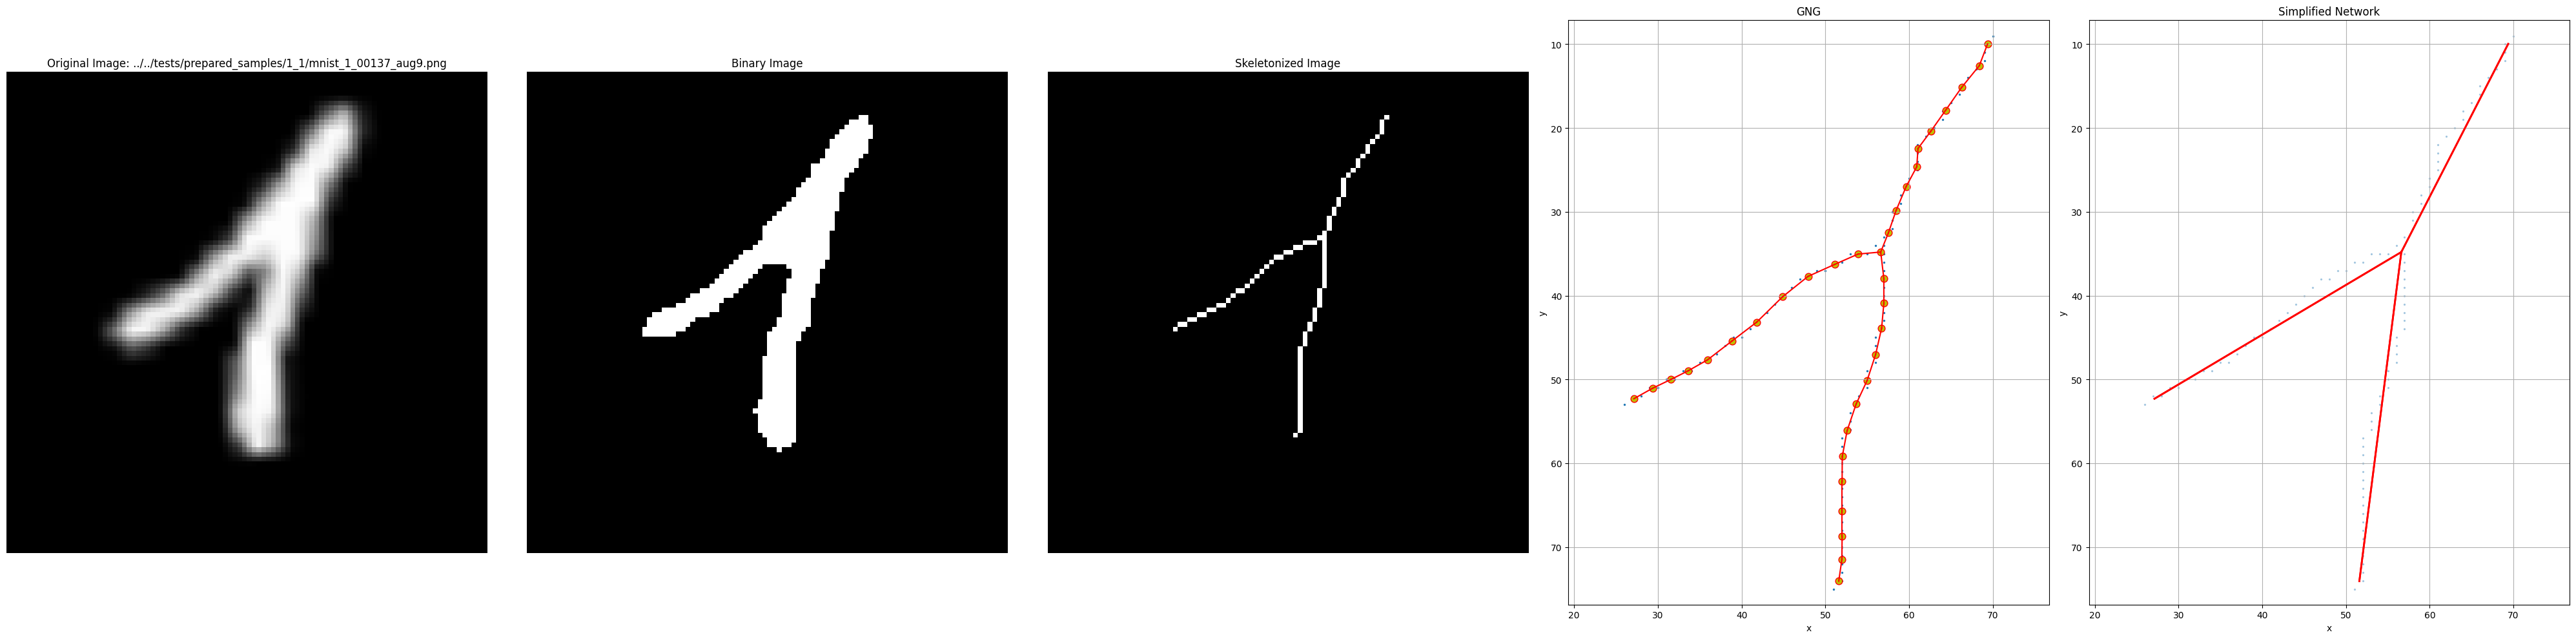

Cycles: 0
Top leftmost point: {'x': 69.37339257727096, 'y': 9.958314598806234, 'uuid': '8db414d7-88a0-45a8-a2b4-46caced2243e'}
Vector 1: x1: 69.37339257727096, y1: 9.958314598806234, x2: 56.610298750214895, y2: 34.79648545832479
Vector 2: x1: 56.610298750214895, y1: 34.79648545832479, x2: 27.131368669877965, y2: 52.300711698050335
Vector 3: x1: 56.610298750214895, y1: 34.79648545832479, x2: 51.598545772211395, y2: 74.06966676076789


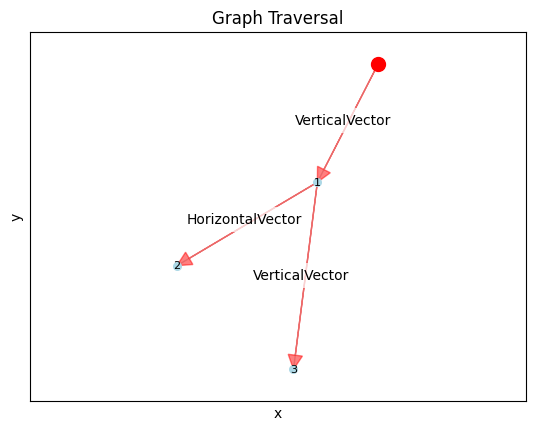

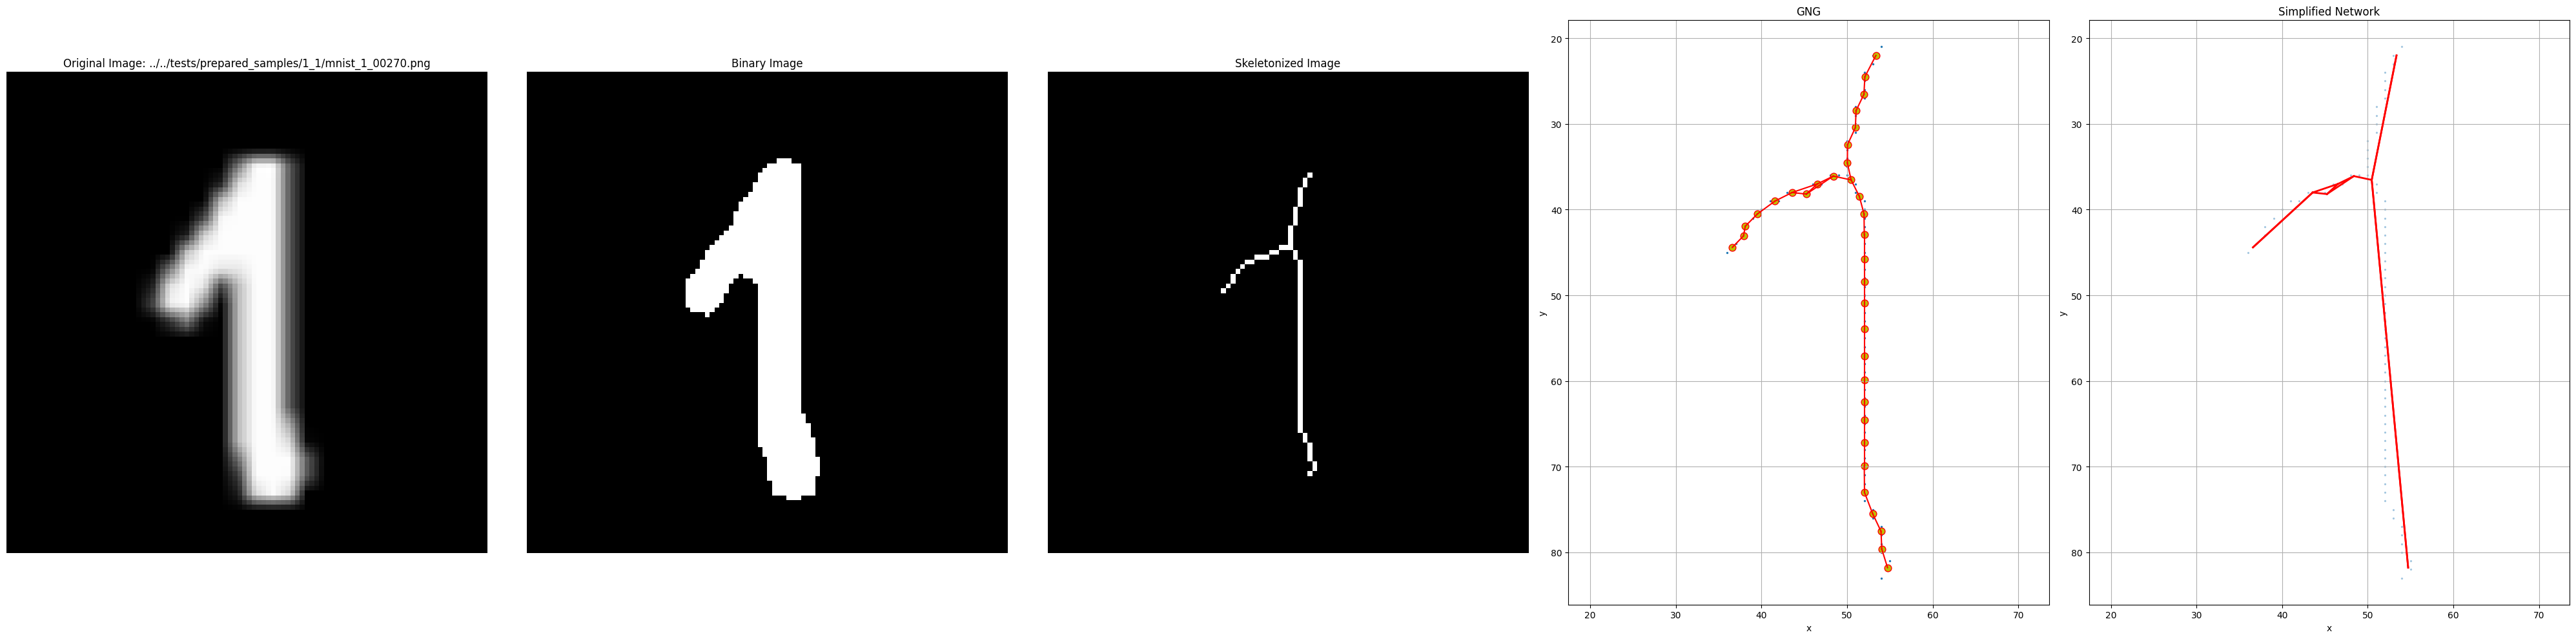

Cycles: 3
Top leftmost point: {'x': 53.361469386704904, 'y': 22.00934585442564, 'uuid': '7d6659eb-9f7f-4b2e-9851-6c44dd8e942a'}
Vector 1: x1: 53.361469386704904, y1: 22.00934585442564, x2: 50.464473426558655, y2: 36.53733576764359
Vector 2: x1: 50.464473426558655, y1: 36.53733576764359, x2: 54.71940597508185, y2: 81.79026745675016
Vector 3: x1: 50.464473426558655, y1: 36.53733576764359, x2: 48.38085429001122, y2: 36.09105606111517
Vector 4: x1: 48.38085429001122, y1: 36.09105606111517, x2: 45.23500623044553, y2: 38.186780904364255
Vector 5: x1: 45.23500623044553, y1: 38.186780904364255, x2: 43.566987087420856, y2: 38.00568096861386
Vector 6: x1: 43.566987087420856, y1: 38.00568096861386, x2: 36.59499292710365, y2: 44.405001464929335
Vector 7: x1: 43.566987087420856, y1: 38.00568096861386, x2: 46.51081388739134, y2: 37.00793760381053
Vector 8: x1: 46.51081388739134, y1: 37.00793760381053, x2: 45.23500623044553, y2: 38.186780904364255
Vector 9: x1: 46.51081388739134, y1: 37.0079376038105

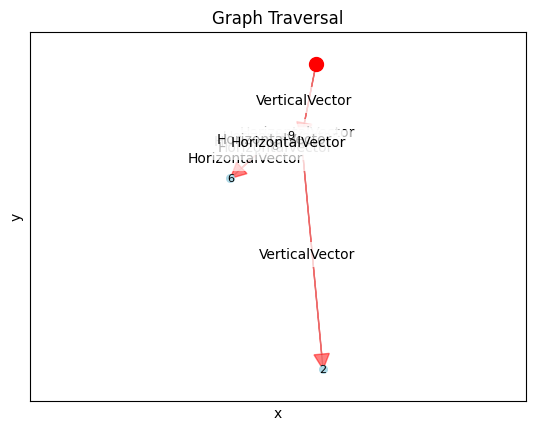

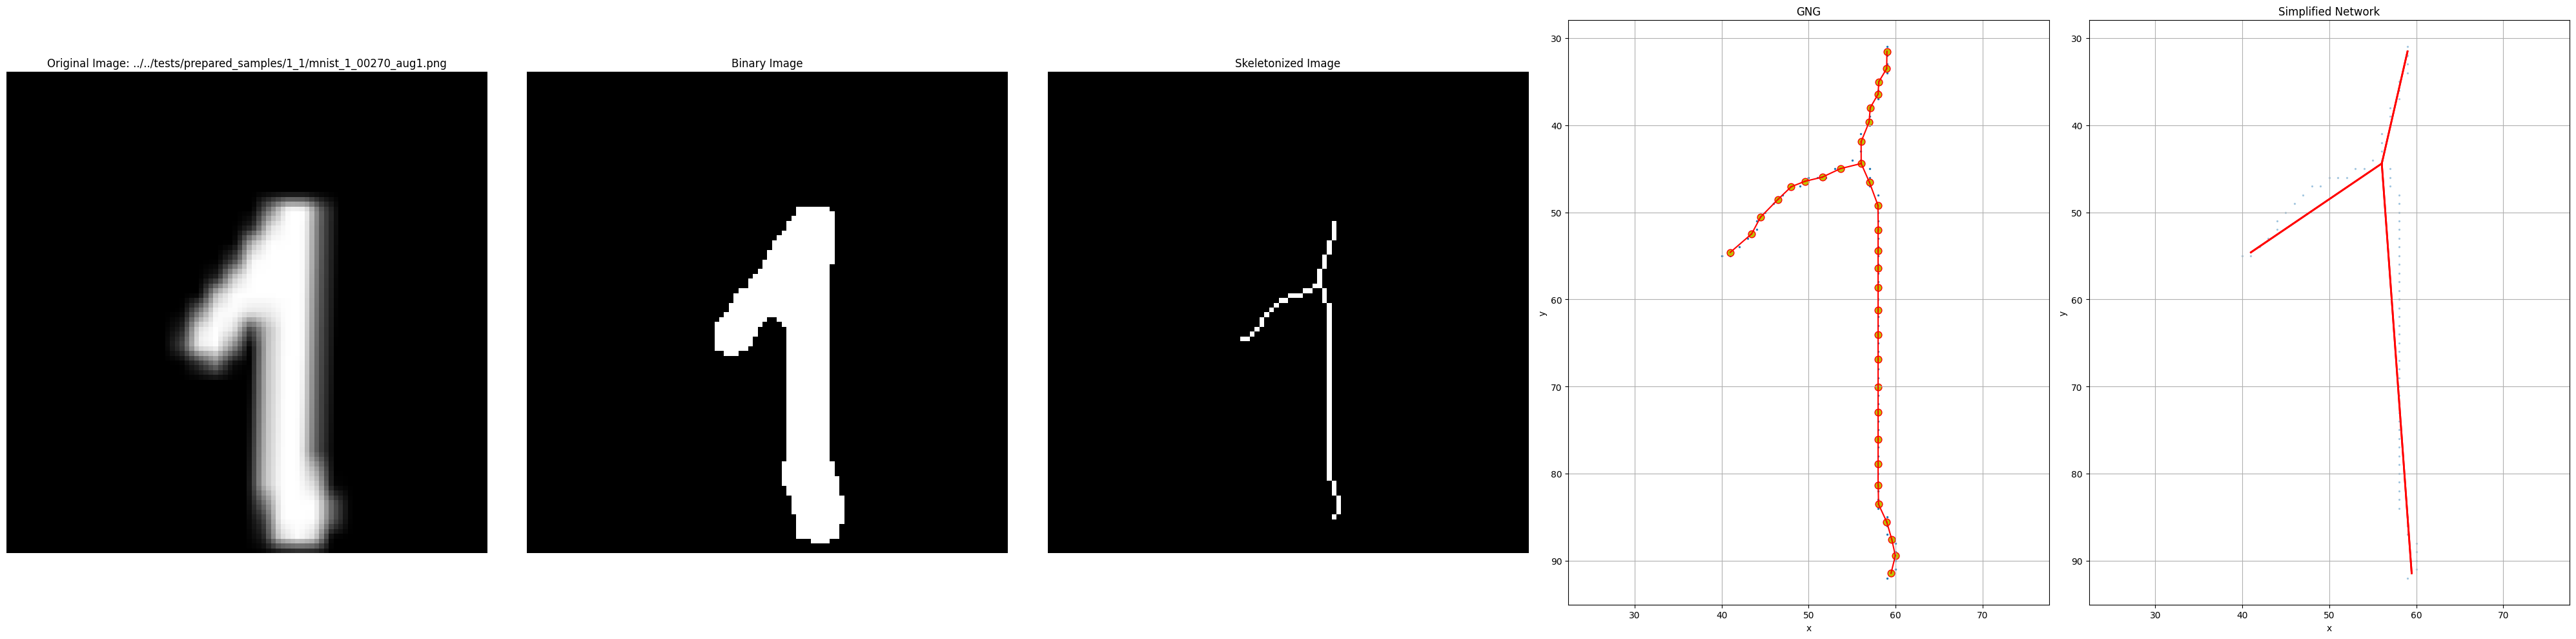

Cycles: 0
Top leftmost point: {'x': 58.99999926878389, 'y': 31.527663149236272, 'uuid': '5571d36b-929c-40c2-88f3-b2315c391869'}
Vector 1: x1: 58.99999926878389, y1: 31.527663149236272, x2: 56.040399194636066, y2: 44.40404277219453
Vector 2: x1: 56.040399194636066, y1: 44.40404277219453, x2: 59.47410483402274, y2: 91.44567491291909
Vector 3: x1: 56.040399194636066, y1: 44.40404277219453, x2: 41.0010791089659, y2: 54.60148120551751


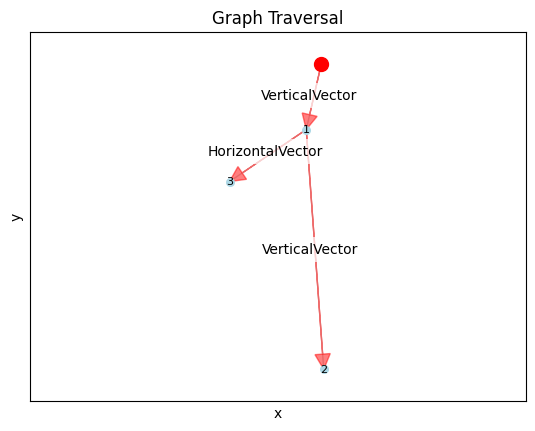

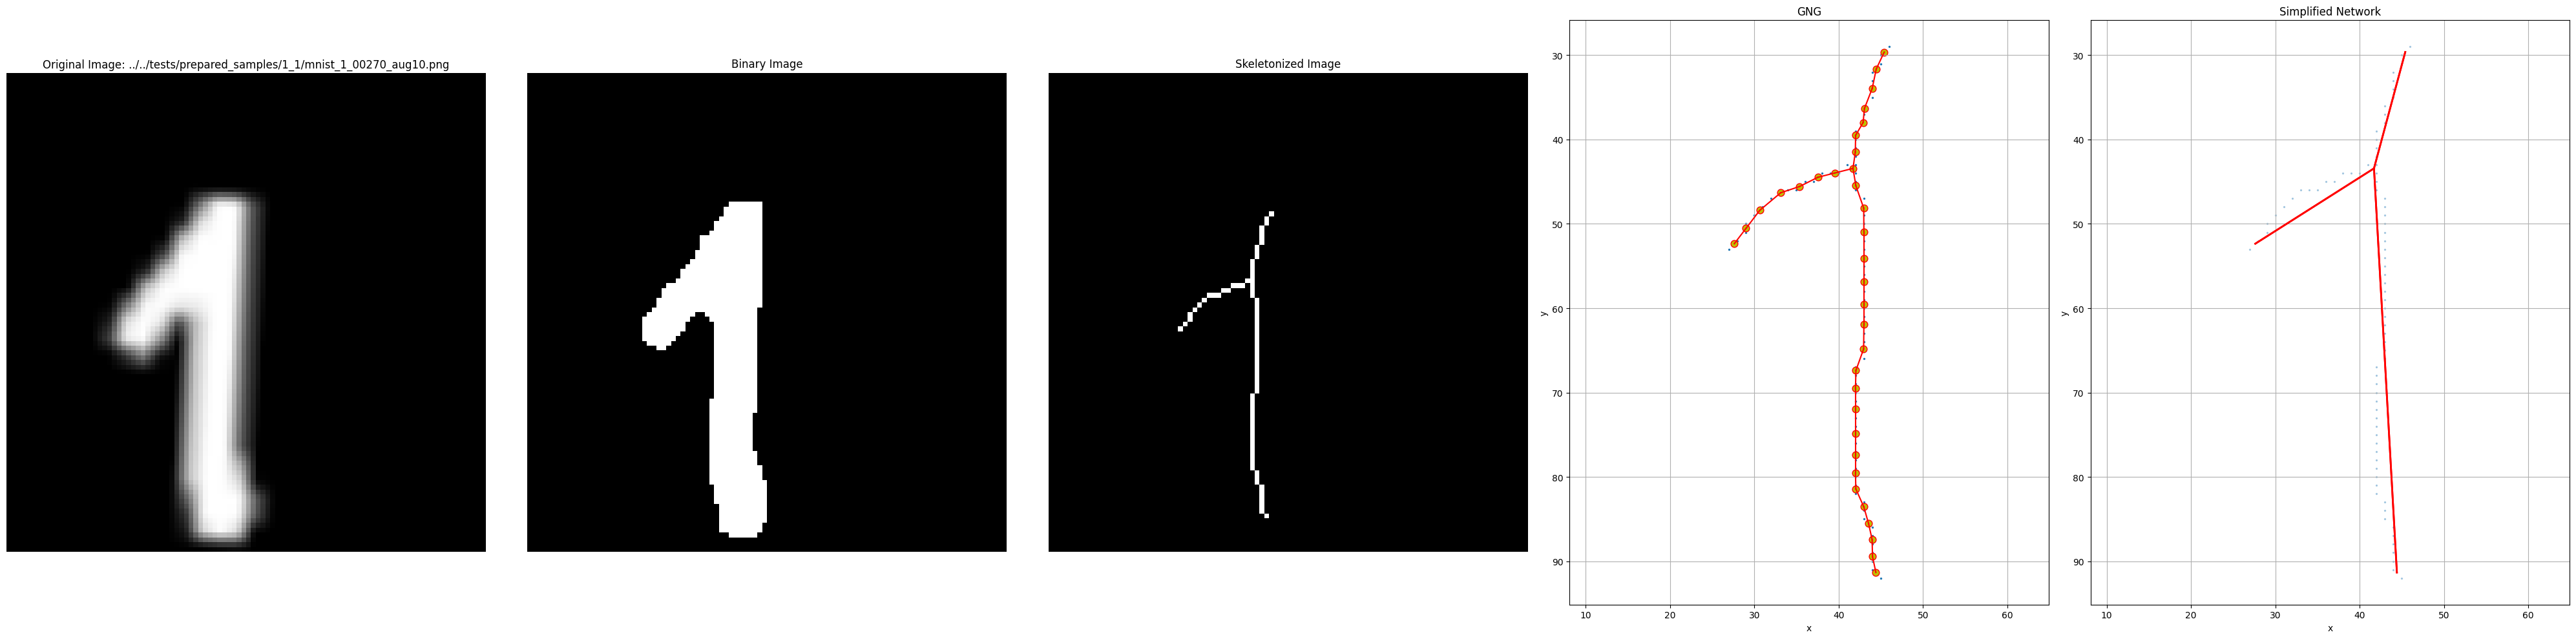

Cycles: 0
Top leftmost point: {'x': 45.41208788334539, 'y': 29.62208113445511, 'uuid': '4c66c85b-9939-4f4f-87a6-6d9017d16163'}
Vector 1: x1: 45.41208788334539, y1: 29.62208113445511, x2: 41.704704195489875, y2: 43.42049066872488
Vector 2: x1: 41.704704195489875, y1: 43.42049066872488, x2: 44.42071598742188, y2: 91.34049830687313
Vector 3: x1: 41.704704195489875, y1: 43.42049066872488, x2: 27.627360946523737, y2: 52.35139076356954


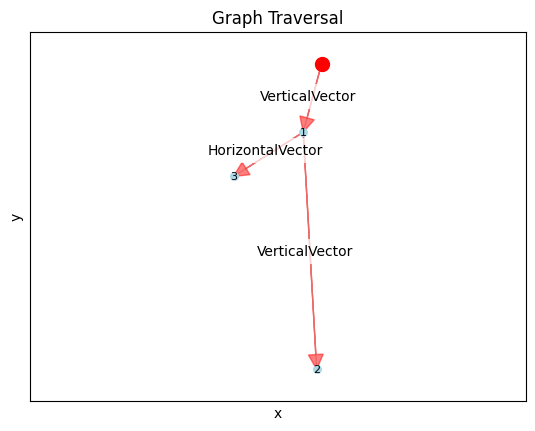

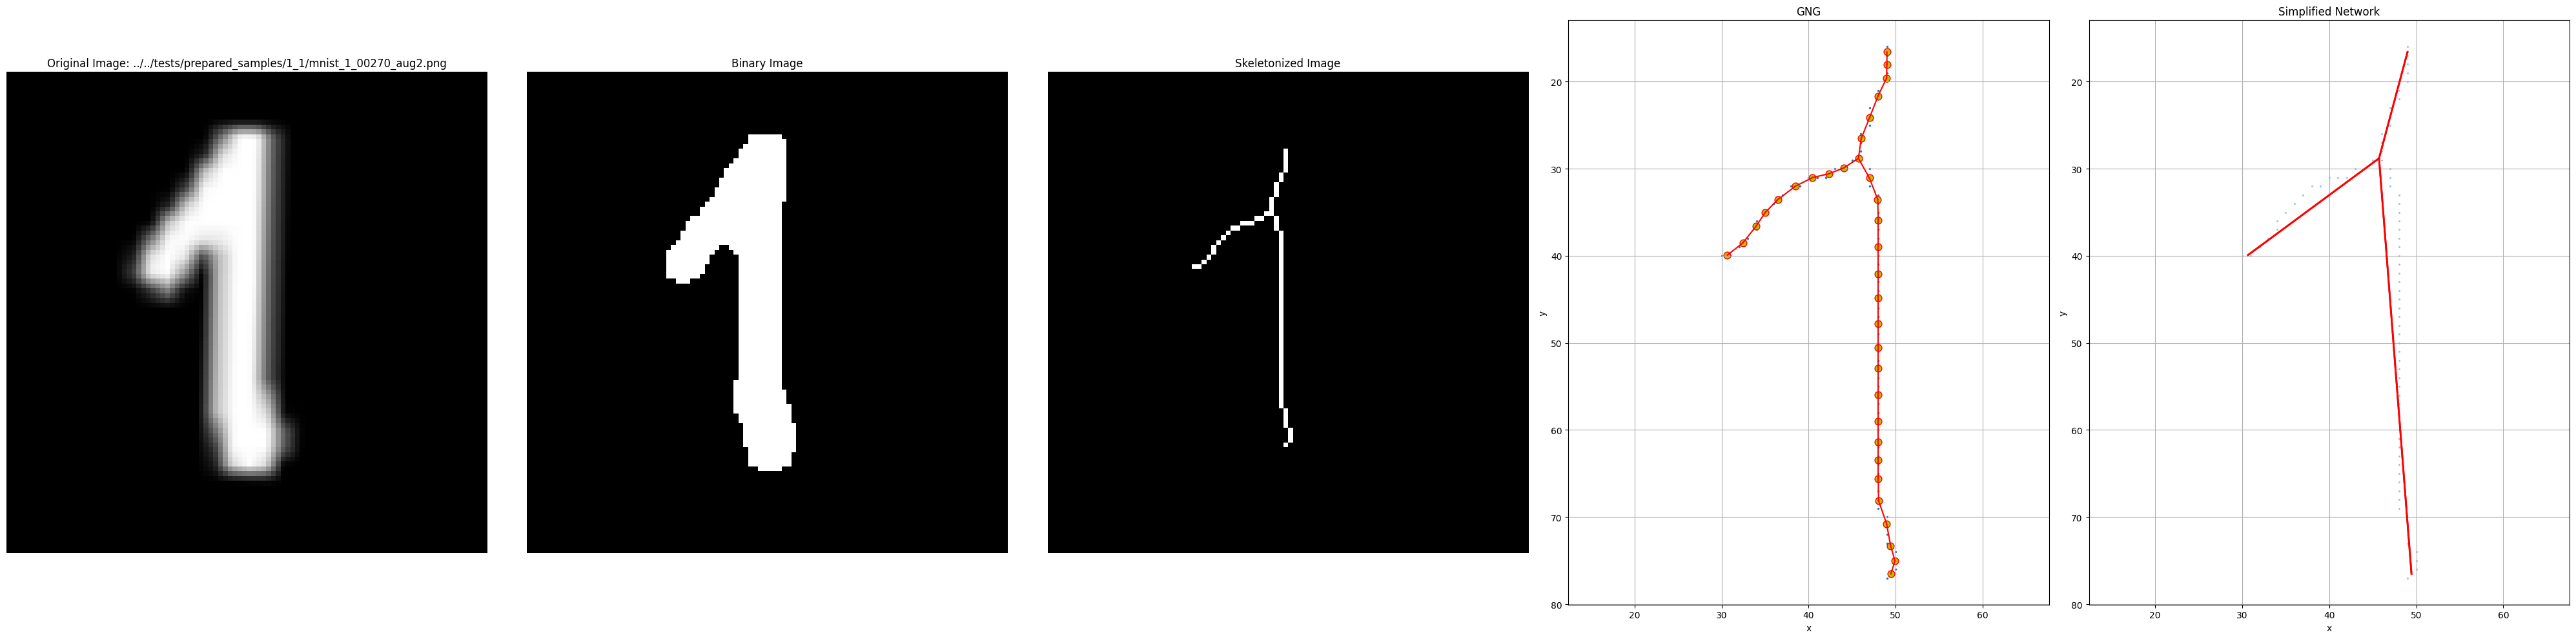

Cycles: 0
Top leftmost point: {'x': 48.999999951252086, 'y': 16.58951991889716, 'uuid': 'a347edd2-6ee3-406a-8db6-156722429848'}
Vector 1: x1: 48.999999951252086, y1: 16.58951991889716, x2: 45.72510000045186, y2: 28.80466553574676
Vector 2: x1: 45.72510000045186, y1: 28.80466553574676, x2: 30.659233398325675, y2: 39.920050612270074
Vector 3: x1: 45.72510000045186, y1: 28.80466553574676, x2: 49.45414830211424, y2: 76.52400960770714


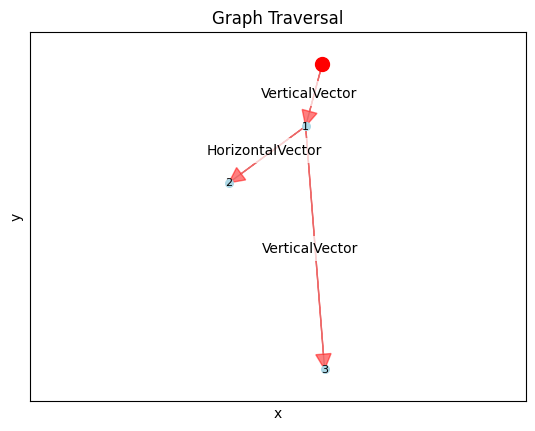

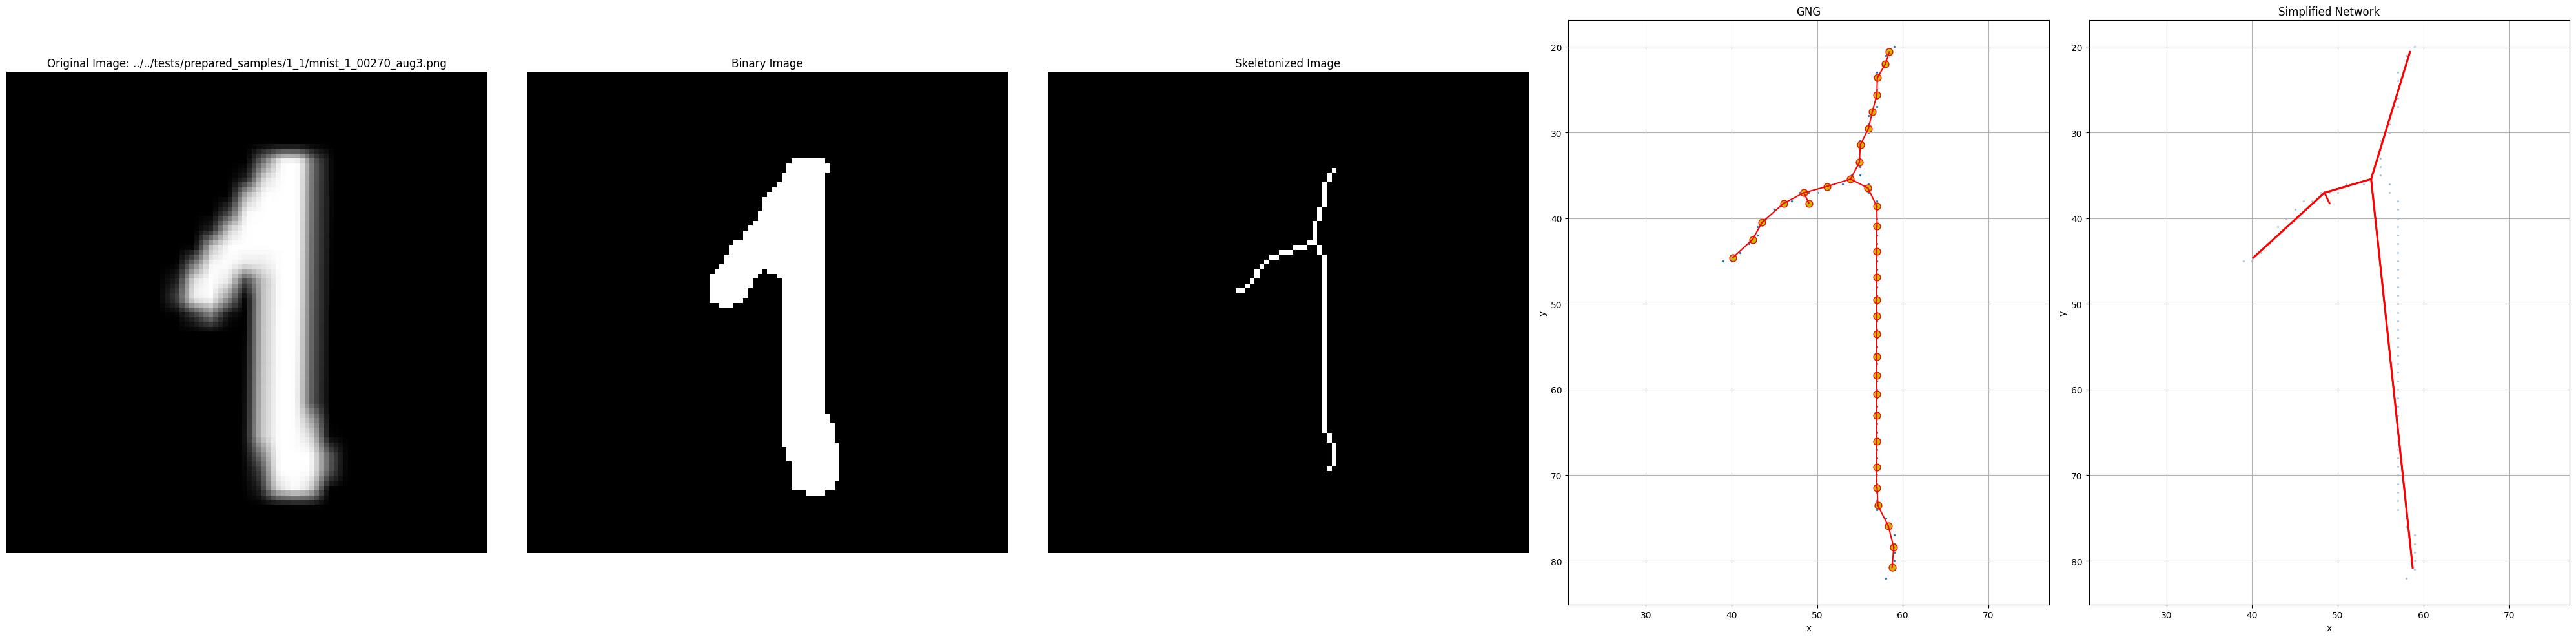

Cycles: 0
Top leftmost point: {'x': 58.43231383615588, 'y': 20.594980109949546, 'uuid': 'a858edb4-7301-4a73-9303-dd10660f1046'}
Vector 1: x1: 58.43231383615588, y1: 20.594980109949546, x2: 53.89338635790406, y2: 35.43758323687753
Vector 2: x1: 53.89338635790406, y1: 35.43758323687753, x2: 48.44104694807926, y2: 37.03548613061527
Vector 3: x1: 48.44104694807926, y1: 37.03548613061527, x2: 40.13974461088062, y2: 44.608437604376164
Vector 4: x1: 48.44104694807926, y1: 37.03548613061527, x2: 49.04350359484536, y2: 38.26527711060104
Vector 5: x1: 53.89338635790406, y1: 35.43758323687753, x2: 58.748182215257195, y2: 80.77039387476584


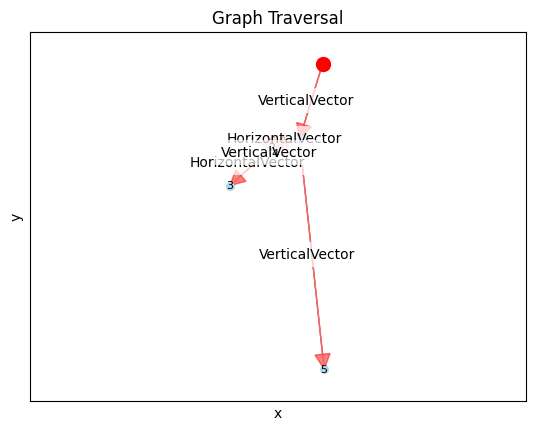

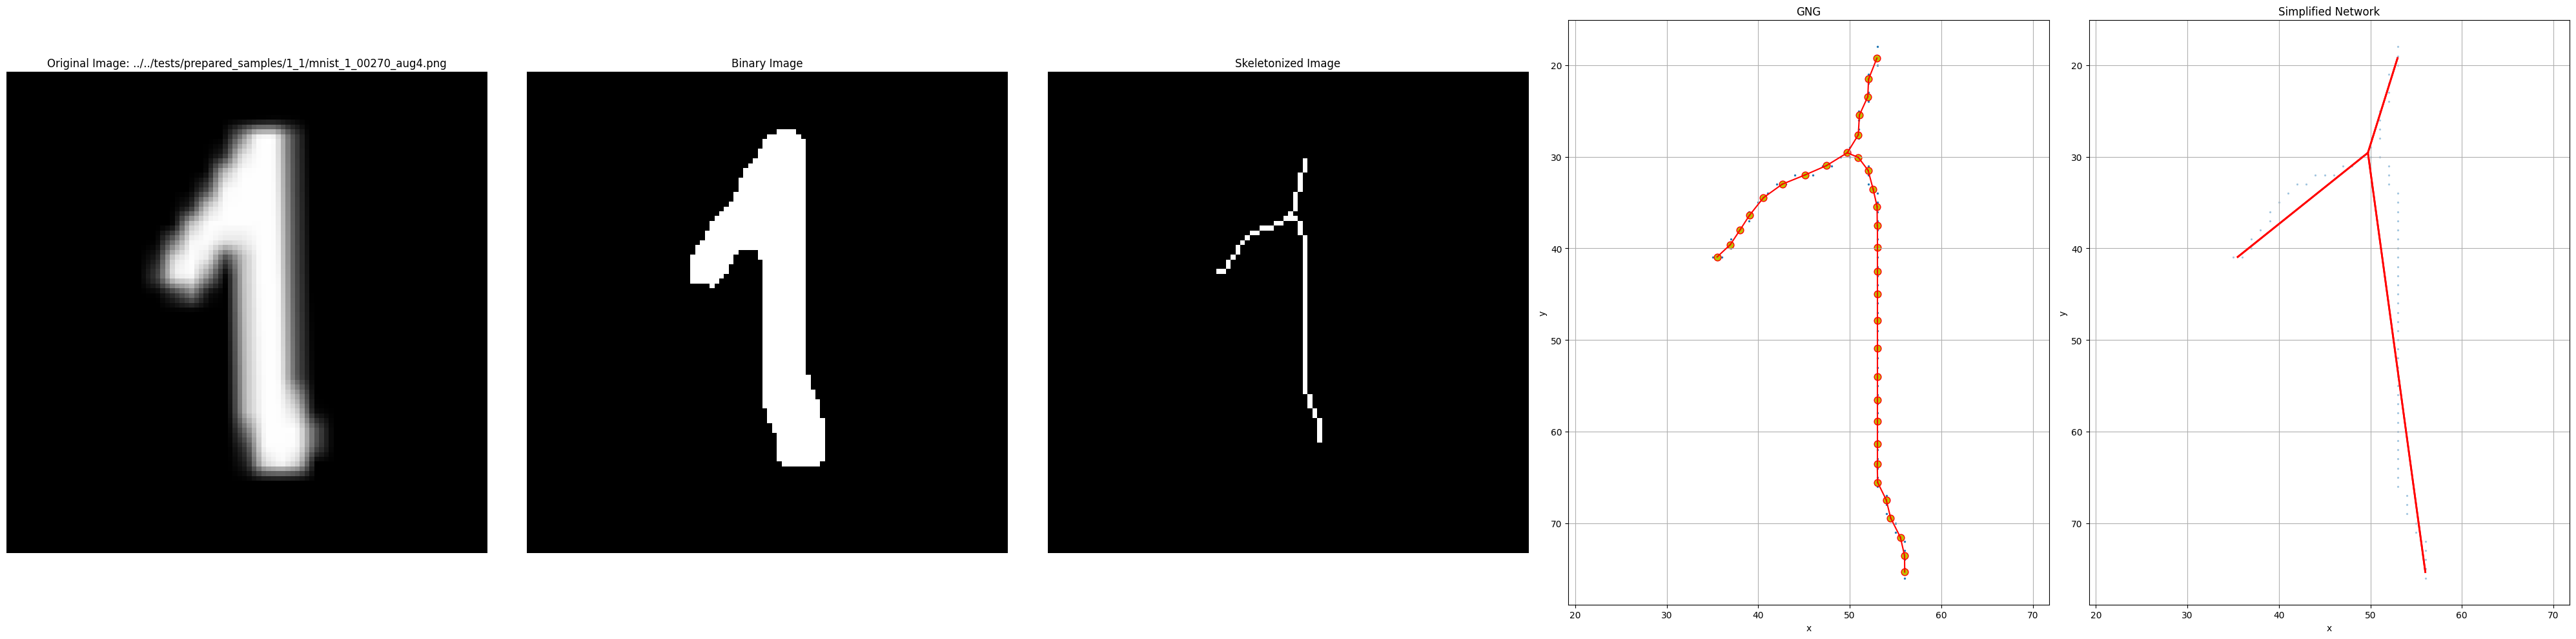

Cycles: 0
Top leftmost point: {'x': 52.96402970118893, 'y': 19.237635209785573, 'uuid': '3d7a25e7-2e71-420e-8752-93e0e8e83813'}
Vector 1: x1: 52.96402970118893, y1: 19.237635209785573, x2: 49.72712507677935, y2: 29.57118957401312
Vector 2: x1: 49.72712507677935, y1: 29.57118957401312, x2: 55.99999999826377, y2: 75.34076659741949
Vector 3: x1: 49.72712507677935, y1: 29.57118957401312, x2: 35.501888834449346, y2: 40.94453976142817


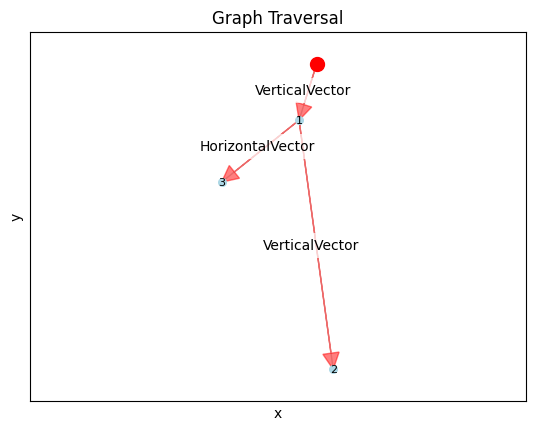

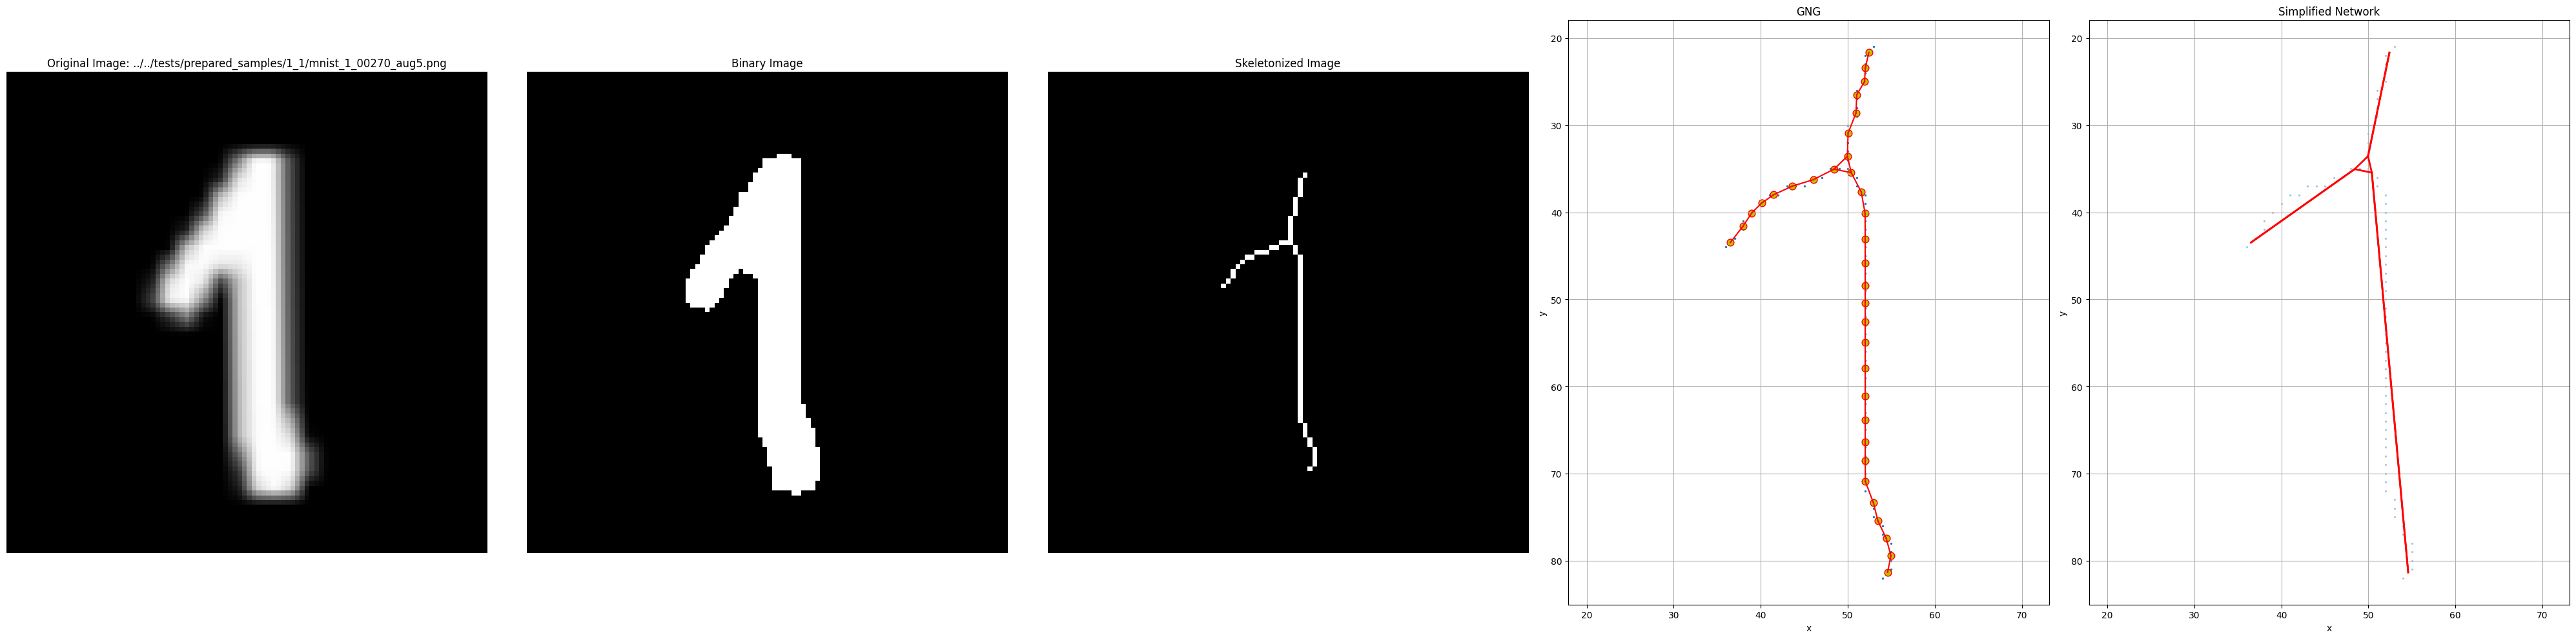

Cycles: 1
Top leftmost point: {'x': 52.42071592230491, 'y': 21.659233710959874, 'uuid': 'b7428806-70e3-49ca-8f0a-770acbf5d2f5'}
Vector 1: x1: 52.42071592230491, y1: 21.659233710959874, x2: 49.960552818118515, y2: 33.55764362774363
Vector 2: x1: 49.960552818118515, y1: 33.55764362774363, x2: 50.393894501994616, y2: 35.44682178695785
Vector 3: x1: 50.393894501994616, y1: 35.44682178695785, x2: 54.5750343853476, y2: 81.35430951826264
Vector 4: x1: 50.393894501994616, y1: 35.44682178695785, x2: 48.41767324132315, y2: 35.048582400513205
Vector 5: x1: 48.41767324132315, y1: 35.048582400513205, x2: 36.50620255724893, y2: 43.472530941729374
Vector 6: x1: 48.41767324132315, y1: 35.048582400513205, x2: 49.960552818118515, y2: 33.55764362774363


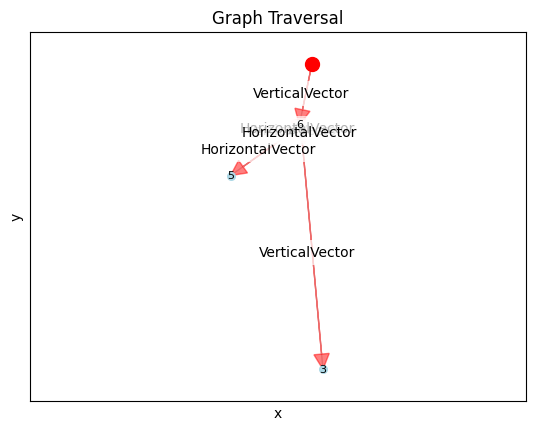

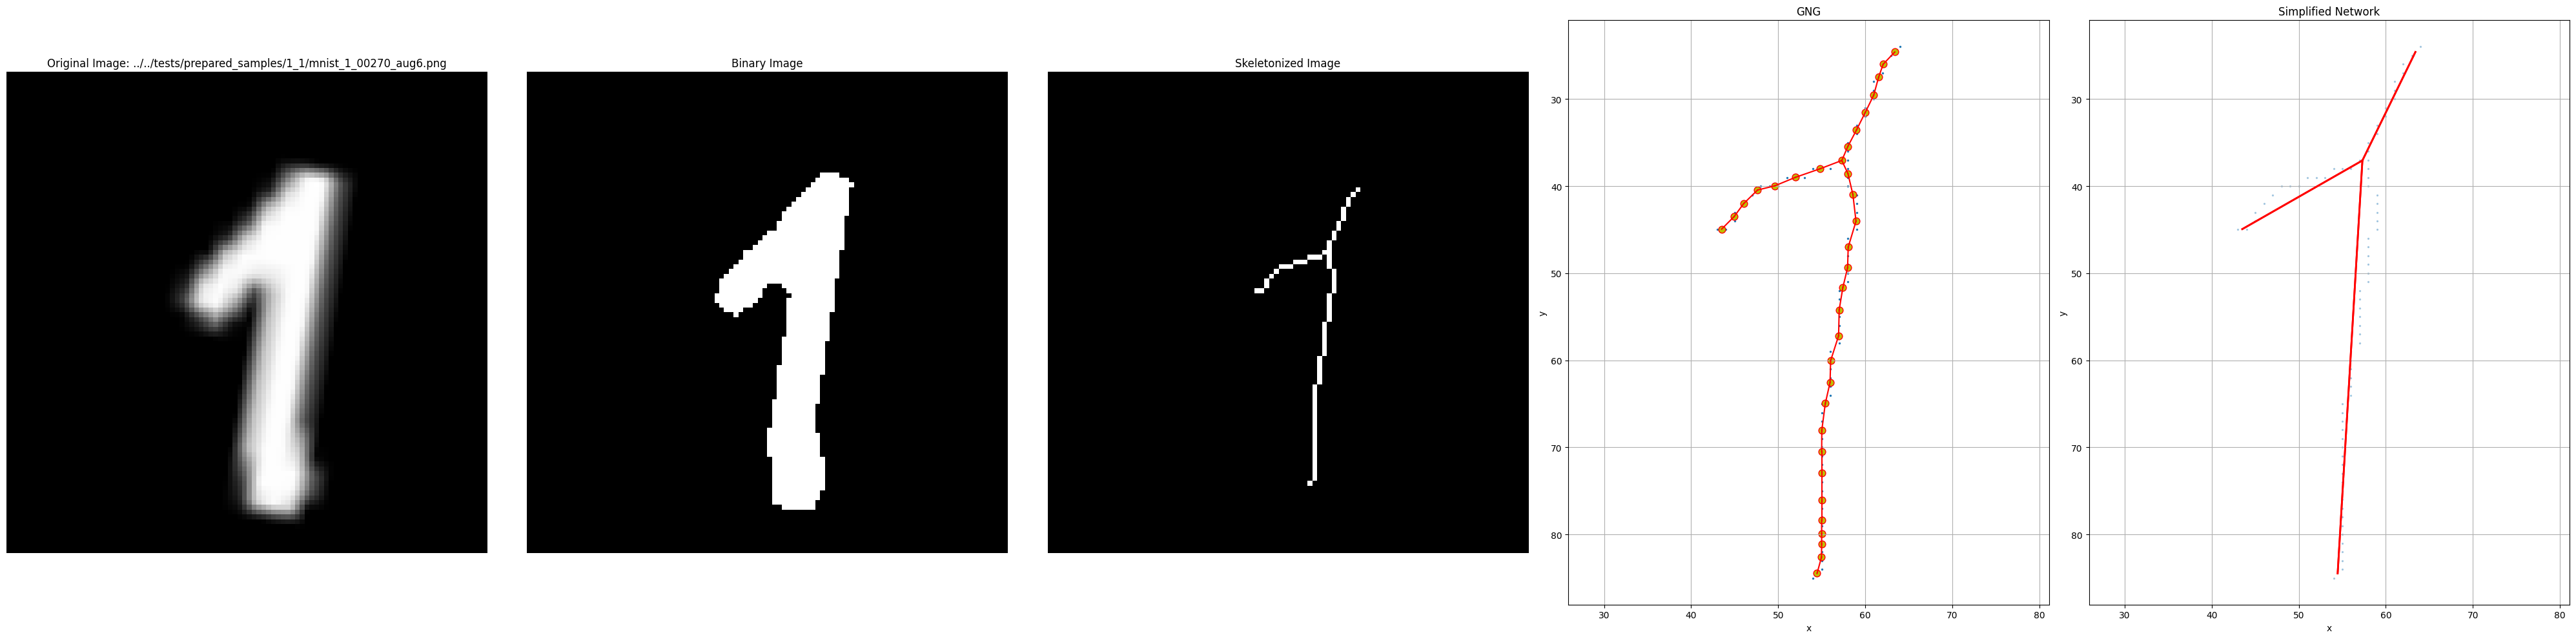

Cycles: 0
Top leftmost point: {'x': 63.40502137105513, 'y': 24.594978994270363, 'uuid': '85622f37-72ea-434d-9105-d40f0e8ee7ae'}
Vector 1: x1: 63.40502137105513, y1: 24.594978994270363, x2: 57.313737908256996, y2: 37.05349024068704
Vector 2: x1: 57.313737908256996, y1: 37.05349024068704, x2: 54.46879635036688, y2: 84.47035969691773
Vector 3: x1: 57.313737908256996, y1: 37.05349024068704, x2: 43.50613858731158, y2: 44.93582573504002


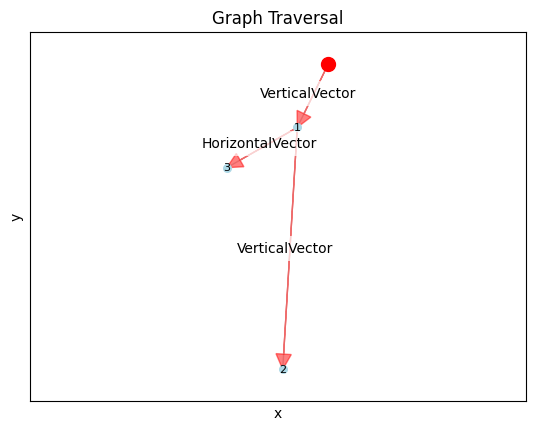

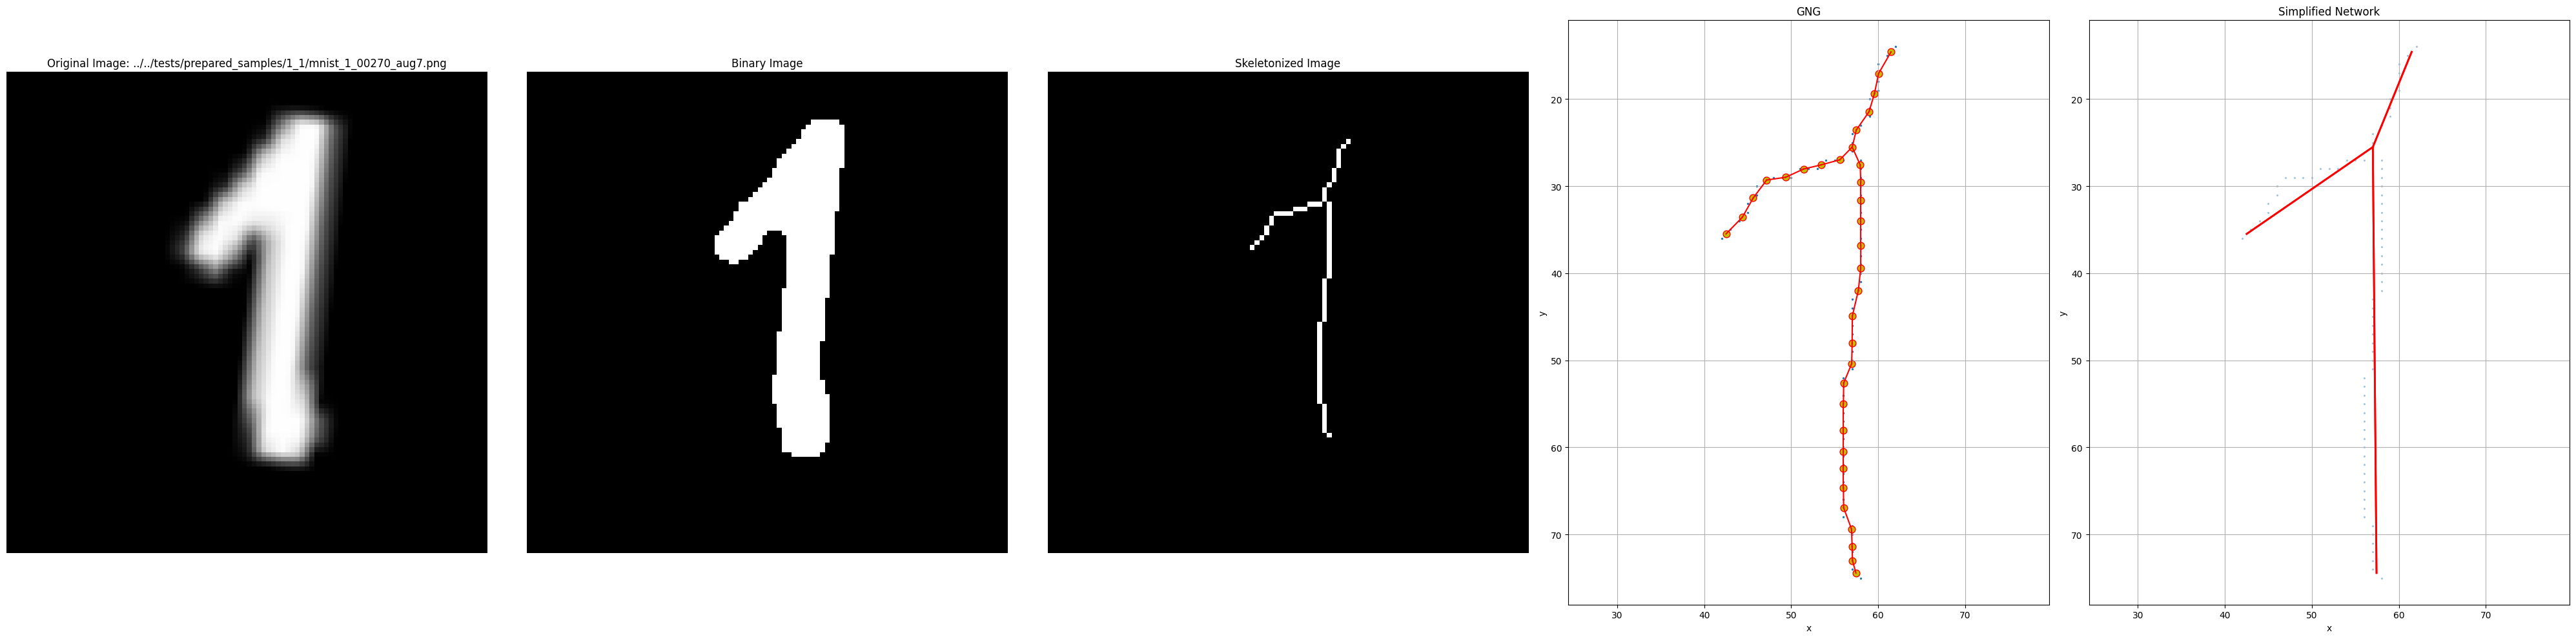

Cycles: 0
Top leftmost point: {'x': 61.473317326433786, 'y': 14.58544819601708, 'uuid': 'dd551dc4-f48b-4ae2-b9ea-0b03a5c4a604'}
Vector 1: x1: 61.473317326433786, y1: 14.58544819601708, x2: 57.01153881200724, y2: 25.513331340908294
Vector 2: x1: 57.01153881200724, y1: 25.513331340908294, x2: 42.51459720266022, y2: 35.48540198424622
Vector 3: x1: 57.01153881200724, y1: 25.513331340908294, x2: 57.43668118832089, y2: 74.41921384774493


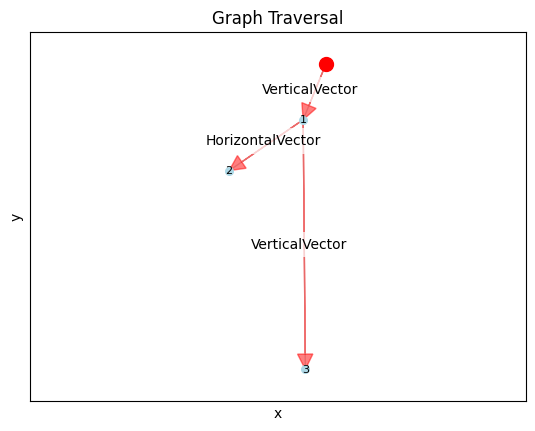

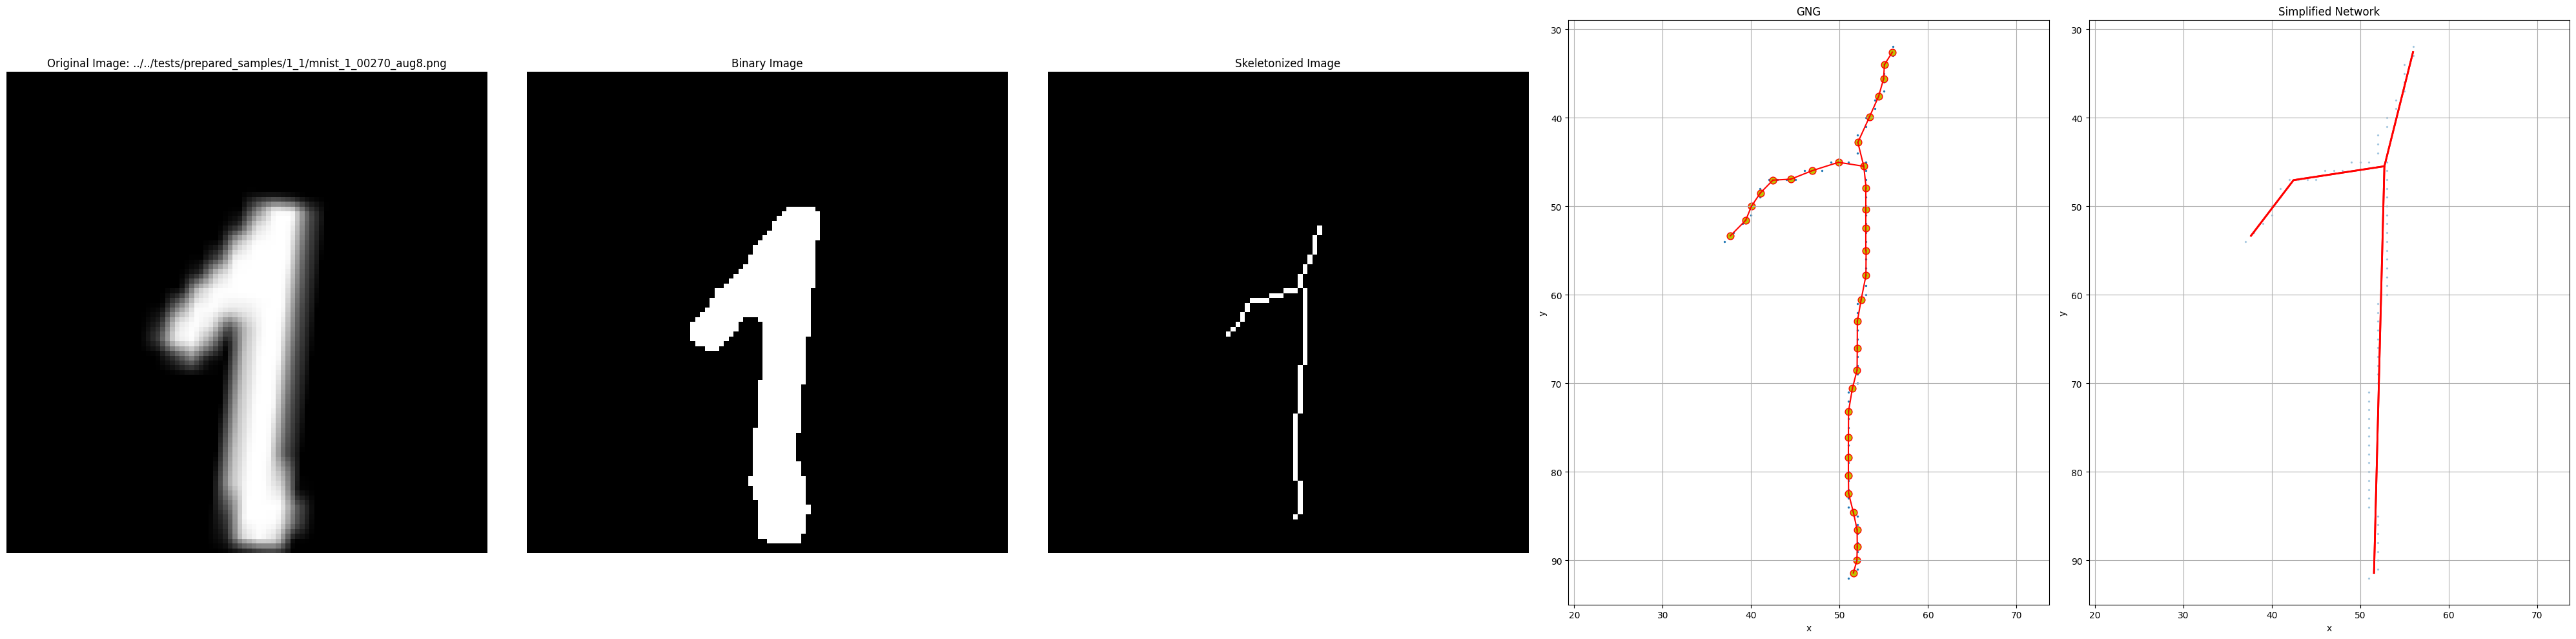

Cycles: 0
Top leftmost point: {'x': 55.97270627558757, 'y': 32.59497998428778, 'uuid': '801386e5-bd99-4d2d-97be-596130a1e2e4'}
Vector 1: x1: 55.97270627558757, y1: 32.59497998428778, x2: 52.735857864547626, y2: 45.490028493769486
Vector 2: x1: 52.735857864547626, y1: 45.490028493769486, x2: 42.46168905483569, y2: 47.06086056863895
Vector 3: x1: 42.46168905483569, y1: 47.06086056863895, x2: 37.659233377463565, y2: 53.34076662038082
Vector 4: x1: 52.735857864547626, y1: 45.490028493769486, x2: 51.56331881267967, y2: 91.41921383992855


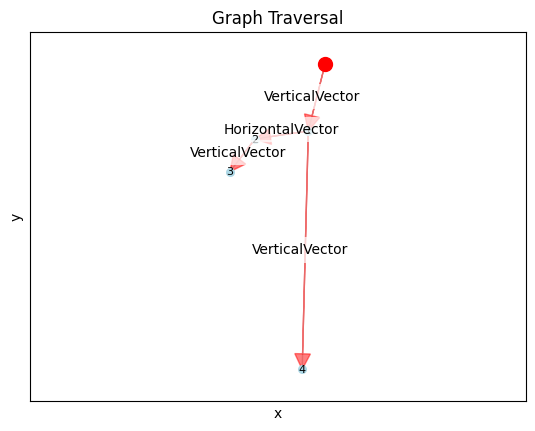

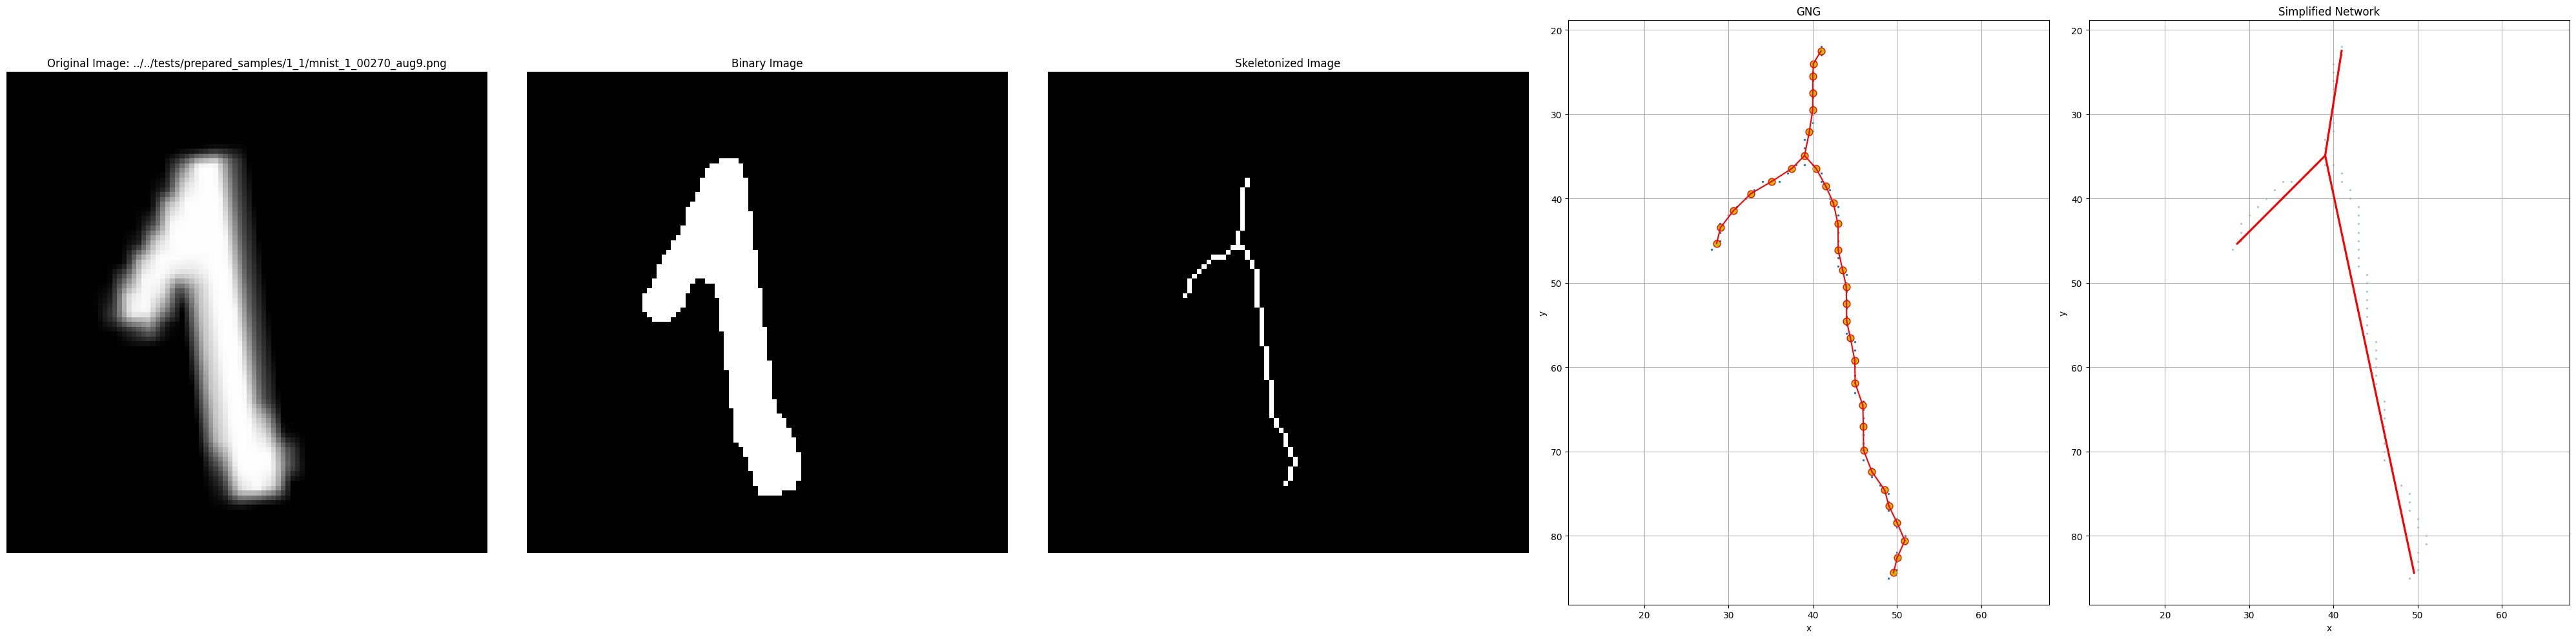

Cycles: 0
Top leftmost point: {'x': 40.972707375261436, 'y': 22.48689964976546, 'uuid': '3a8f279d-72b1-44b8-b6c2-f891485cf635'}
Vector 1: x1: 40.972707375261436, y1: 22.48689964976546, x2: 39.01936805223819, y2: 34.90201055483158
Vector 2: x1: 39.01936805223819, y1: 34.90201055483158, x2: 28.579284023444625, y2: 45.3458103566801
Vector 3: x1: 39.01936805223819, y1: 34.90201055483158, x2: 49.5707417787787, y2: 84.37809059659727


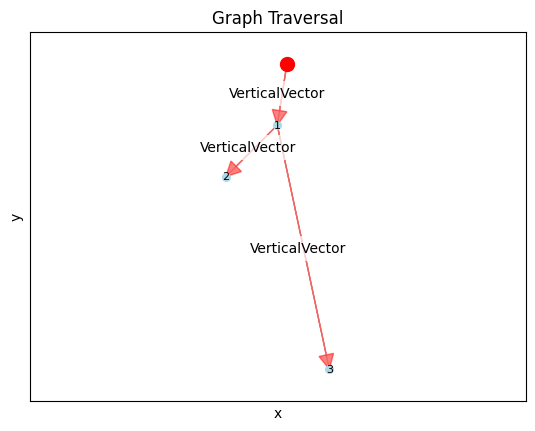

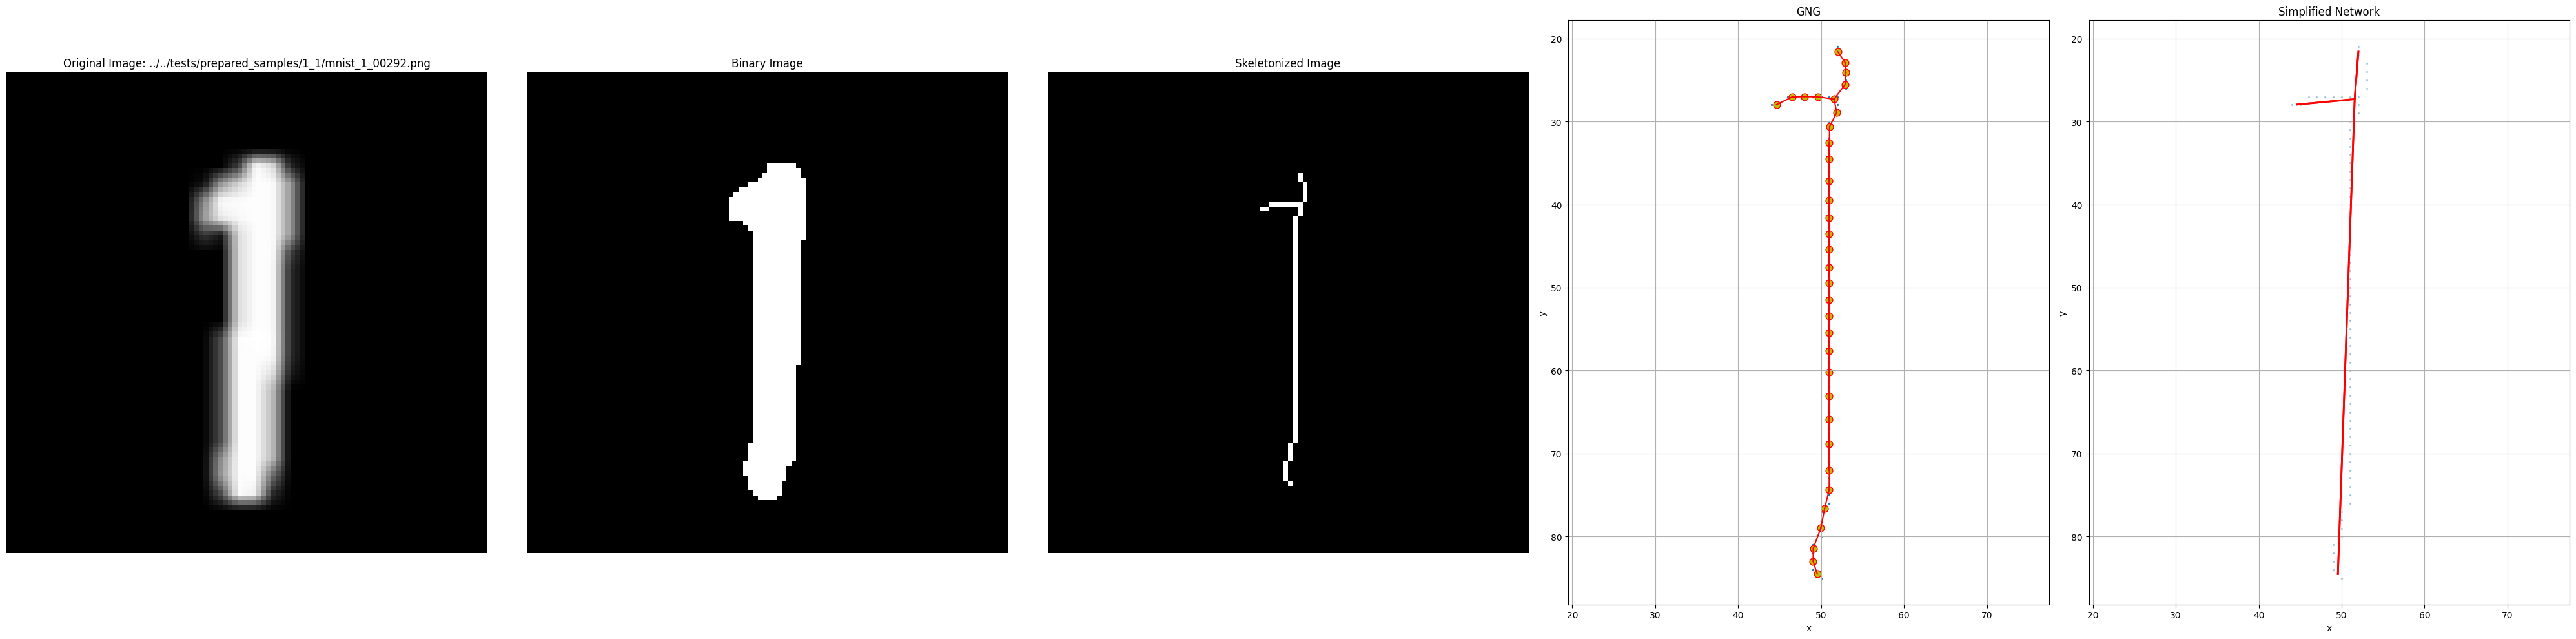

Cycles: 0
Top leftmost point: {'x': 44.64569092811778, 'y': 27.95617257264699, 'uuid': 'c17c34a7-7484-4729-b814-1969b120cdea'}
Vector 1: x1: 44.64569092811778, y1: 27.95617257264699, x2: 51.57052285986482, y2: 27.302989697018923
Vector 2: x1: 51.57052285986482, y1: 27.302989697018923, x2: 52.01746733174613, y2: 21.580786173698844
Vector 3: x1: 51.57052285986482, y1: 27.302989697018923, x2: 49.54585150166777, y2: 84.52401737045417


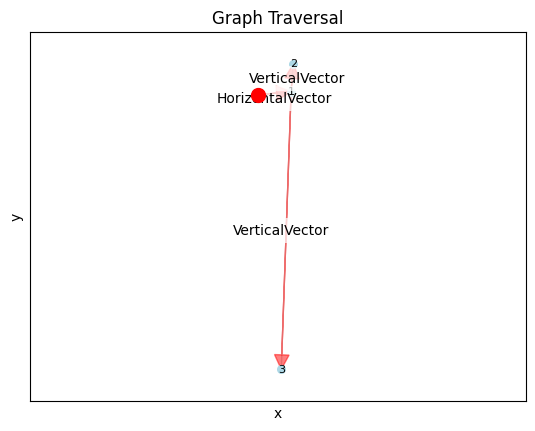

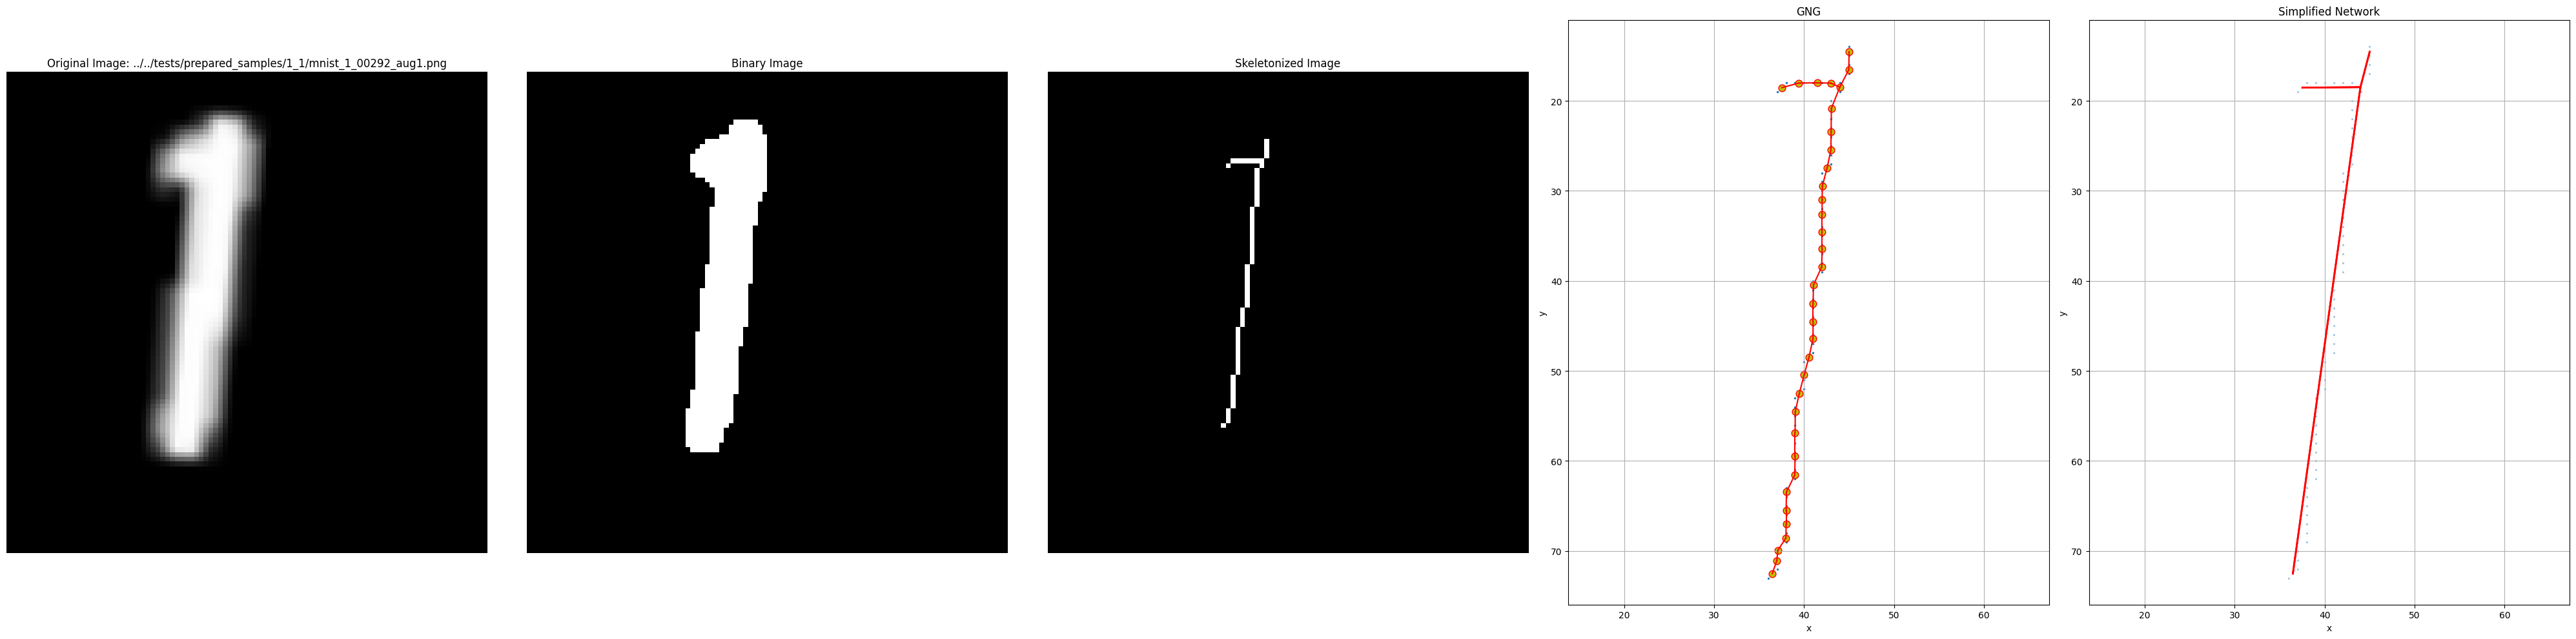

Cycles: 0
Top leftmost point: {'x': 37.51888756567993, 'y': 18.536572885995962, 'uuid': '4fefd84d-fd74-4b6f-937e-1741512aab45'}
Vector 1: x1: 37.51888756567993, y1: 18.536572885995962, x2: 43.96927292465903, y2: 18.47995488310907
Vector 2: x1: 43.96927292465903, y1: 18.47995488310907, x2: 36.4596070307082, y2: 72.51310029874922
Vector 3: x1: 43.96927292465903, y1: 18.47995488310907, x2: 44.999994077449735, y2: 14.543708544857154


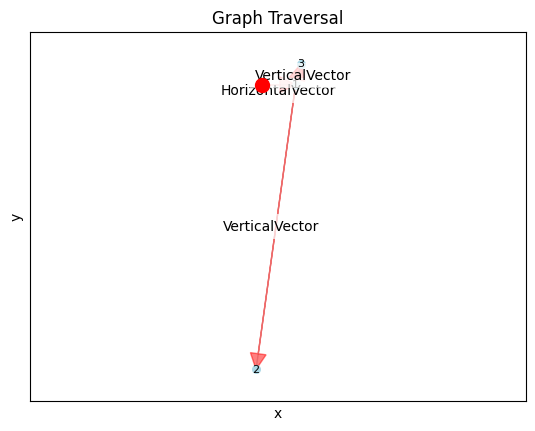

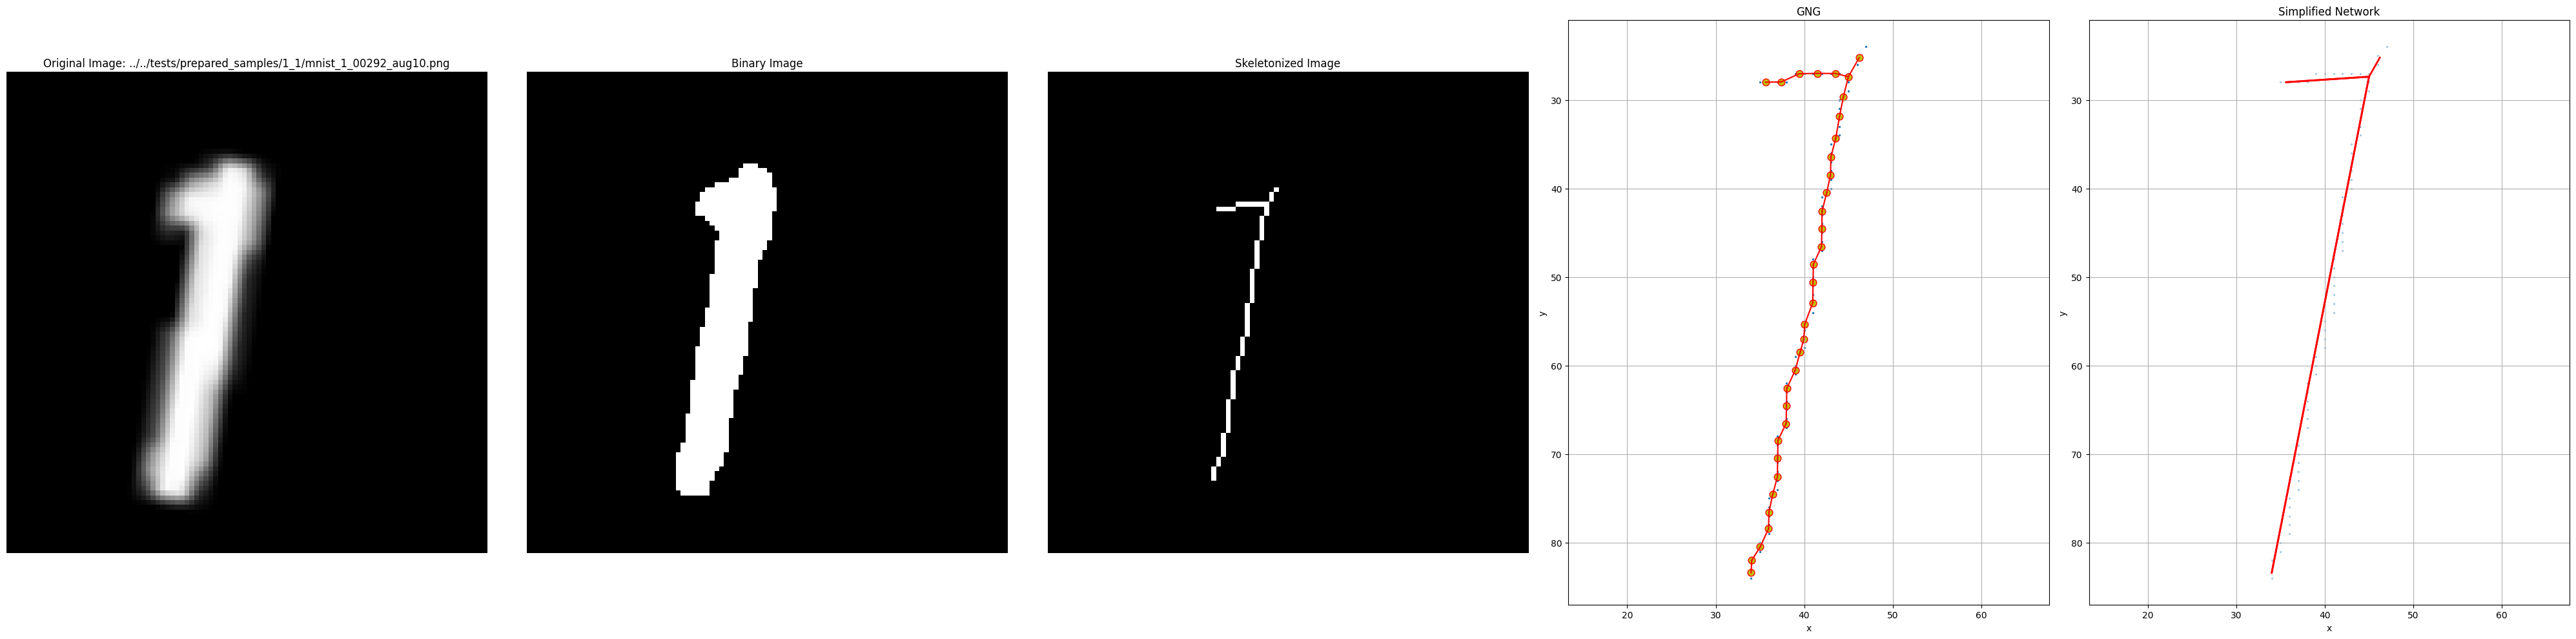

Cycles: 0
Top leftmost point: {'x': 35.62190938070132, 'y': 27.999999997732743, 'uuid': '523dda6f-e6e7-469b-aff6-2d373104e89b'}
Vector 1: x1: 35.62190938070132, y1: 27.999999997732743, x2: 44.99945035222354, y2: 27.37664312983847
Vector 2: x1: 44.99945035222354, y1: 27.37664312983847, x2: 46.22242482584253, y2: 25.22035415806276
Vector 3: x1: 44.99945035222354, y1: 27.37664312983847, x2: 34.00000002393551, y2: 83.40502137623697


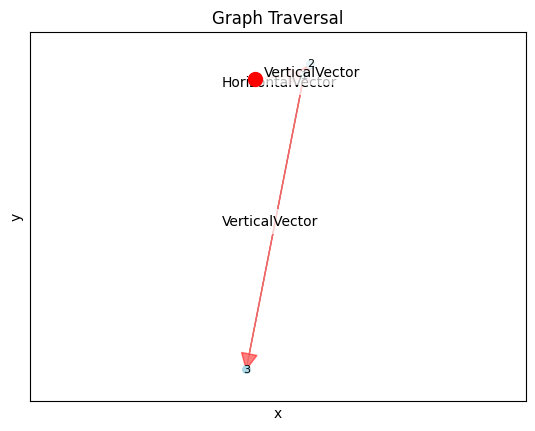

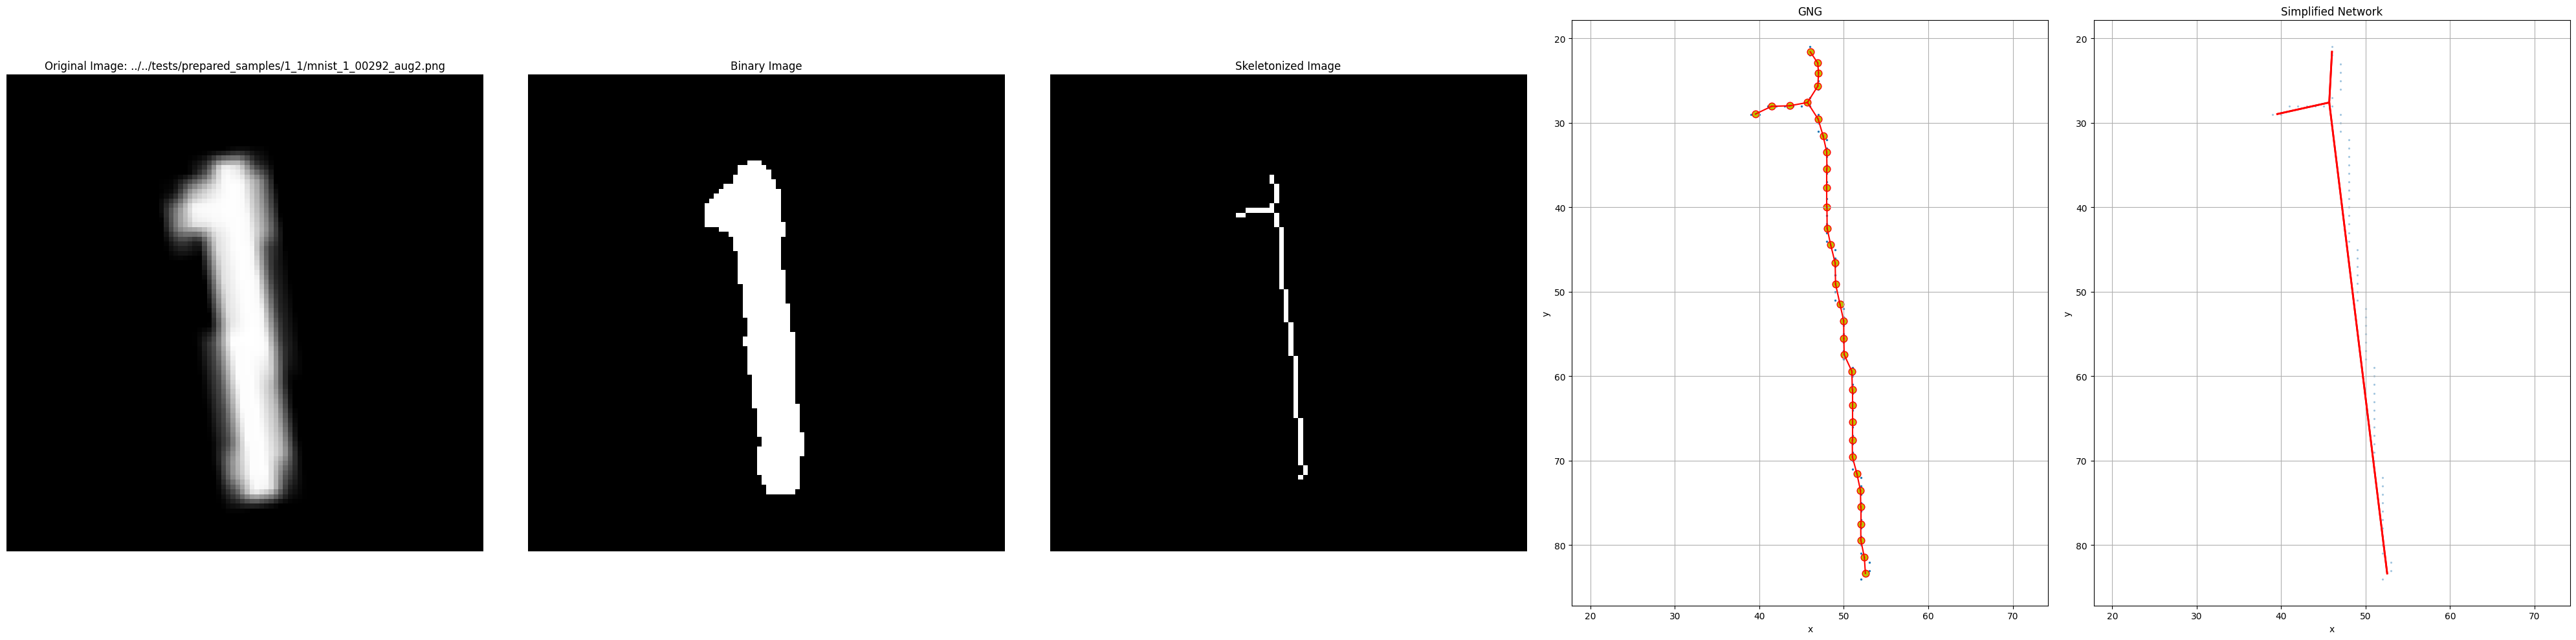

Cycles: 0
Top leftmost point: {'x': 46.01746730237021, 'y': 21.580786119663493, 'uuid': '57ac3661-16b6-424d-b5a0-2197907f502e'}
Vector 1: x1: 46.01746730237021, y1: 21.580786119663493, x2: 45.69206062785833, y2: 27.584340663691904
Vector 2: x1: 45.69206062785833, y1: 27.584340663691904, x2: 52.55245537581949, y2: 83.34581036563716
Vector 3: x1: 45.69206062785833, y1: 27.584340663691904, x2: 39.53811816052719, y2: 28.951923063280198


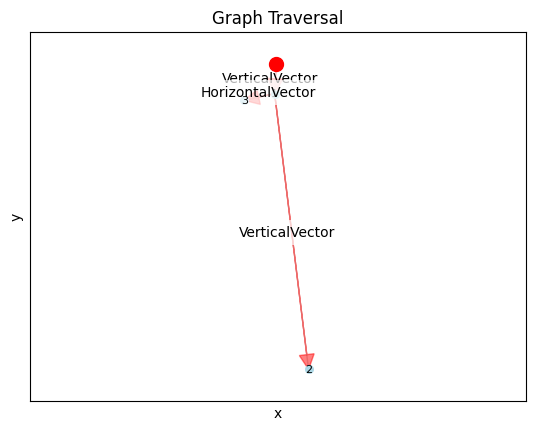

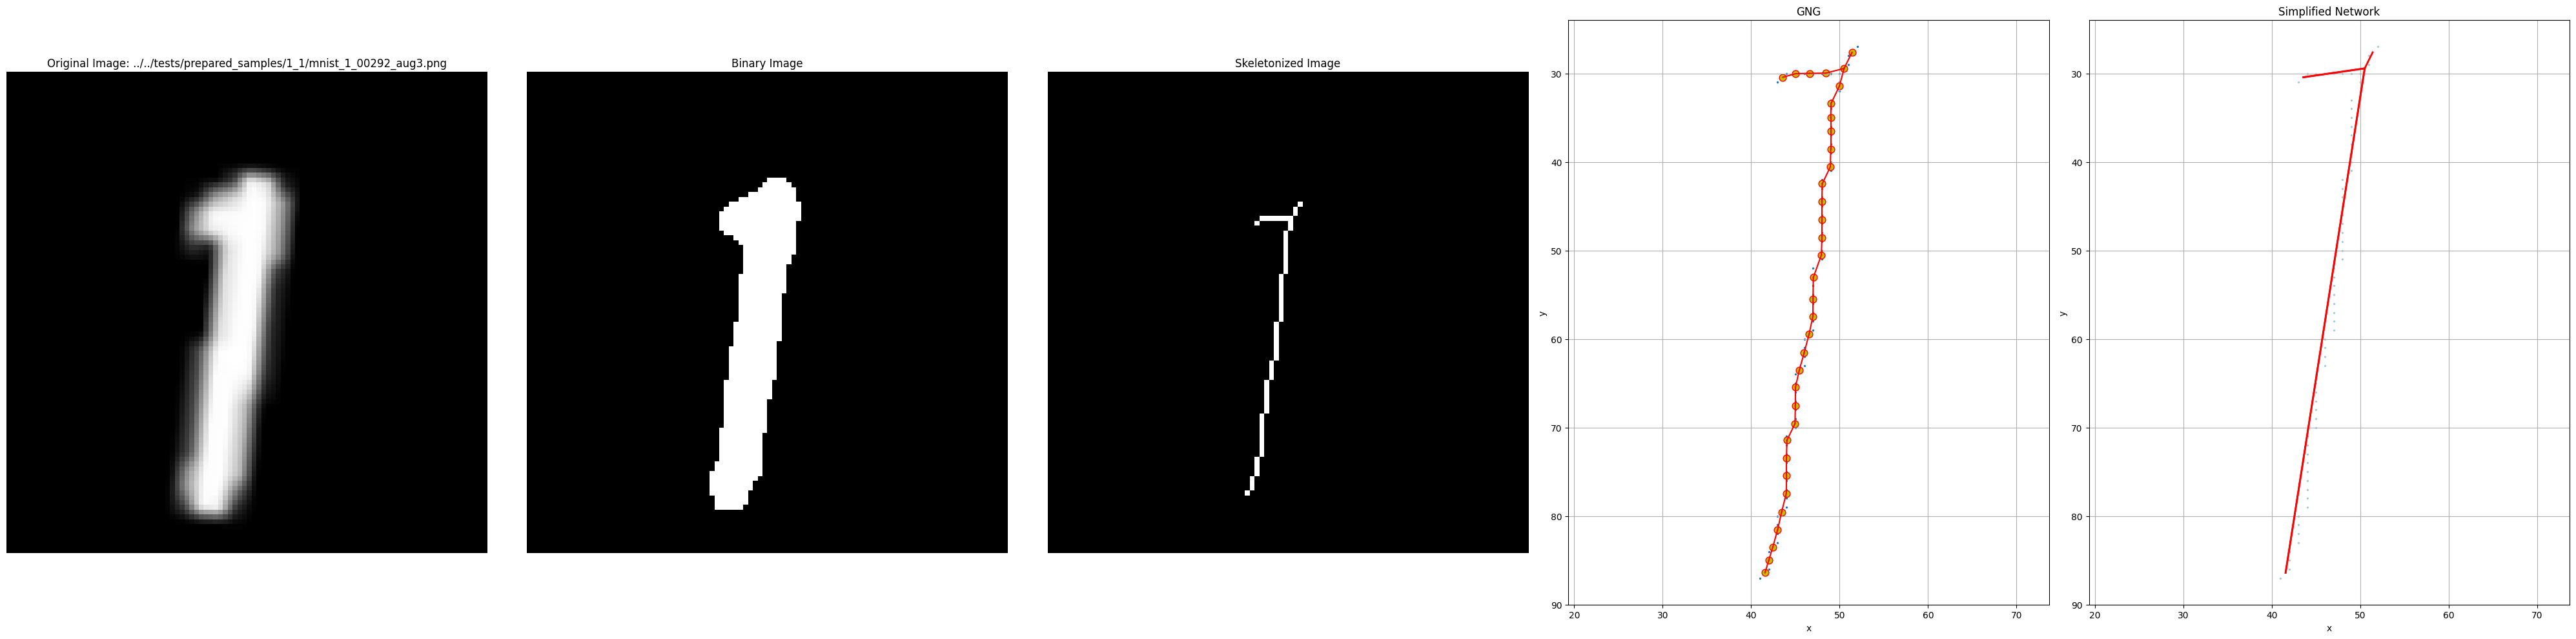

Cycles: 0
Top leftmost point: {'x': 43.580786213908354, 'y': 30.436681169728708, 'uuid': '48bab7b6-599a-4d1c-9795-903e870f1389'}
Vector 1: x1: 43.580786213908354, y1: 30.436681169728708, x2: 50.50996583410913, y2: 29.440160649550172
Vector 2: x1: 50.50996583410913, y1: 29.440160649550172, x2: 51.41225952756426, y2: 27.621909437039967
Vector 3: x1: 50.50996583410913, y1: 29.440160649550172, x2: 41.5676856509326, y2: 86.4050216275754


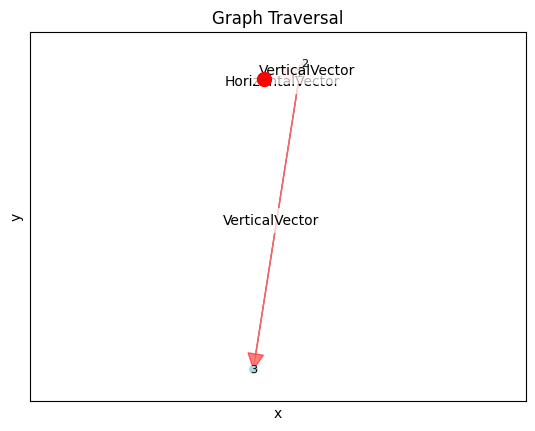

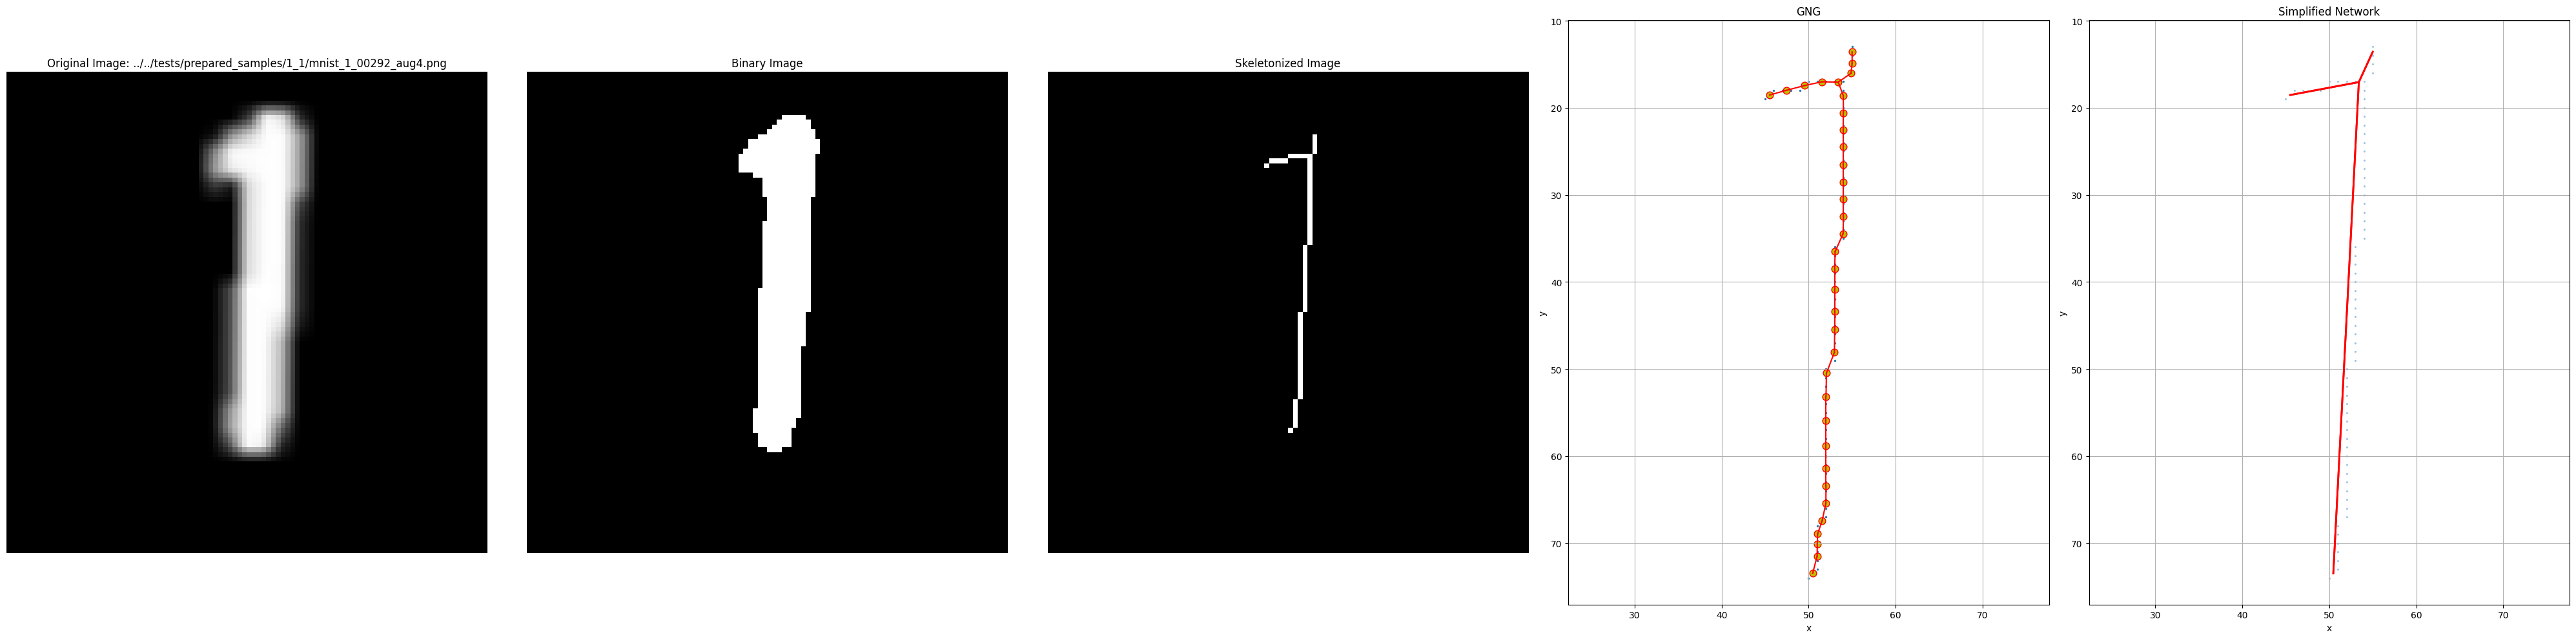

Cycles: 0
Top leftmost point: {'x': 45.514594838312696, 'y': 18.53657278261208, 'uuid': '830f229b-7e92-43c6-84e3-add2304a2242'}
Vector 1: x1: 45.514594838312696, y1: 18.53657278261208, x2: 53.40328854731096, y2: 17.05596202168687
Vector 2: x1: 53.40328854731096, y1: 17.05596202168687, x2: 50.468795155699034, y2: 73.45628502292925
Vector 3: x1: 53.40328854731096, y1: 17.05596202168687, x2: 54.999999985896295, y2: 13.580830257939043


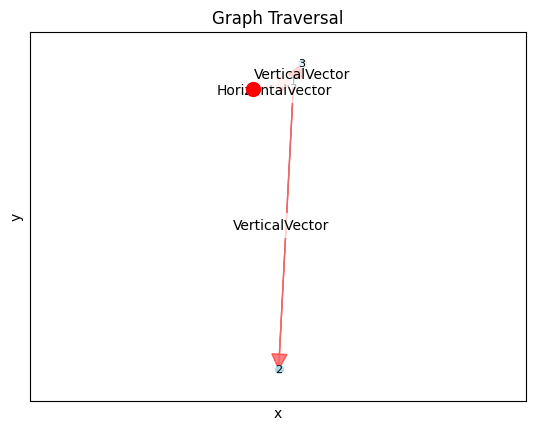

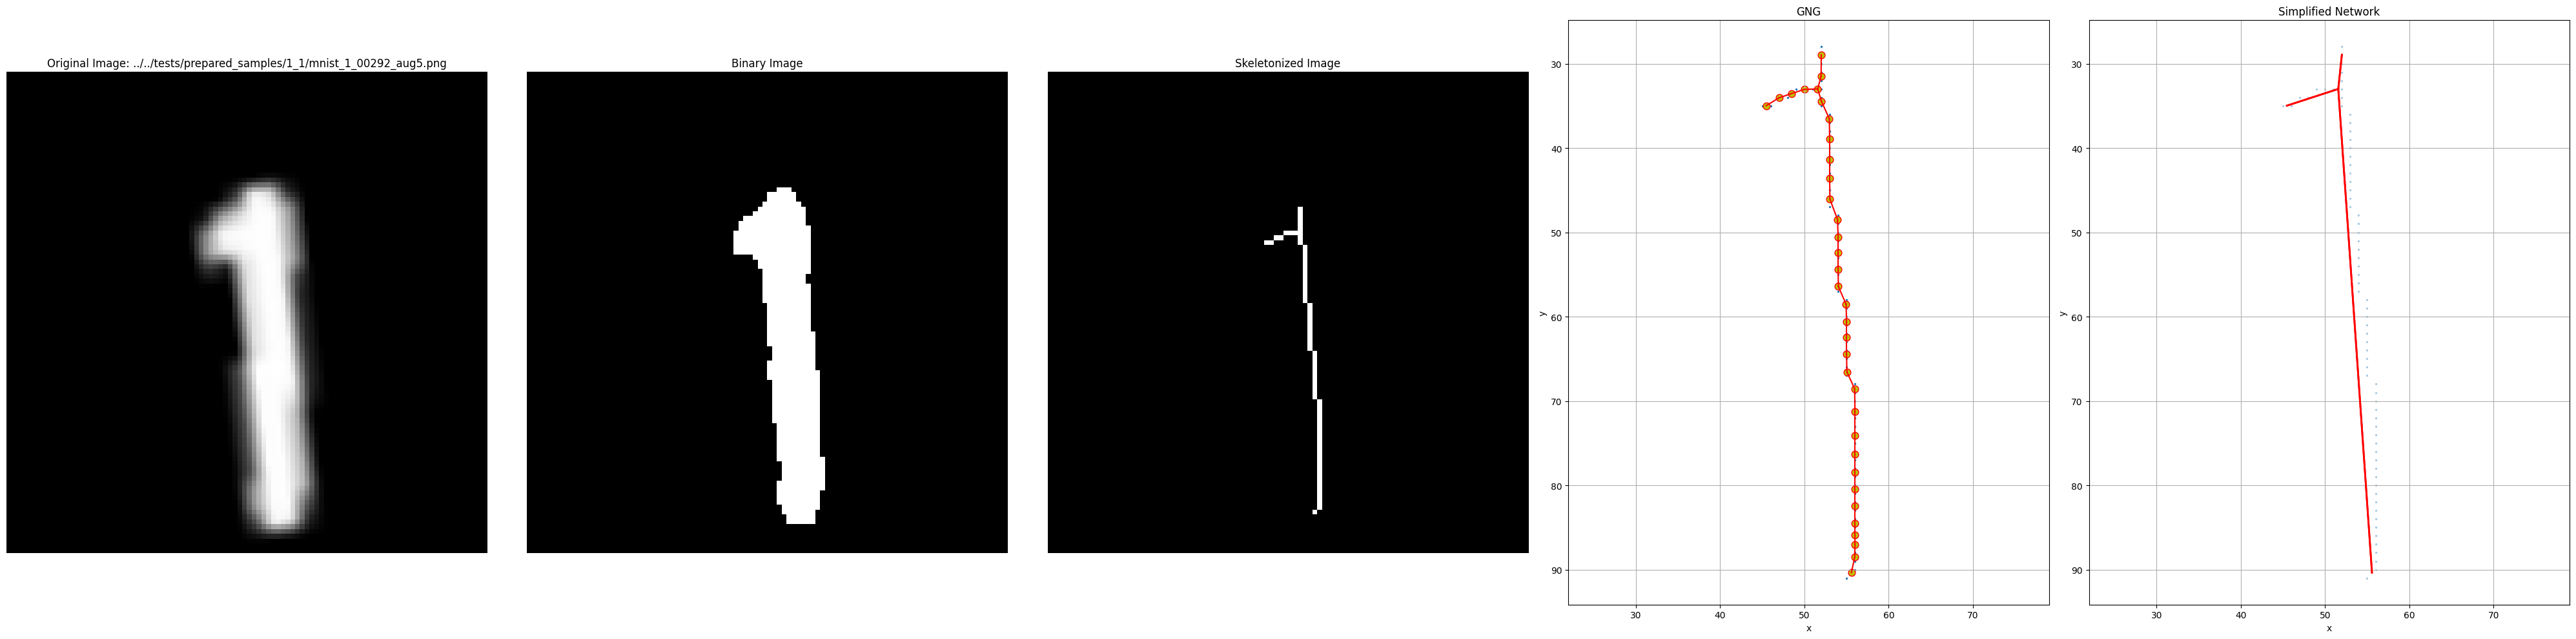

Cycles: 0
Top leftmost point: {'x': 45.47161585752673, 'y': 34.982532670191944, 'uuid': 'a40d5a89-b21a-4b68-aa38-67dd453caee2'}
Vector 1: x1: 45.47161585752673, y1: 34.982532670191944, x2: 51.57481455153019, y2: 32.99880702748682
Vector 2: x1: 51.57481455153019, y1: 32.99880702748682, x2: 55.57503868632503, y2: 90.35428264622185
Vector 3: x1: 51.57481455153019, y1: 32.99880702748682, x2: 51.99999999999997, y2: 28.946391408240665


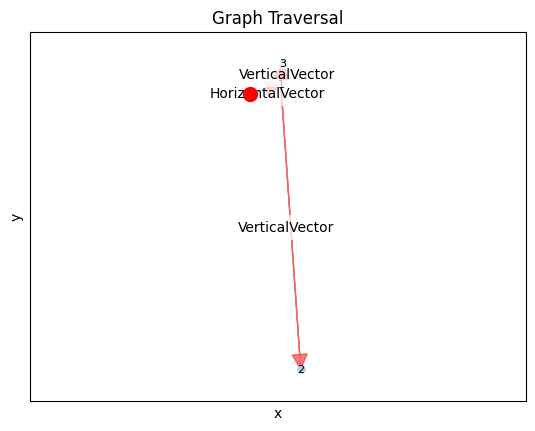

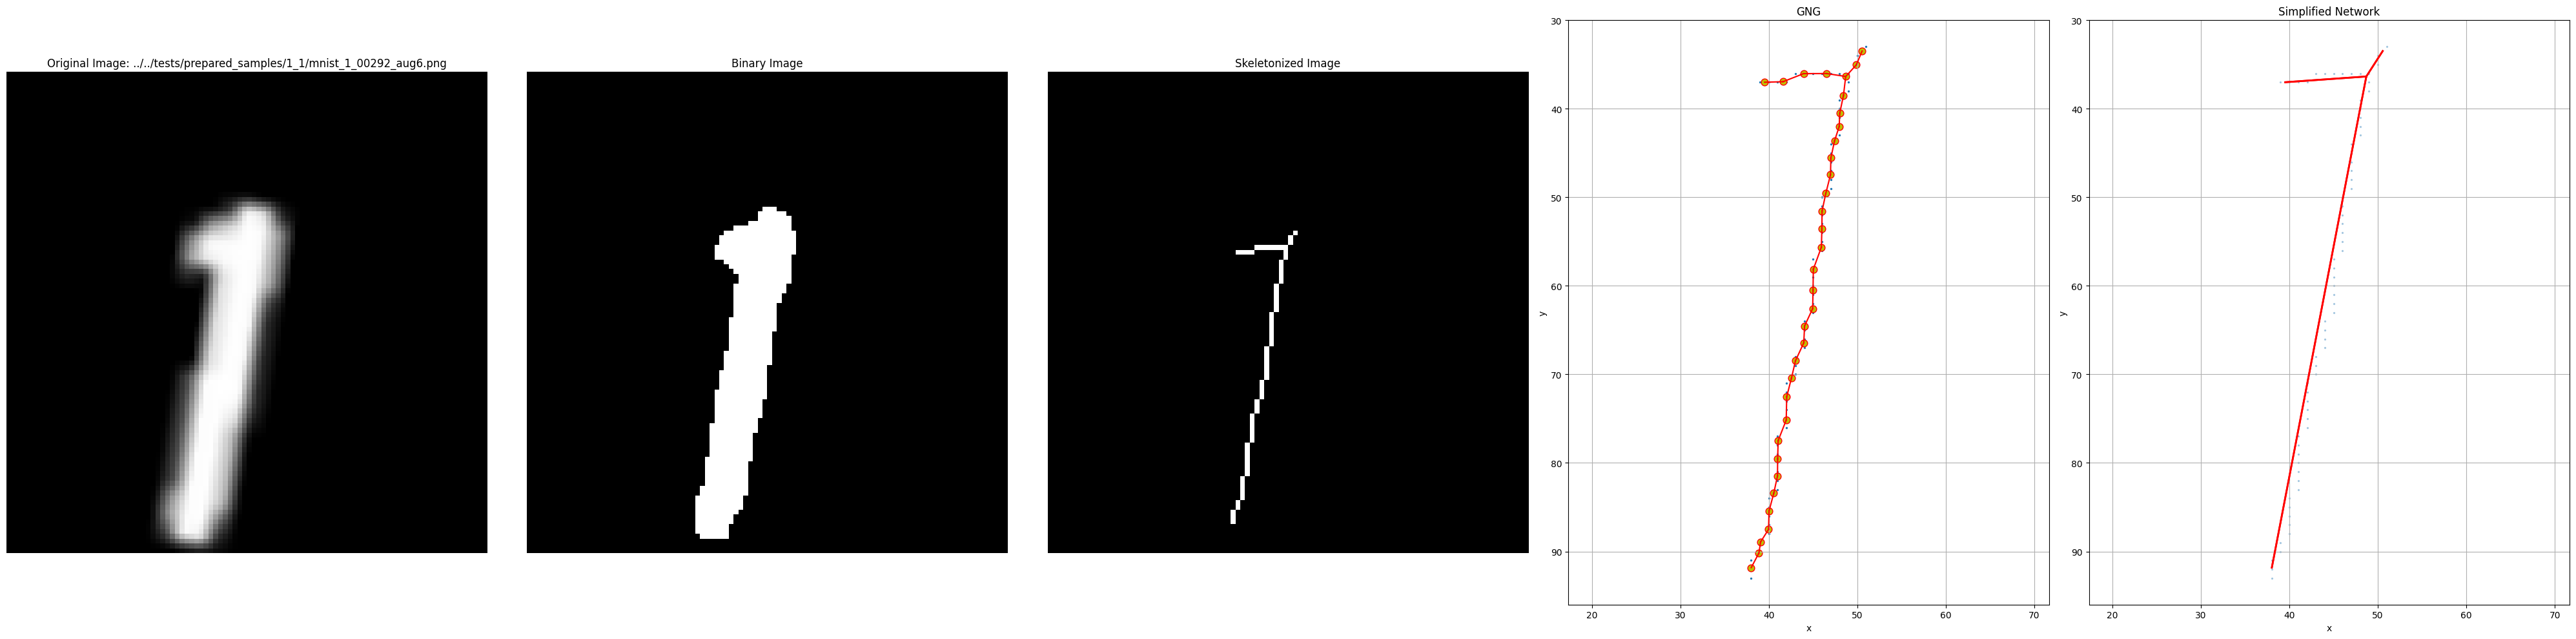

Cycles: 0
Top leftmost point: {'x': 39.527601450168554, 'y': 36.99999999960519, 'uuid': '6cc64e9f-00d6-405f-9695-fc4cd02dbc85'}
Vector 1: x1: 39.527601450168554, y1: 36.99999999960519, x2: 48.692993977539615, y2: 36.352213711499644
Vector 2: x1: 48.692993977539615, y1: 36.352213711499644, x2: 38.01297859333835, y2: 91.82543800242769
Vector 3: x1: 48.692993977539615, y1: 36.352213711499644, x2: 50.545851406853714, y2: 33.475982679796815


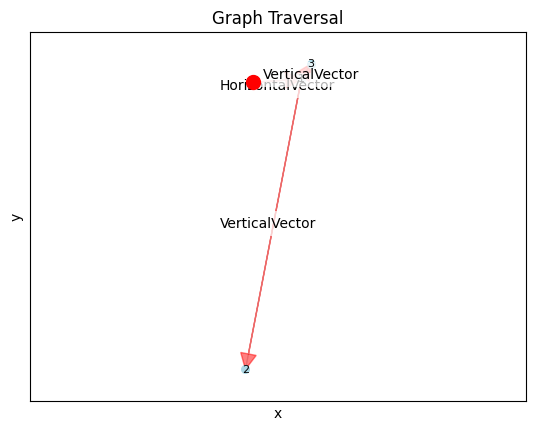

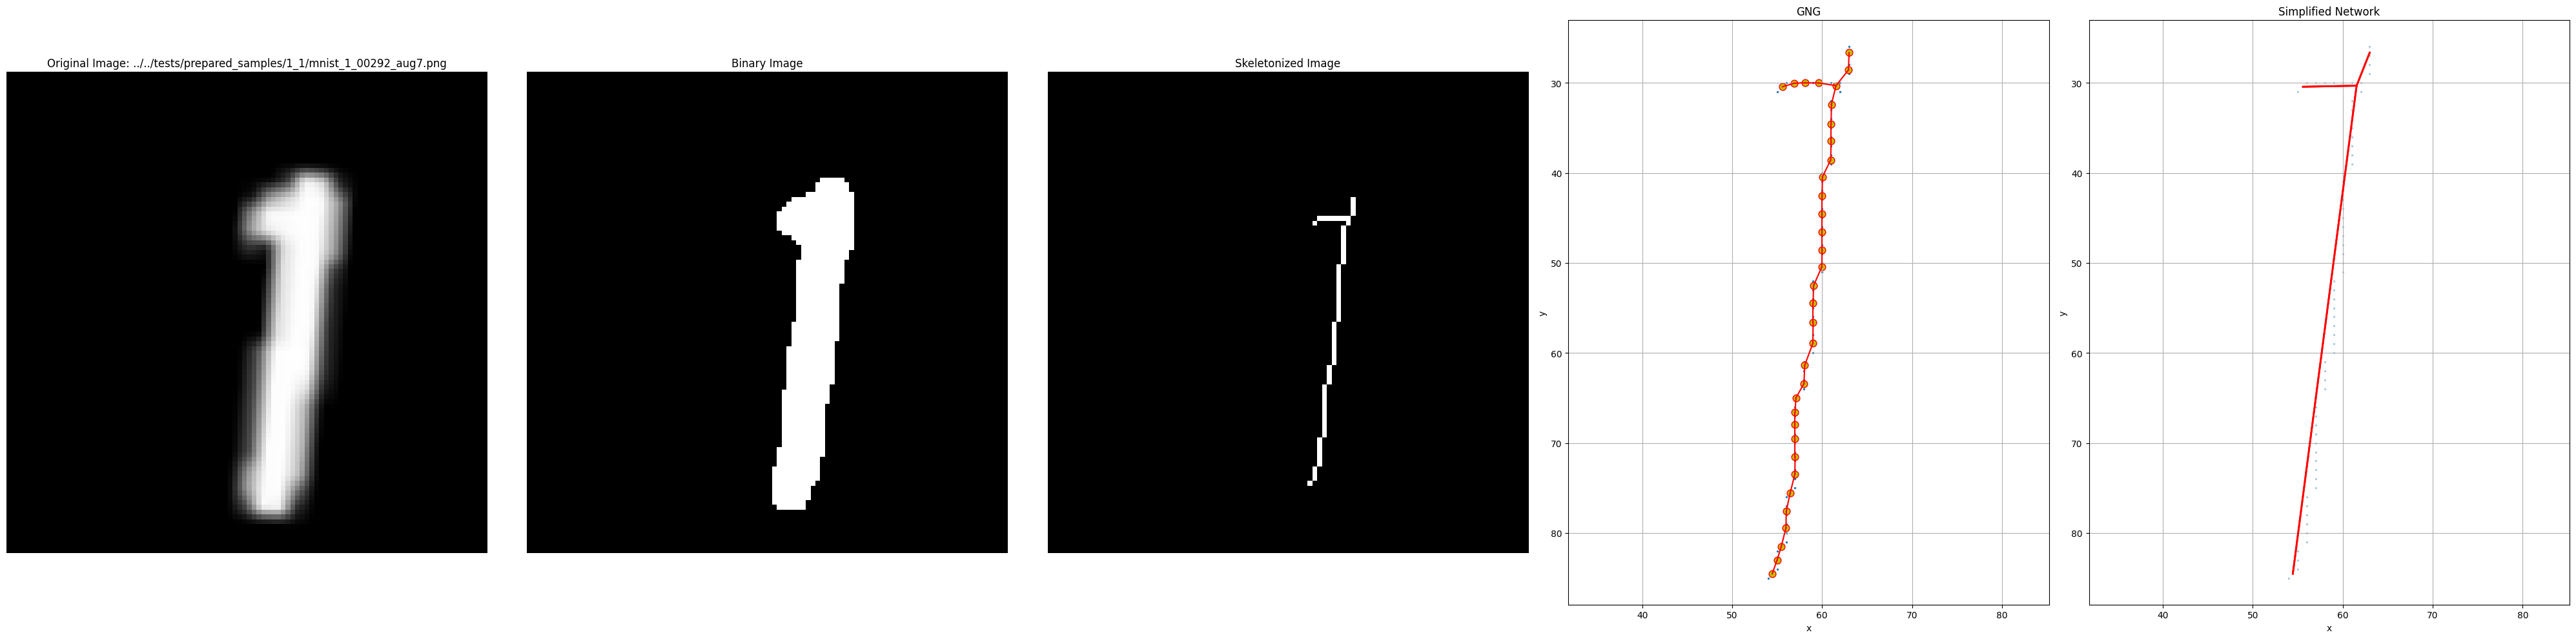

Cycles: 0
Top leftmost point: {'x': 55.58078624095373, 'y': 30.43668116440255, 'uuid': '99eb2322-98e8-4b56-9c21-81172ba91825'}
Vector 1: x1: 55.58078624095373, y1: 30.43668116440255, x2: 61.54466260113675, y2: 30.318646597024763
Vector 2: x1: 61.54466260113675, y1: 30.318646597024763, x2: 54.45414852086396, y2: 84.5283841352513
Vector 3: x1: 61.54466260113675, y1: 30.318646597024763, x2: 62.99999999656188, y2: 26.64345821990473


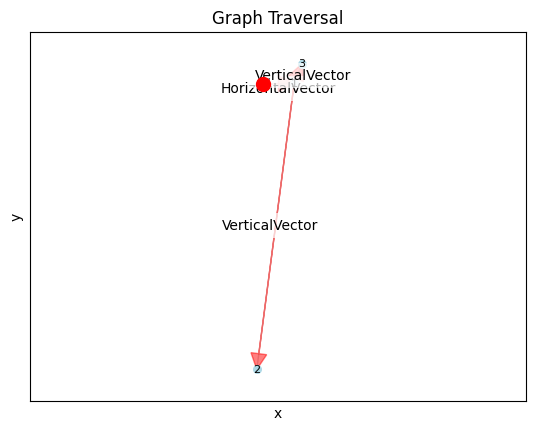

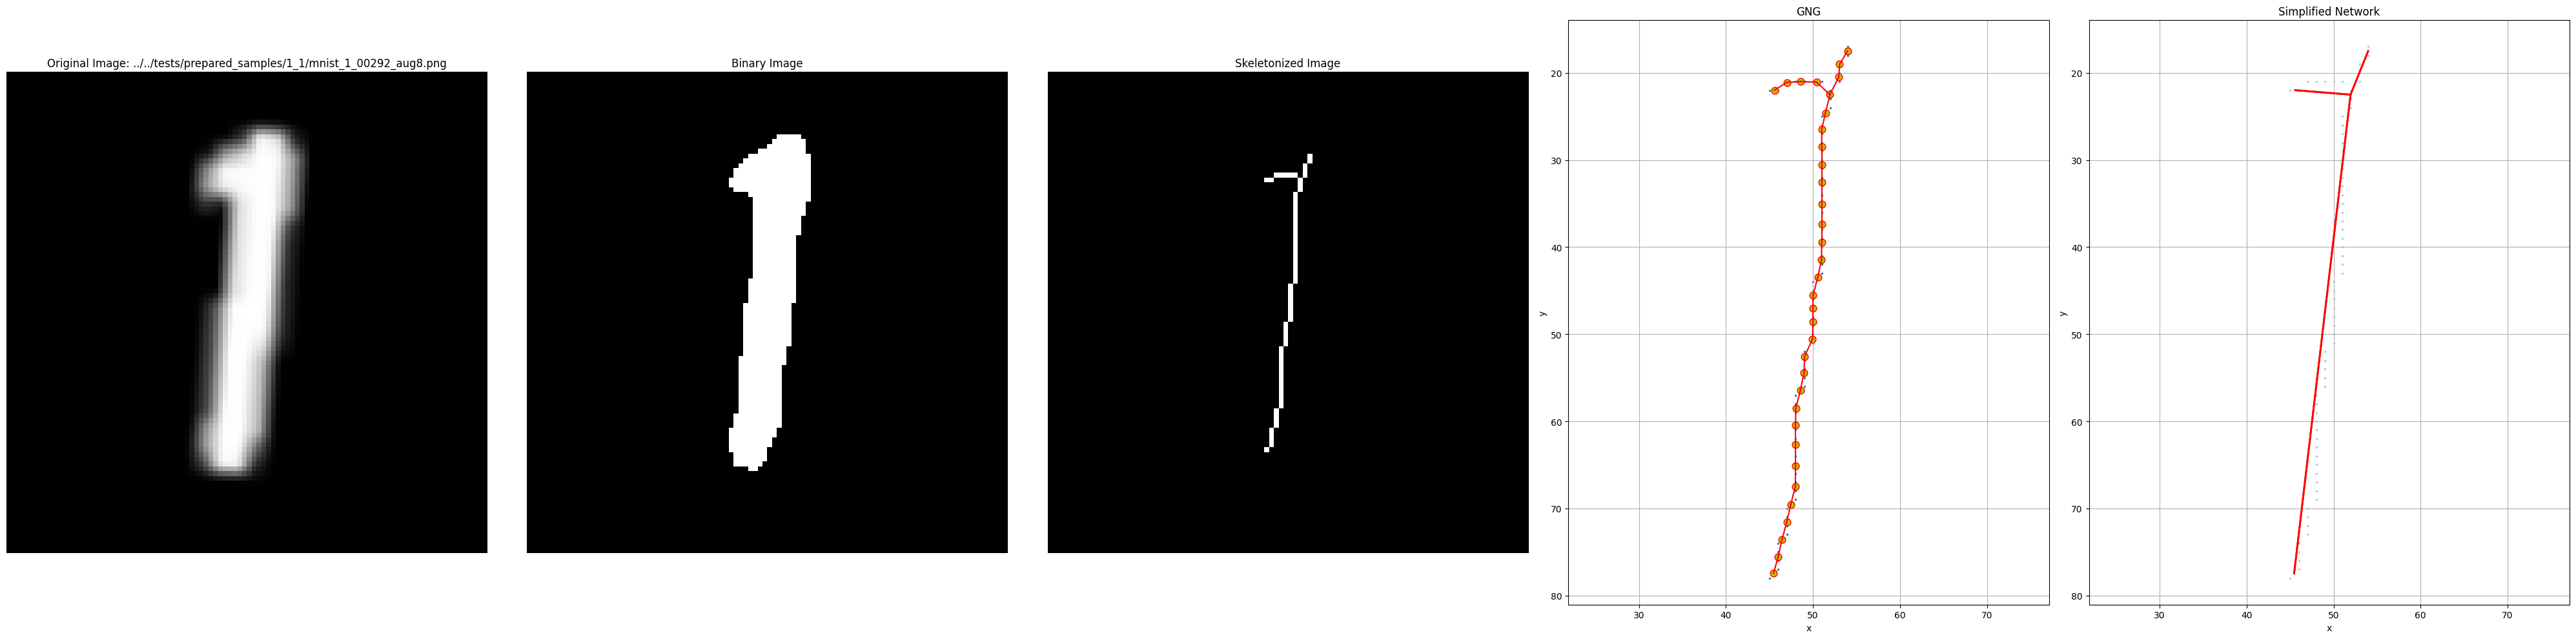

Cycles: 0
Top leftmost point: {'x': 45.58078609941537, 'y': 21.982532731607005, 'uuid': '289dd4dd-716b-43c2-a450-4a715110060a'}
Vector 1: x1: 45.58078609941537, y1: 21.982532731607005, x2: 51.95389906146124, y2: 22.493338208823147
Vector 2: x1: 51.95389906146124, y1: 22.493338208823147, x2: 45.46879294553244, y2: 77.47038112205017
Vector 3: x1: 51.95389906146124, y1: 22.493338208823147, x2: 53.972707064775534, y2: 17.486899969670397


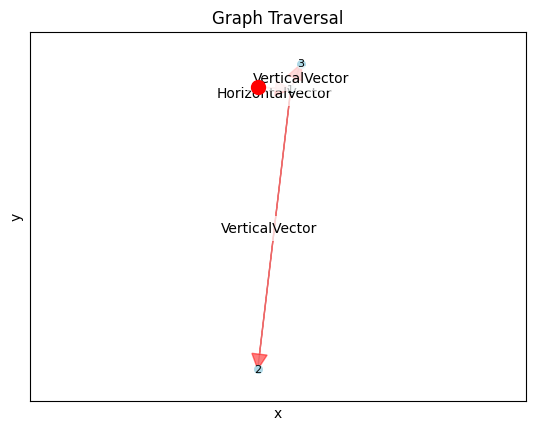

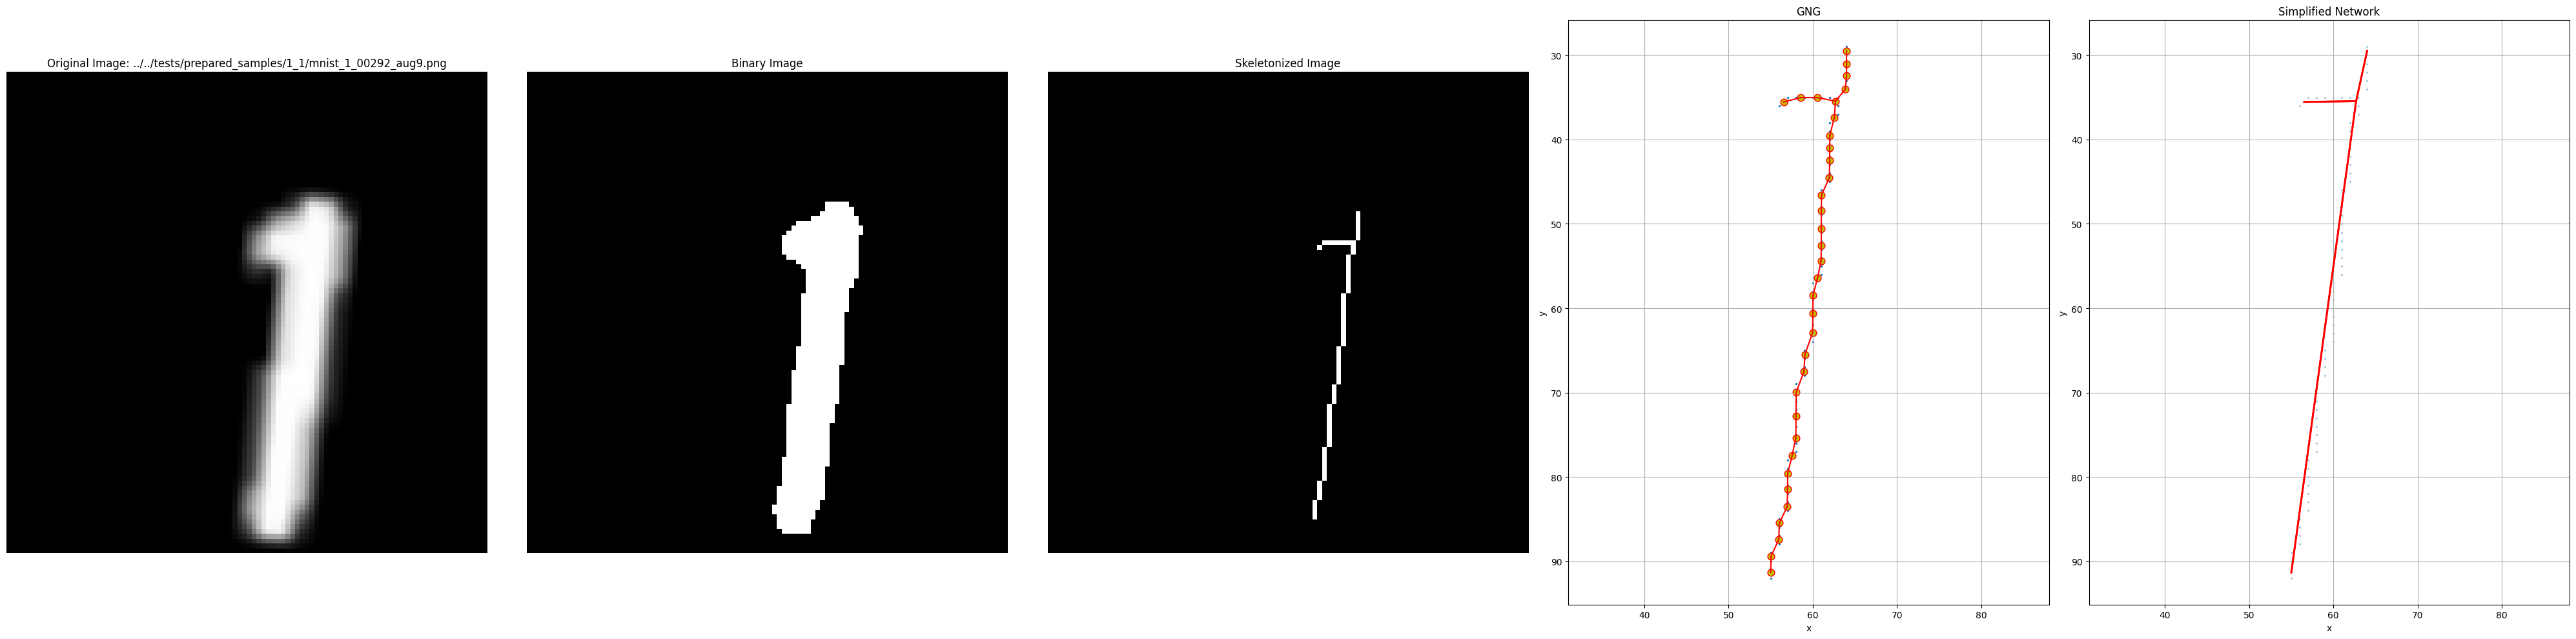

Cycles: 0
Top leftmost point: {'x': 56.52760140771428, 'y': 35.53657278063426, 'uuid': '21983da1-818d-45e1-8636-d02c52d6af3b'}
Vector 1: x1: 56.52760140771428, y1: 35.53657278063426, x2: 62.69212232852124, y2: 35.44481894632803
Vector 2: x1: 62.69212232852124, y1: 35.44481894632803, x2: 55.00000000040504, y2: 91.34049824304297
Vector 3: x1: 62.69212232852124, y1: 35.44481894632803, x2: 63.999999999106194, y2: 29.471624378215687


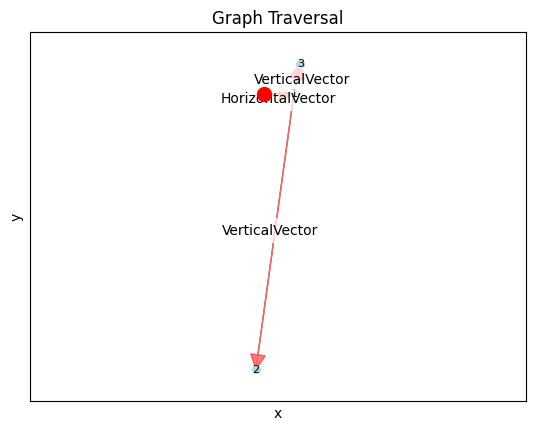

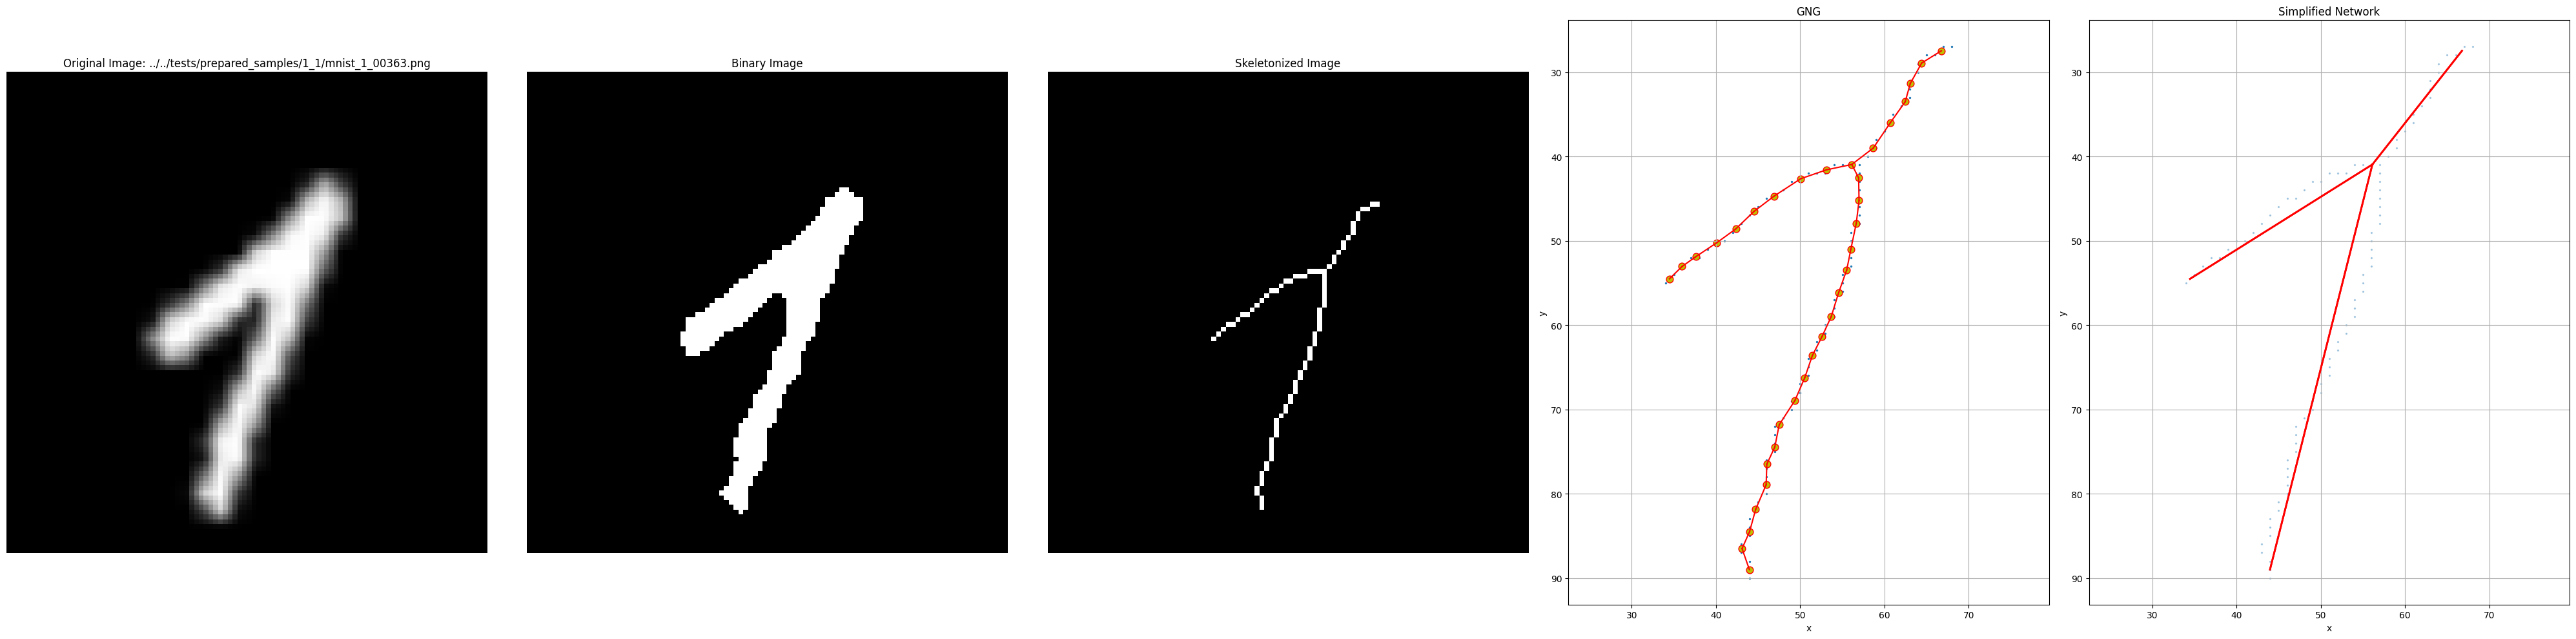

Cycles: 0
Top leftmost point: {'x': 34.47598342448681, 'y': 54.524016665502934, 'uuid': '8ca3c6f1-2c09-4fc0-8e55-a0352b770154'}
Vector 1: x1: 34.47598342448681, y1: 54.524016665502934, x2: 56.1254043230358, y2: 40.95482761506534
Vector 2: x1: 56.1254043230358, y1: 40.95482761506534, x2: 43.96975283265589, y2: 88.99892089102342
Vector 3: x1: 56.1254043230358, y1: 40.95482761506534, x2: 66.75661714281011, y2: 27.469236670580905


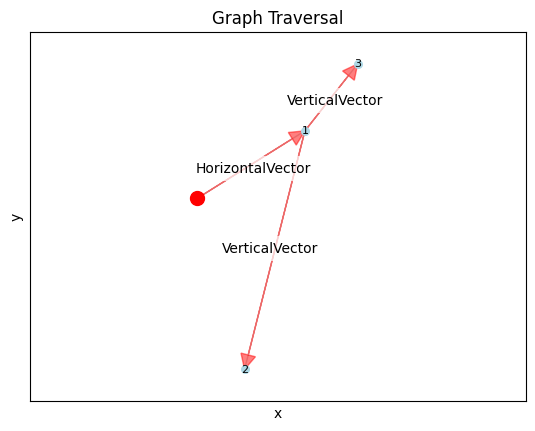

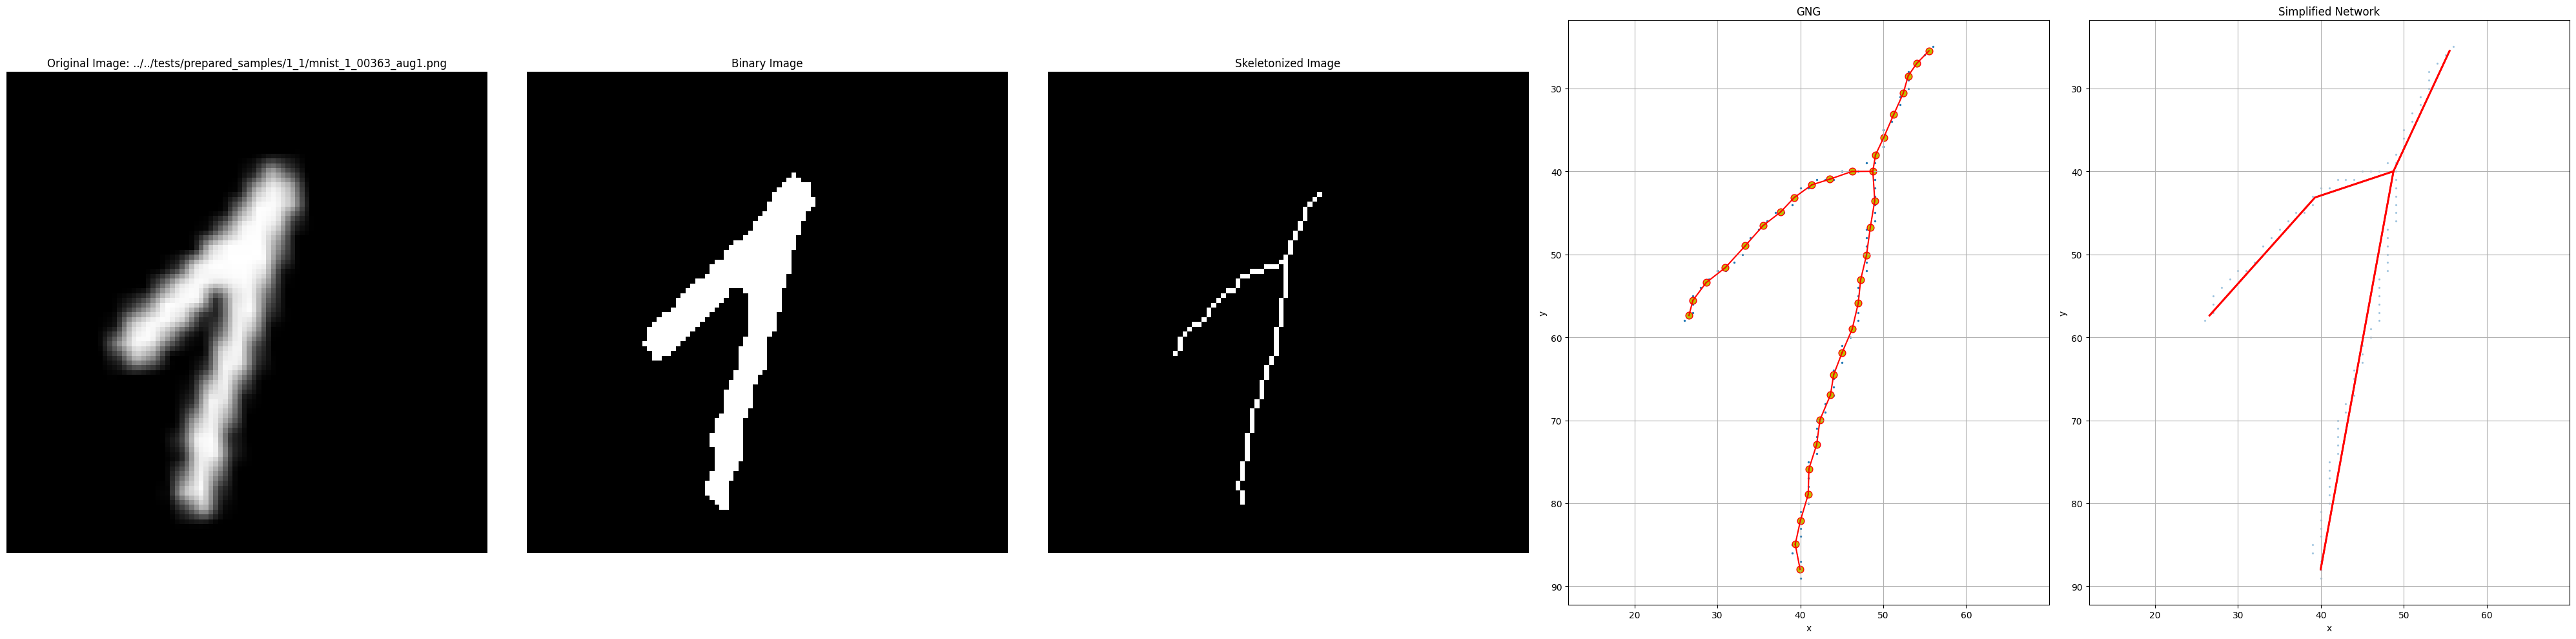

Cycles: 0
Top leftmost point: {'x': 55.51310038350443, 'y': 25.486899618972572, 'uuid': '41f31411-d36f-44d3-8cae-b681e98e1f4b'}
Vector 1: x1: 55.51310038350443, y1: 25.486899618972572, x2: 48.74478064124649, y2: 39.99936214359912
Vector 2: x1: 48.74478064124649, y1: 39.99936214359912, x2: 39.971636637614026, y2: 87.9502366136011
Vector 3: x1: 48.74478064124649, y1: 39.99936214359912, x2: 39.28143538407097, y2: 43.152684177515674
Vector 4: x1: 39.28143538407097, y1: 43.152684177515674, x2: 26.575034357376747, y2: 57.36413970815742


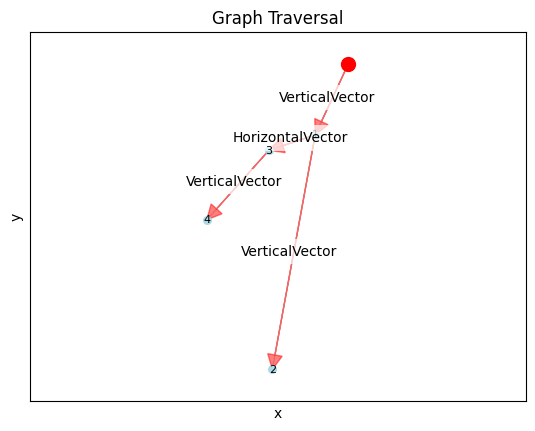

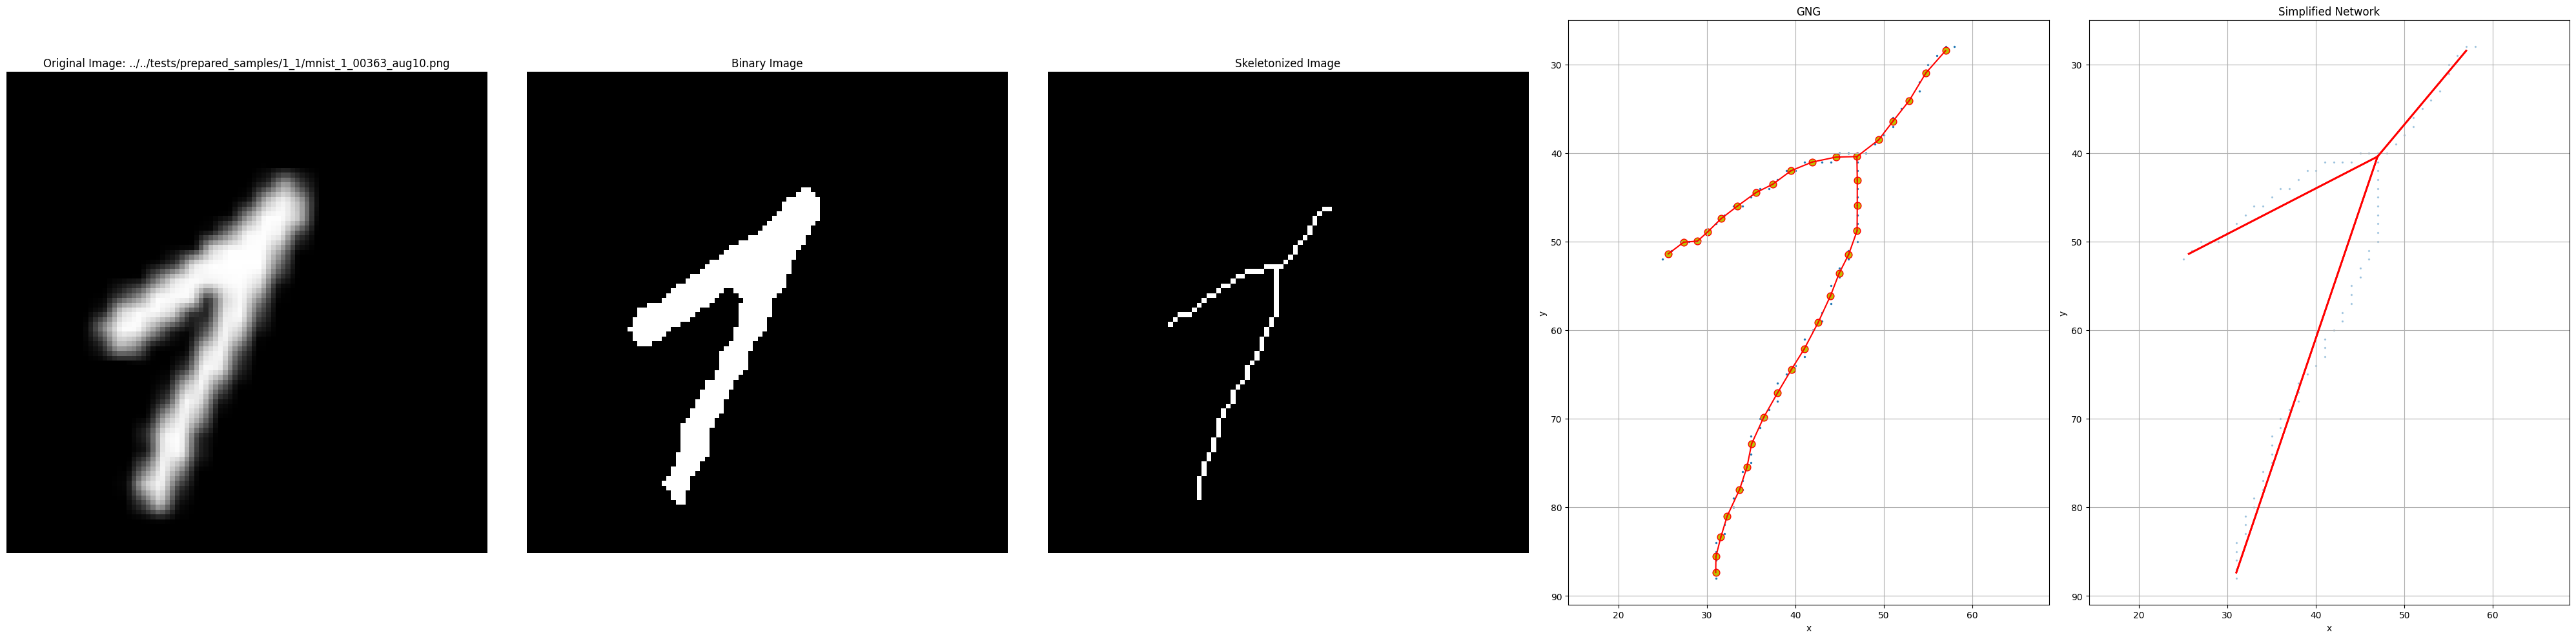

Cycles: 0
Top leftmost point: {'x': 25.630520960355376, 'y': 51.38648961063505, 'uuid': 'e3a15038-9648-4173-9d8d-299613ec7c7e'}
Vector 1: x1: 25.630520960355376, y1: 51.38648961063505, x2: 46.960637978722445, y2: 40.401708959705175
Vector 2: x1: 46.960637978722445, y1: 40.401708959705175, x2: 56.983850905447, y2: 28.439470211415063
Vector 3: x1: 46.960637978722445, y1: 40.401708959705175, x2: 31.000000012147744, y2: 87.37808931864588


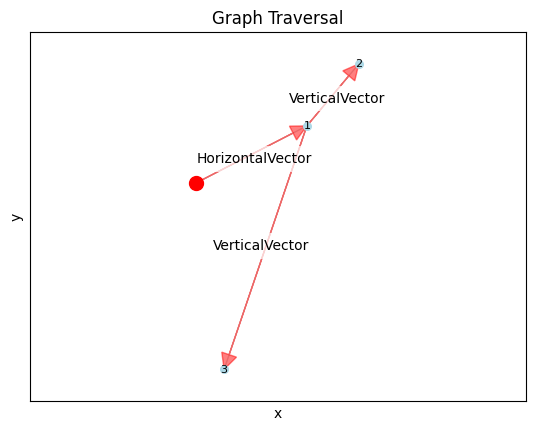

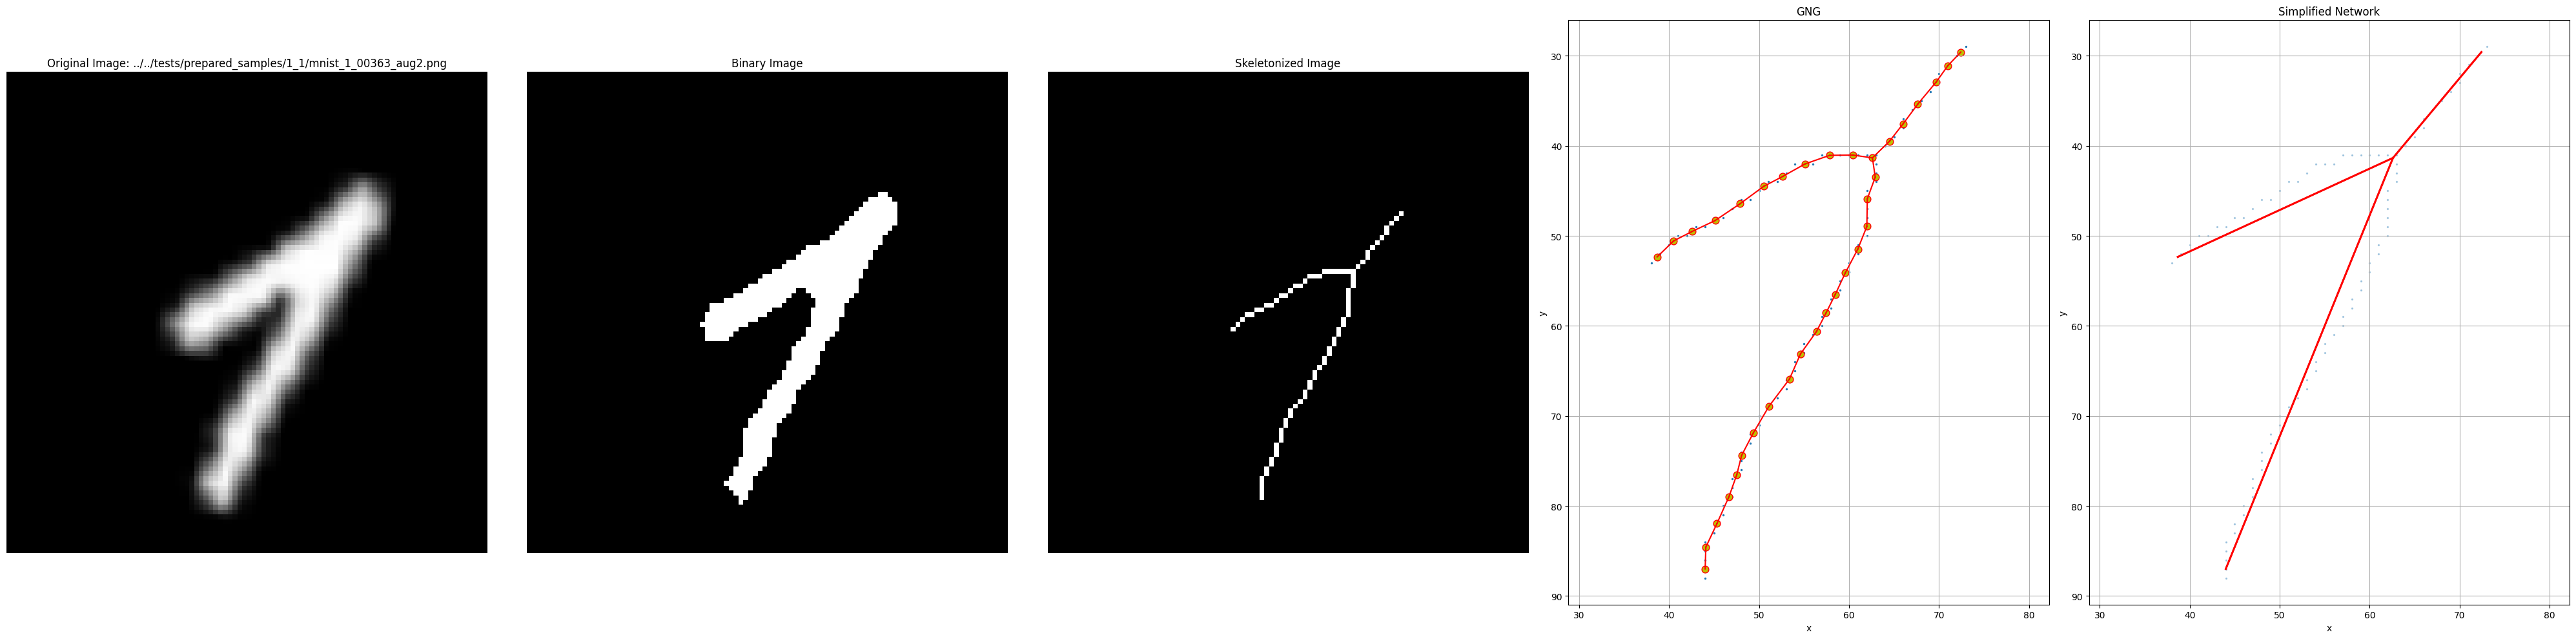

Cycles: 0
Top leftmost point: {'x': 38.65923337787877, 'y': 52.340766623793954, 'uuid': '8ea65367-615f-4860-bcfa-8bf7780663c1'}
Vector 1: x1: 38.65923337787877, y1: 52.340766623793954, x2: 62.59266261330298, y2: 41.33522269381764
Vector 2: x1: 62.59266261330298, y1: 41.33522269381764, x2: 44.000000000000206, y2: 86.99292155905215
Vector 3: x1: 62.59266261330298, y1: 41.33522269381764, x2: 72.41916606859492, y2: 29.58083638449245


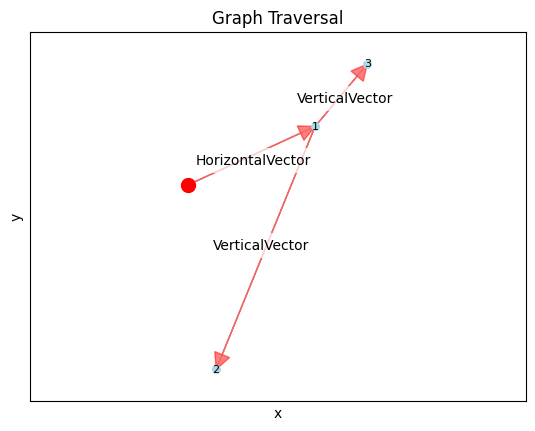

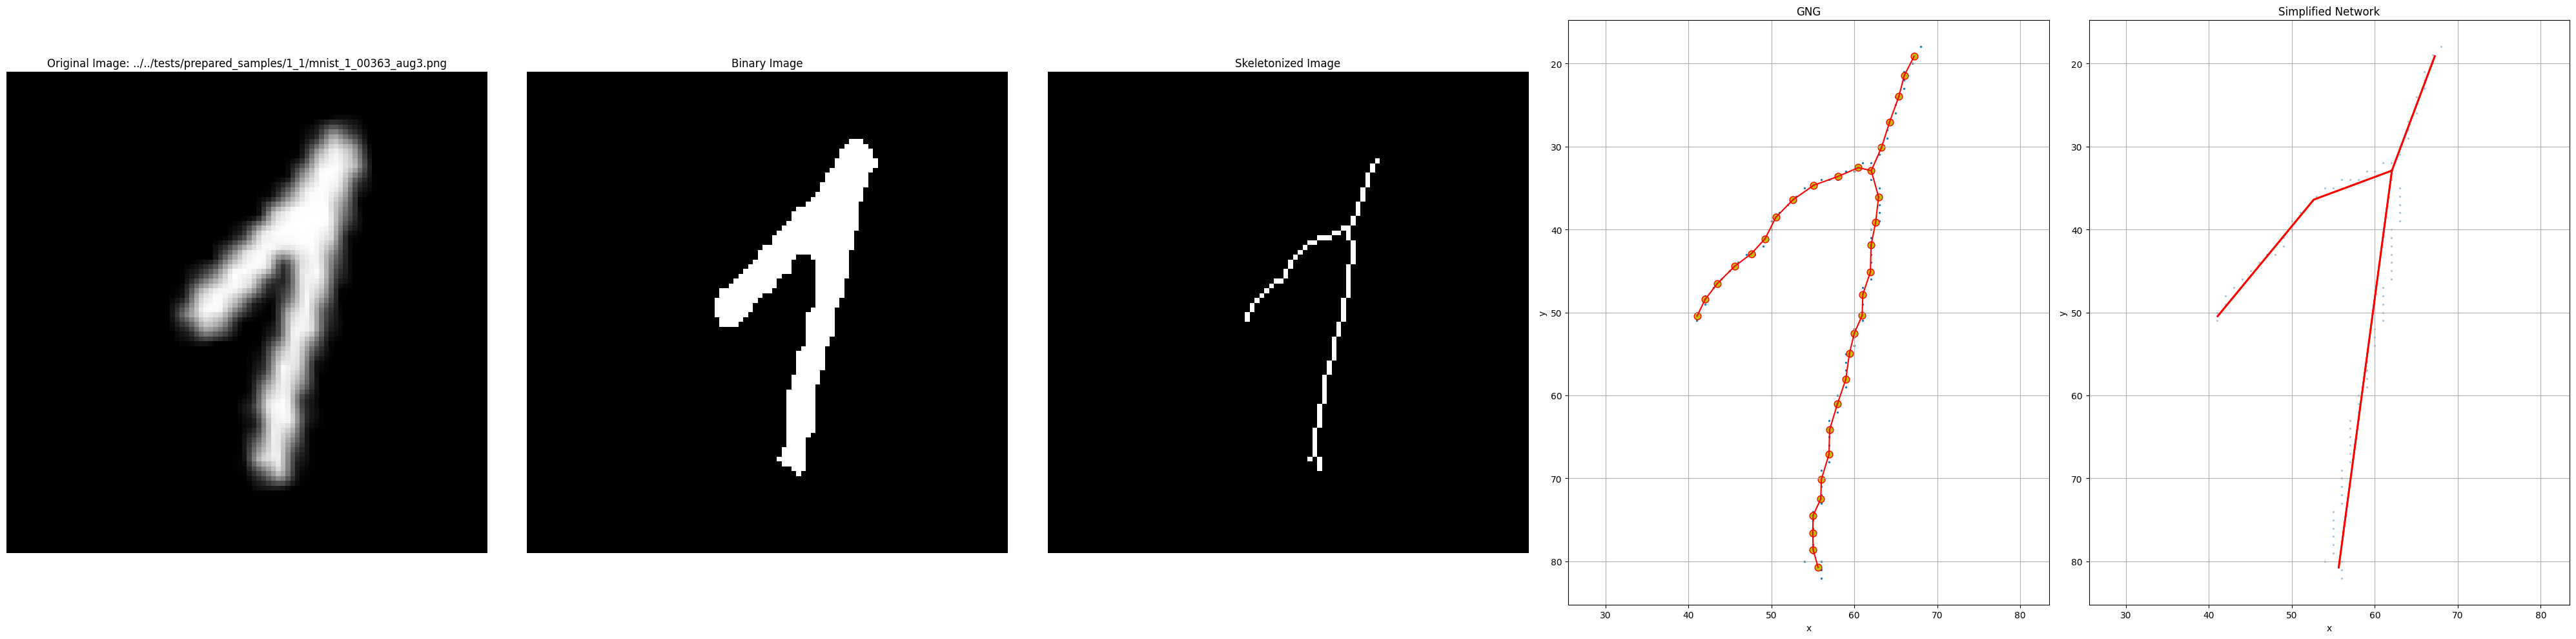

Cycles: 0
Top leftmost point: {'x': 67.22411423138992, 'y': 19.13425914031305, 'uuid': 'e7783300-31e5-4c86-aab2-9305d6f9dbb4'}
Vector 1: x1: 67.22411423138992, y1: 19.13425914031305, x2: 62.05521803913133, y2: 32.91767728125939
Vector 2: x1: 62.05521803913133, y1: 32.91767728125939, x2: 55.64422242086489, y2: 80.72801303628174
Vector 3: x1: 62.05521803913133, y1: 32.91767728125939, x2: 52.635236096499234, y2: 36.41055220297905
Vector 4: x1: 52.635236096499234, y1: 36.41055220297905, x2: 41.043827307064745, y2: 50.460551094755274


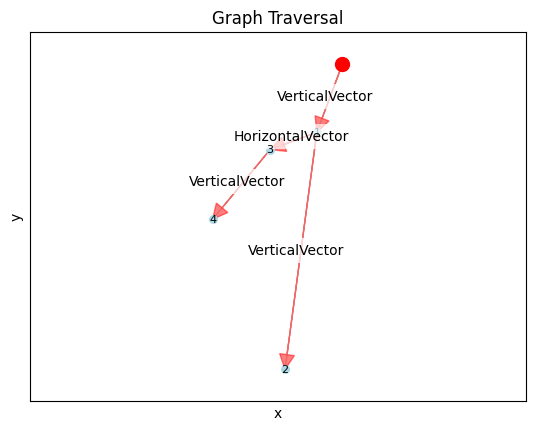

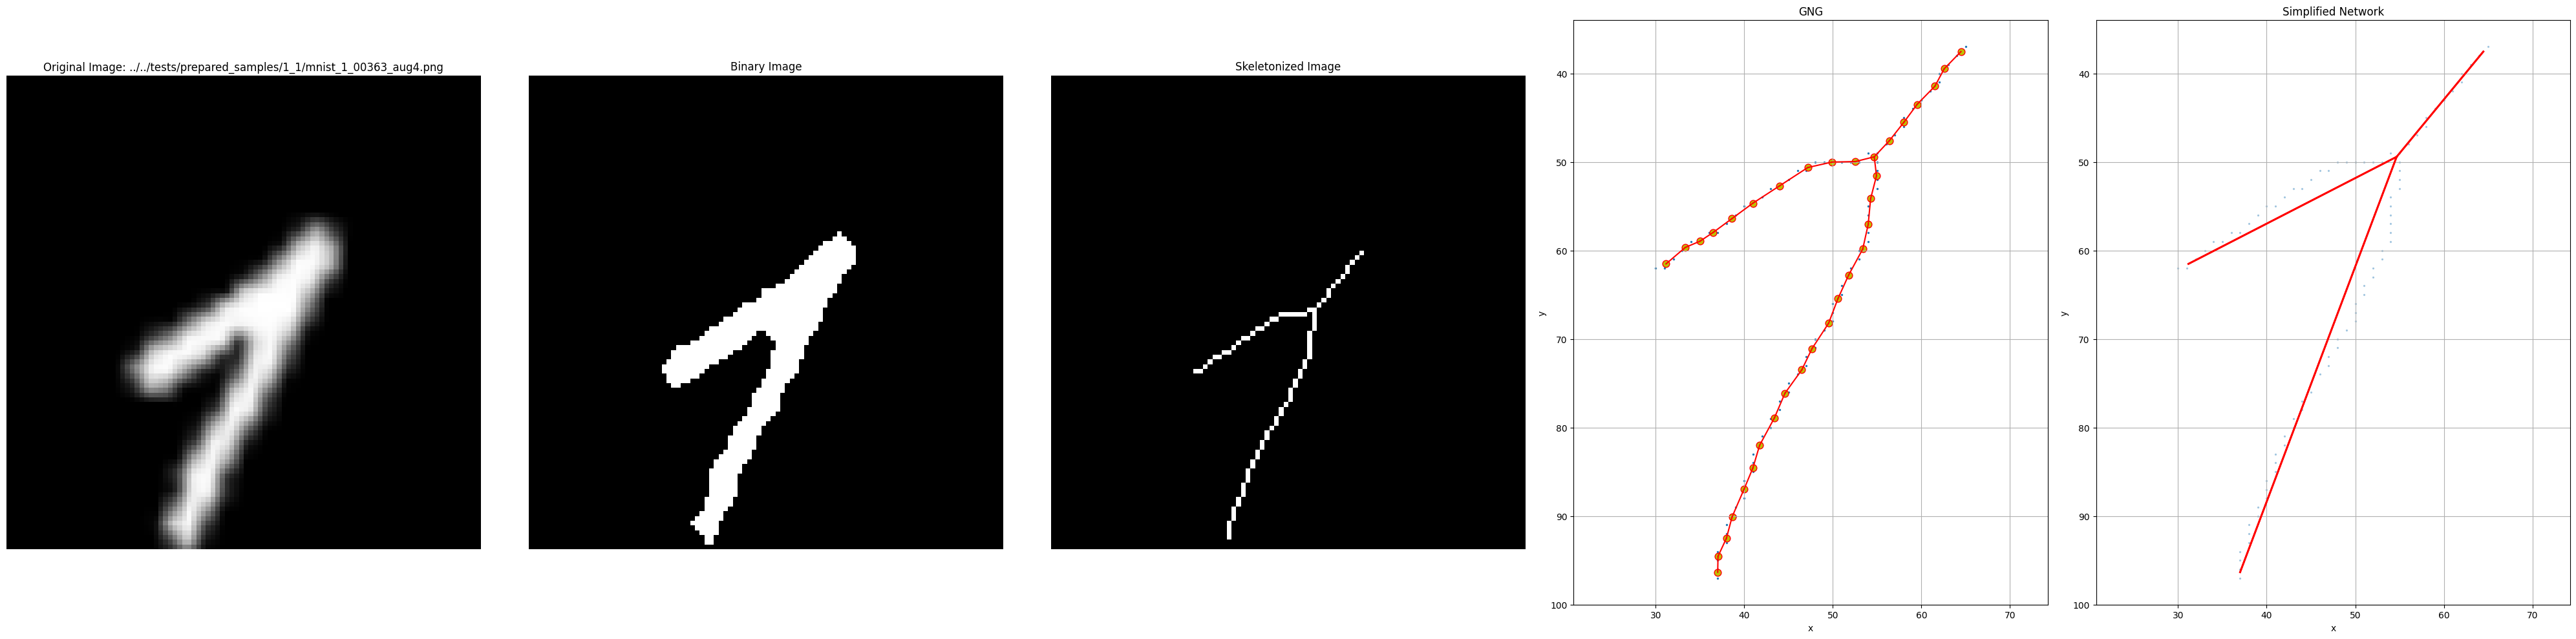

Cycles: 0
Top leftmost point: {'x': 31.166491099839146, 'y': 61.51873667008455, 'uuid': '44de63c9-9cb4-4a2d-ad62-21533ccfa75b'}
Vector 1: x1: 31.166491099839146, y1: 61.51873667008455, x2: 54.672135020528714, y2: 49.424819891682475
Vector 2: x1: 54.672135020528714, y1: 49.424819891682475, x2: 64.46188181242367, y2: 37.53811819117694
Vector 3: x1: 54.672135020528714, y1: 49.424819891682475, x2: 37.00000000119497, y2: 96.3407664567093


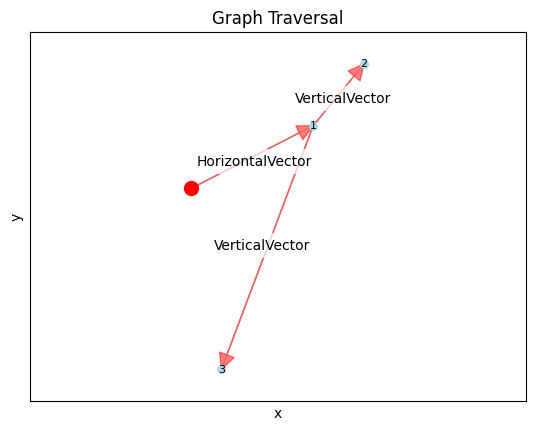

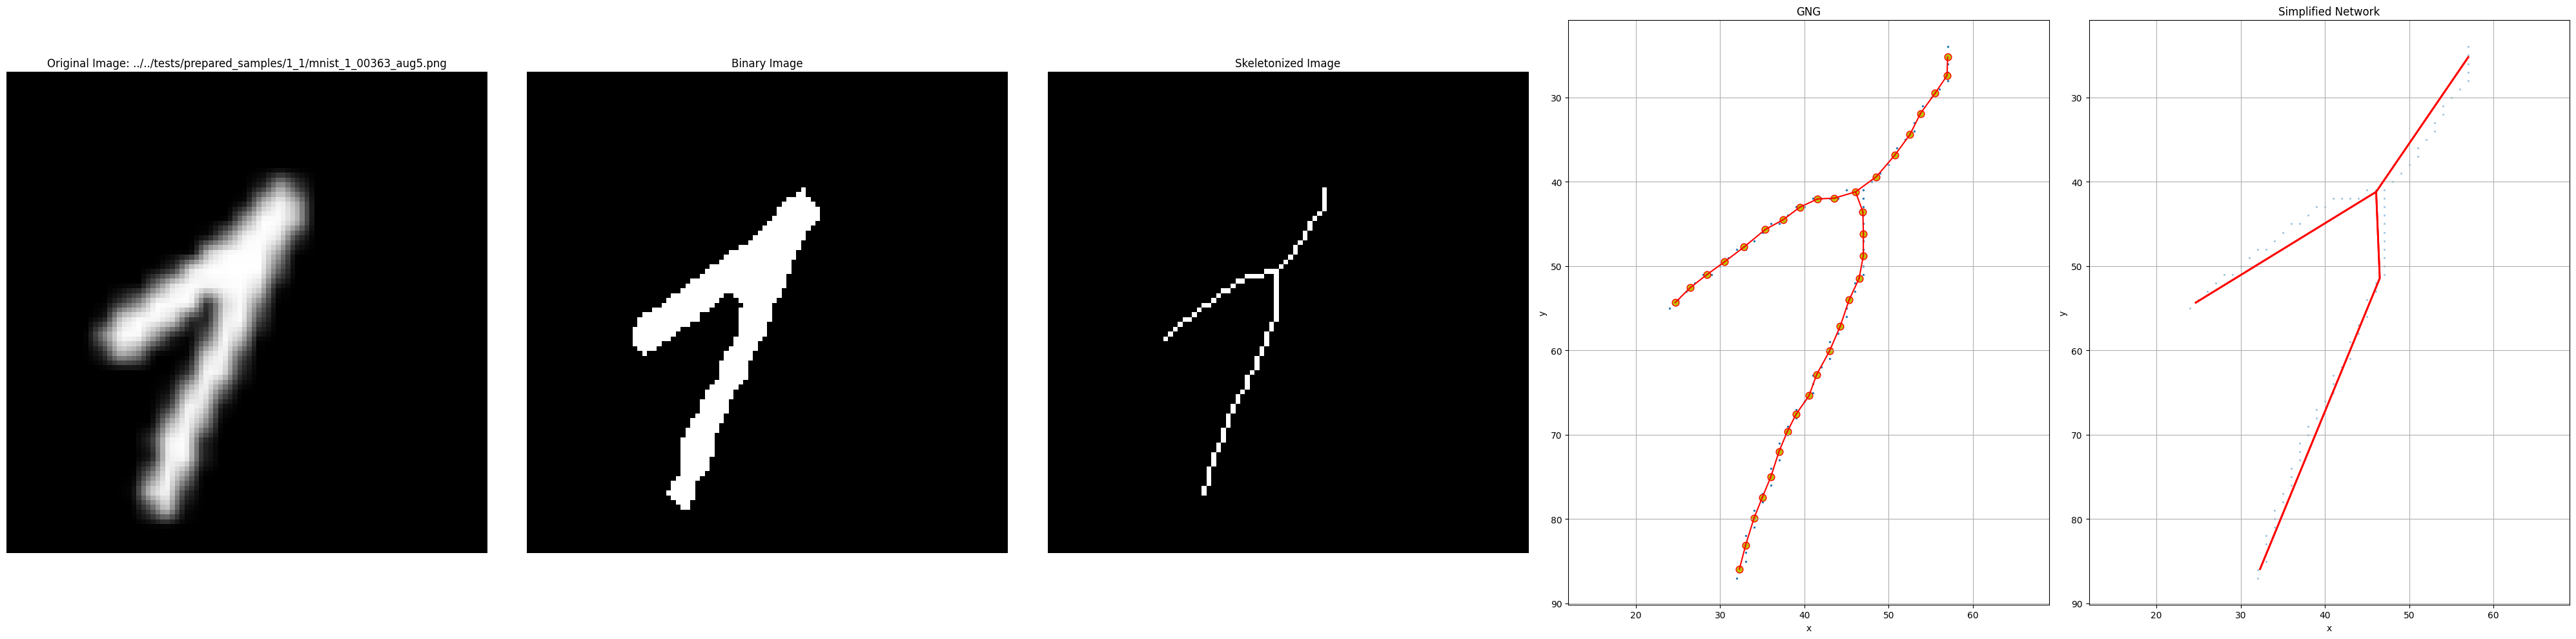

Cycles: 0
Top leftmost point: {'x': 24.659233928010682, 'y': 54.34076609919362, 'uuid': '5b406499-7b4d-44cd-9068-437c930ed623'}
Vector 1: x1: 24.659233928010682, y1: 54.34076609919362, x2: 46.06886298386785, y2: 41.2019822196251
Vector 2: x1: 46.06886298386785, y1: 41.2019822196251, x2: 56.99999999999858, y2: 25.229445543557368
Vector 3: x1: 46.06886298386785, y1: 41.2019822196251, x2: 46.500145391692854, y2: 51.4463331462114
Vector 4: x1: 46.500145391692854, y1: 51.4463331462114, x2: 32.29091594035989, y2: 85.93594517239009


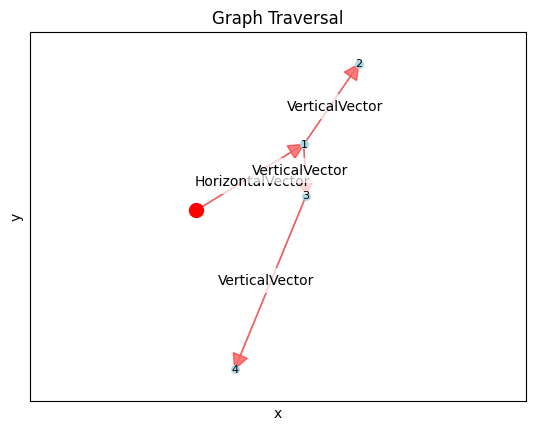

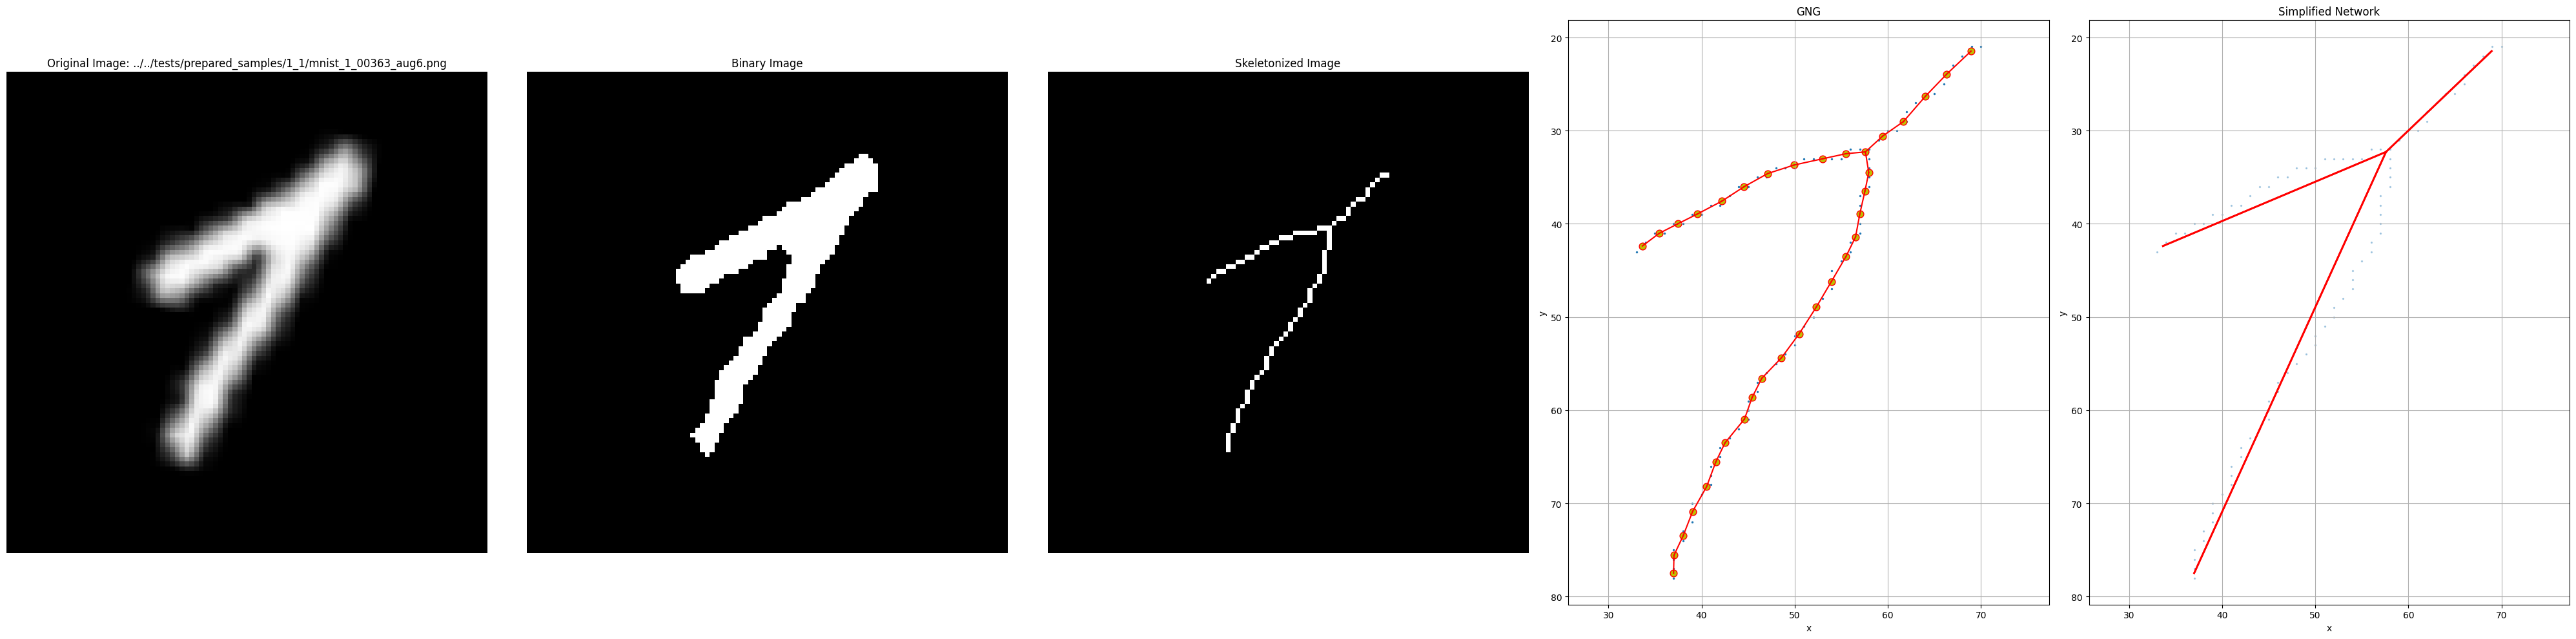

Cycles: 0
Top leftmost point: {'x': 33.643250840934, 'y': 42.37799781667218, 'uuid': 'cd85bd21-947c-4e67-9de1-e9e1a287f988'}
Vector 1: x1: 33.643250840934, y1: 42.37799781667218, x2: 57.60029927853641, y2: 32.275141019867625
Vector 2: x1: 57.60029927853641, y1: 32.275141019867625, x2: 37.00000000127745, y2: 77.47261294738777
Vector 3: x1: 57.60029927853641, y1: 32.275141019867625, x2: 68.9415470668244, y2: 21.460459811809084


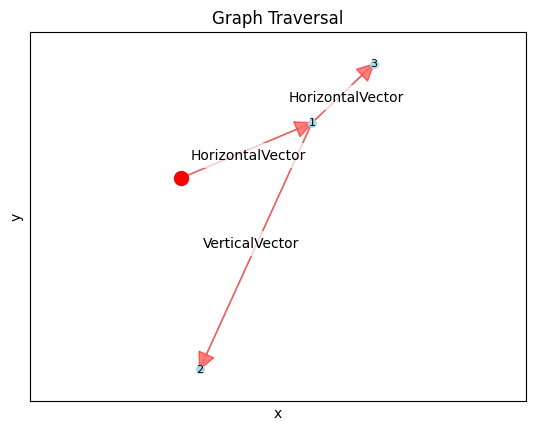

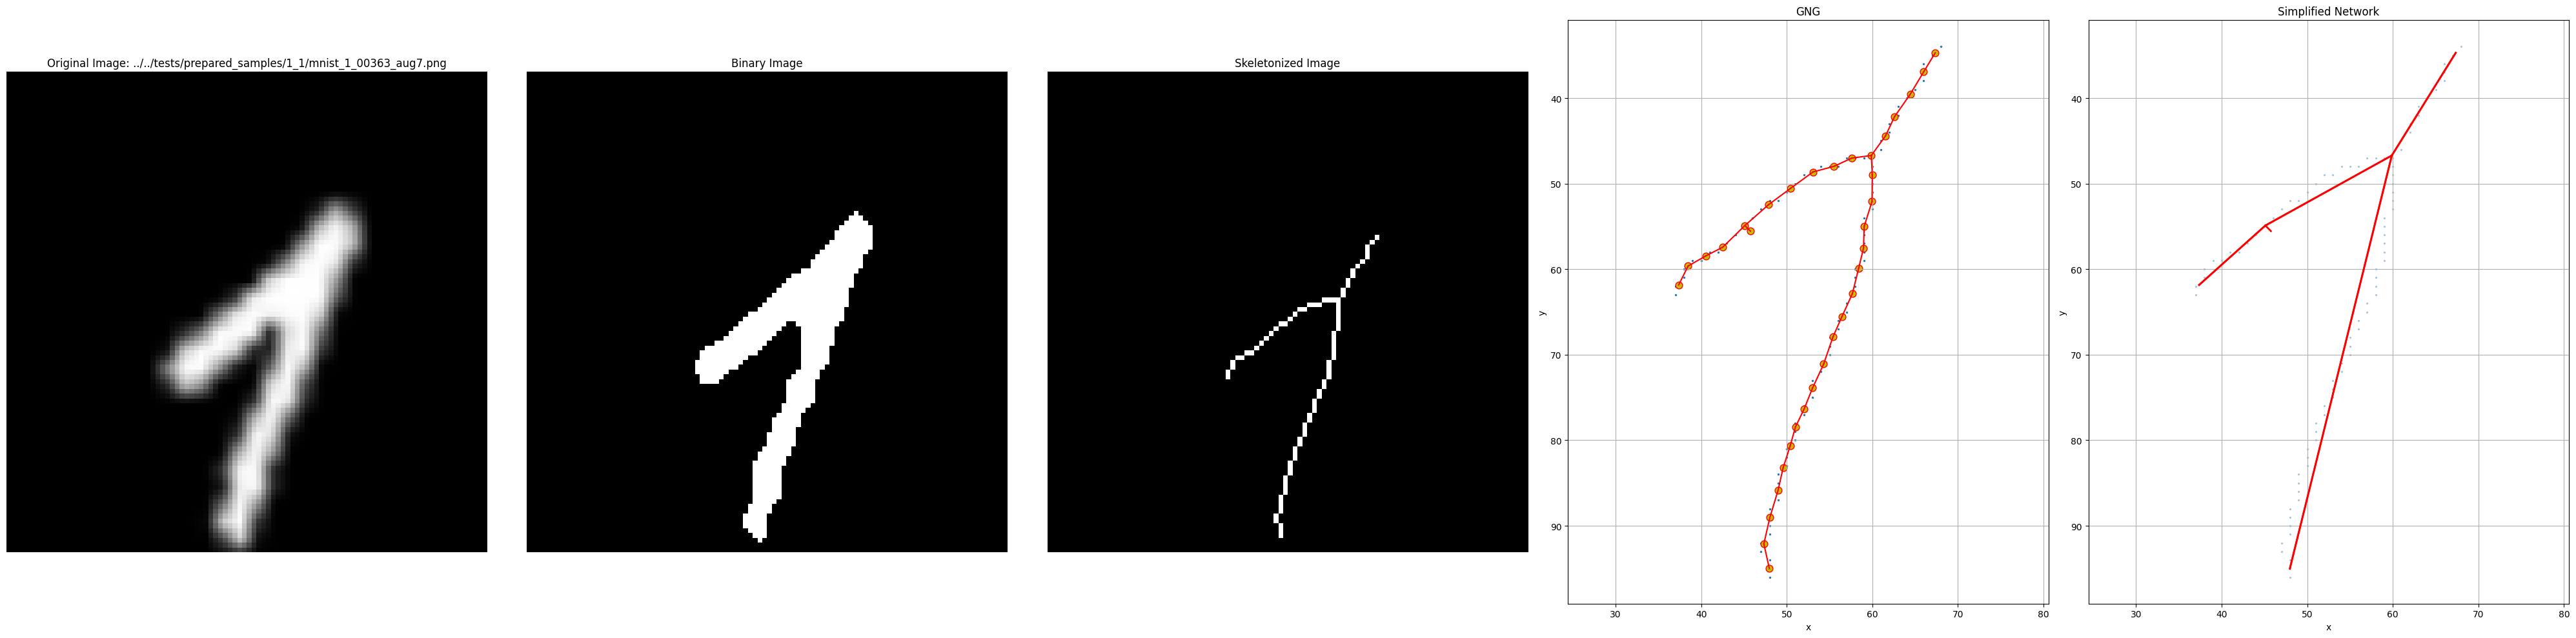

Cycles: 0
Top leftmost point: {'x': 37.366640117163115, 'y': 61.84920736876672, 'uuid': '733bad21-4f21-4e69-bae8-b973309e410c'}
Vector 1: x1: 37.366640117163115, y1: 61.84920736876672, x2: 45.107995484827654, y2: 54.90178463510423
Vector 2: x1: 45.107995484827654, y1: 54.90178463510423, x2: 59.88375555924239, y2: 46.71239679936791
Vector 3: x1: 59.88375555924239, y1: 46.71239679936791, x2: 67.34992169016658, y2: 34.70956318134338
Vector 4: x1: 59.88375555924239, y1: 46.71239679936791, x2: 47.968362914694666, y2: 95.00929742394942
Vector 5: x1: 45.107995484827654, y1: 54.90178463510423, x2: 45.75449475828313, y2: 55.55451923644976


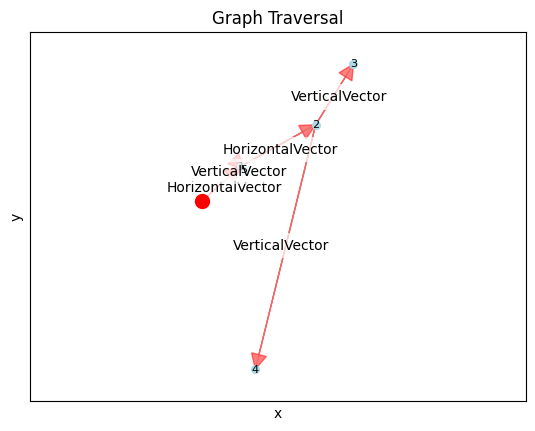

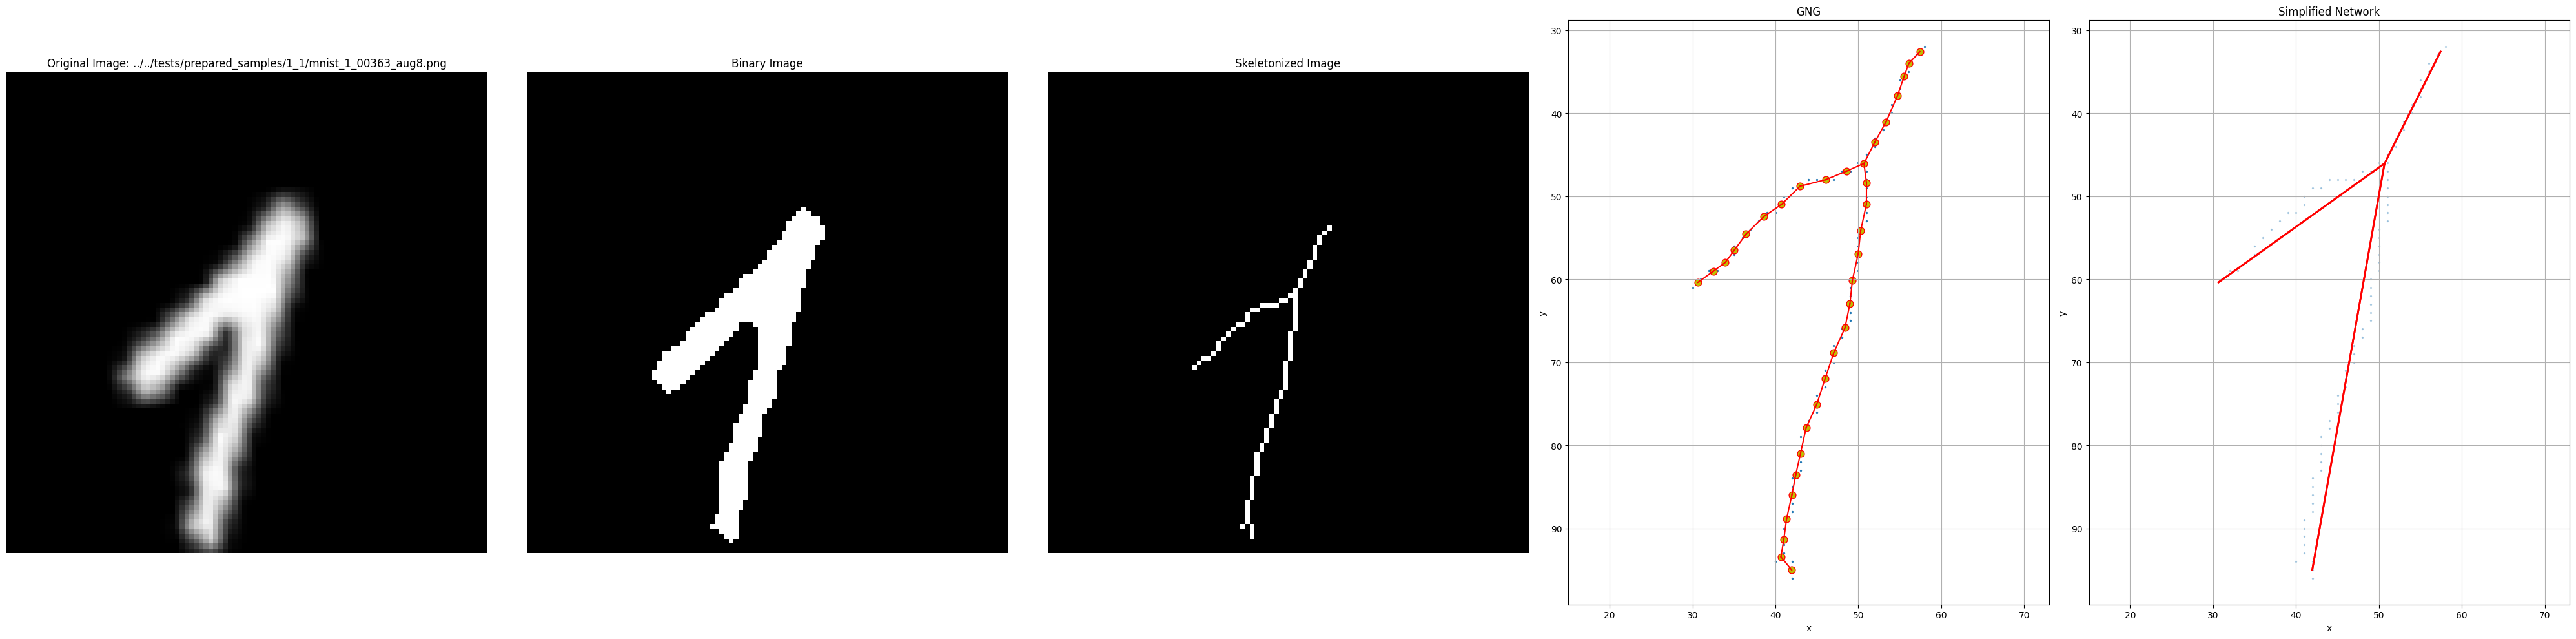

Cycles: 0
Top leftmost point: {'x': 57.419213286044105, 'y': 32.580786748180124, 'uuid': '59b355f8-21d6-4378-beee-9f131ecdca55'}
Vector 1: x1: 57.419213286044105, y1: 32.580786748180124, x2: 50.671695050342564, y2: 46.055078790175756
Vector 2: x1: 50.671695050342564, y1: 46.055078790175756, x2: 41.95449114873024, y2: 95.02662444438178
Vector 3: x1: 50.671695050342564, y1: 46.055078790175756, x2: 30.645702942233584, y2: 60.38112933246406


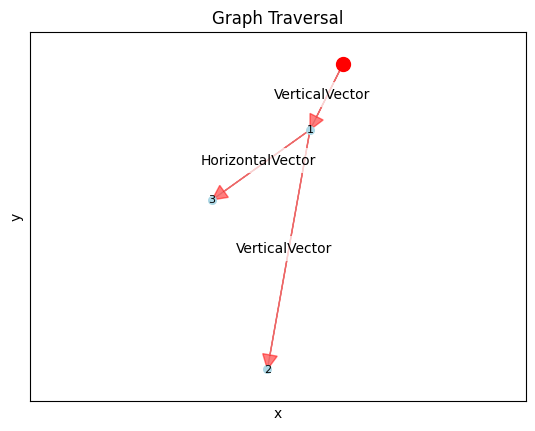

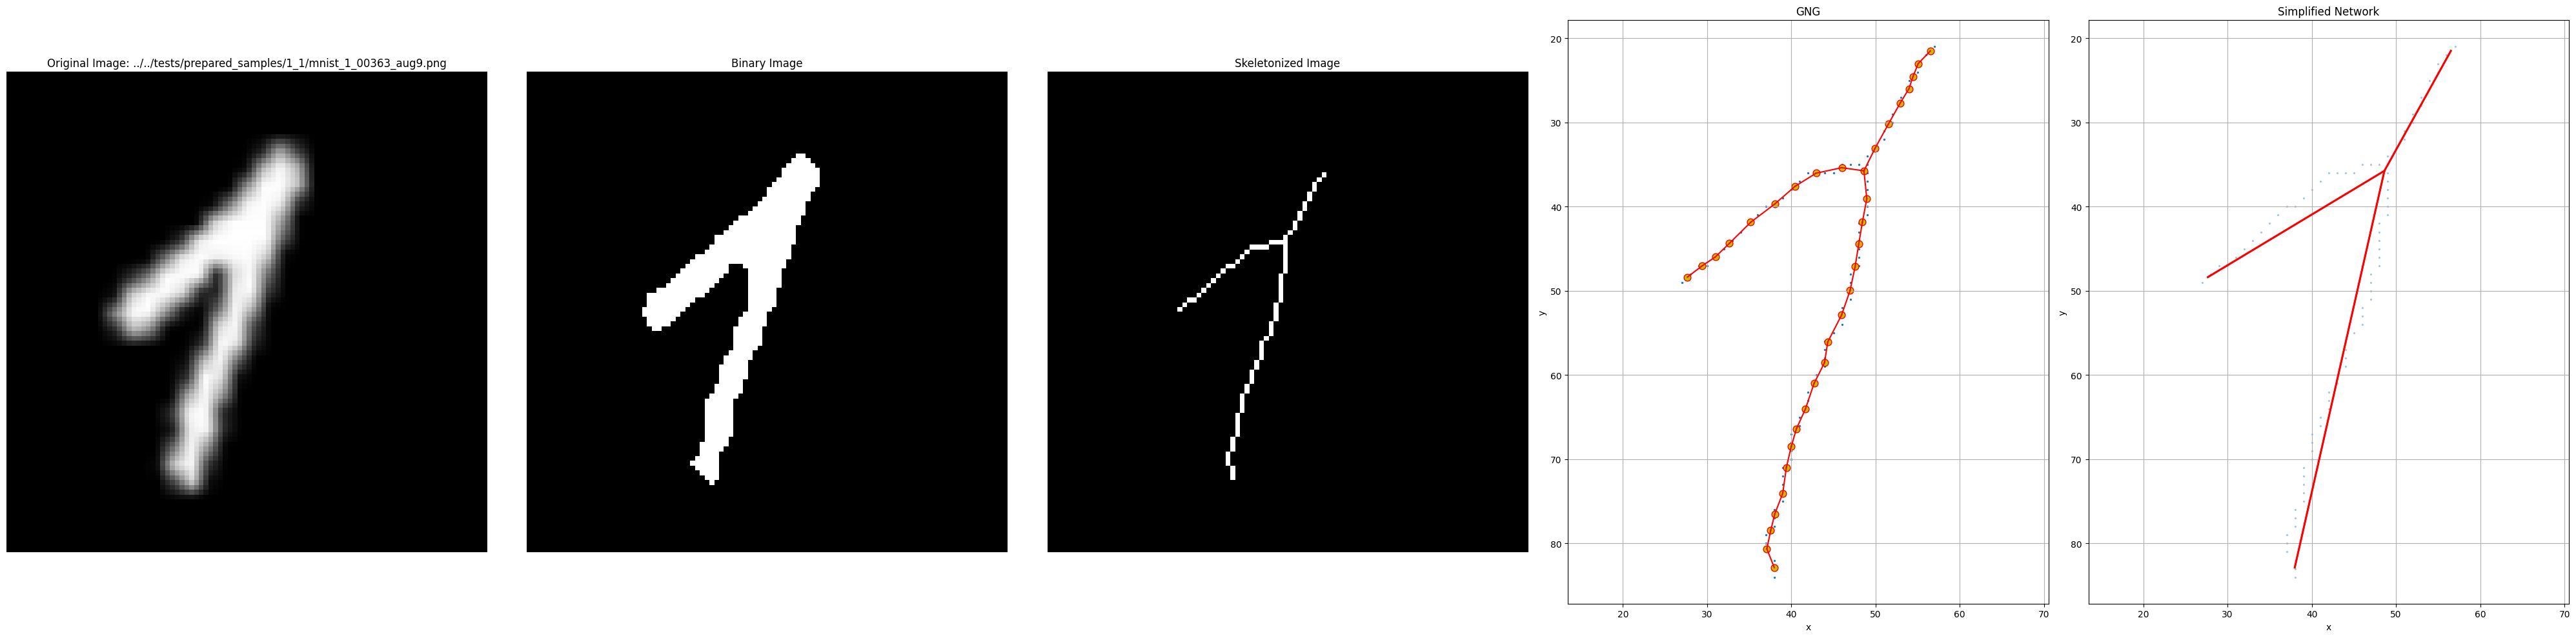

Cycles: 0
Top leftmost point: {'x': 27.659233391728385, 'y': 48.36732696281701, 'uuid': '6a2a7704-a839-4b6a-8b0f-29dedbba2c87'}
Vector 1: x1: 27.659233391728385, y1: 48.36732696281701, x2: 48.62252065206262, y2: 35.74053691011084
Vector 2: x1: 48.62252065206262, y1: 35.74053691011084, x2: 56.51310008258407, y2: 21.486900125002823
Vector 3: x1: 48.62252065206262, y1: 35.74053691011084, x2: 37.976979008759635, y2: 82.86349271601055


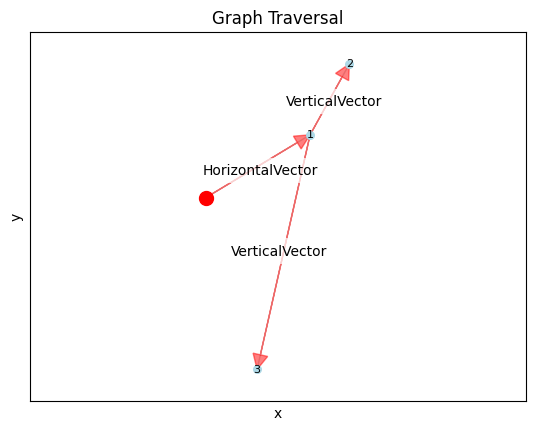

In [8]:
settings = Settings(
    kafka_topic='dummy',
    dlq_topic='dummy',
    kafka_bootstrap_servers='dummy',
    N=35,
    maxit=50,
    L=40,
    epsilon_b=0.2,
    epsilon_n=0.01,
    alpha=0.5,
    delta=0.995,
    T=50,
)

skeleton_gng_mapper = SkeletonGNGMapper(
    settings=settings,
    skeletonization_threshold=170,
    simplification_epsilon=3
)

# Get 10 random images from the folder
folder_path = "../../tests/prepared_samples/1_1"
# folder_path = '../../tests/generated_samples/mnist_1/train'
images = [
    os.path.join(folder_path, file)
    for file in sorted(os.listdir(folder_path))
    if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"))
]
# random_images = np.random.choice(images, len(images), replace=False)

class_number = 2
image_number = 45
# images = [f'../../tests/generated_samples/mnist_{class_number}/test/mnist_{class_number}_{image_number:05d}.png']

for image_path in images:
    image = imread(image_path, 0)
    # binary_threshold = threshold_otsu(image)
    # print(f"Binary threshold: {binary_threshold}")
    binary = skeleton_gng_mapper.binary_image(image)
    skeleton = skeleton_gng_mapper.skeletonize(image)
    image_points = skeleton_gng_mapper.skeleton_to_points(skeleton)
    network = skeleton_gng_mapper.fit_gng(image_points)
    simplified_network = NetworkSimplification.simplify_network(network, epsilon=skeleton_gng_mapper.simplification_epsilon)
    plot_network_result(
        image_path,
        network,
        gng_parameters(settings),
        image_points,
        image,
        binary,
        skeleton,
        simplified_network,
    )

    G = Converter.convert_simplified_network_to_networkx(simplified_network)

    cycles = list(nx.simple_cycles(G))
    print(f"Cycles: {len(cycles)}")
    if not nx.is_connected(G):
        print(f"Graph {image_path} is not connected")
        continue
    top_leftmost_point = find_top_leftmost_point(G)
    print(f"Top leftmost point: {G.nodes[top_leftmost_point]}")
    traversal = GraphTraversal(G).dfs_traversal(start_node=top_leftmost_point)

    plot_graph_traversal(plt.gca(), G, traversal)
    plt.show()